# Project dependencies

In [1]:
import sys
import subprocess

def install_requirements(requirements_file="requirements.txt"):
    try:
        print(f"Installing dependencies from {requirements_file}...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-r", requirements_file],
            check=True
        )
        print("Dependencies installed successfully!")
    except subprocess.CalledProcessError as e:
        print(f"Error installing dependencies: {e}")

# Run only if necessary
# install_requirements()

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import time
import json
import gc
import pickle
import os
import re
from math import sqrt
from multiprocessing import Process, Queue

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import openml

from pymfe.mfe import MFE
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer, SimpleImputer

from joblib import Parallel, delayed
from tabulate import tabulate

from scipy import stats
from scipy.stats import spearmanr, rankdata, friedmanchisquare

from sklearn import decomposition, neighbors
from sklearn.cross_decomposition import CCA
from sklearn.datasets import make_classification, make_multilabel_classification
from sklearn.decomposition import (
    PCA, FastICA, KernelPCA, TruncatedSVD, FactorAnalysis,
    NMF, IncrementalPCA, LatentDirichletAllocation, SparseCoder
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.manifold import TSNE, LocallyLinearEmbedding, SpectralEmbedding
from sklearn.metrics import (
    mean_squared_error, classification_report, f1_score,
    precision_score, recall_score
)
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    LeaveOneOut, StratifiedKFold
)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.utils import shuffle

from mlxtend.evaluate import paired_ttest_5x2cv

## Loading datasets from the [OpenML](https://www.openml.org/) repository

In [6]:
all_datasets = openml.datasets.list_datasets(output_format='dataframe')
print(f"Total number of datasets in OpenML: {len(all_datasets)}")

Total number of datasets in OpenML: 6408


In [ ]:
all_datasets = openml.datasets.list_datasets(output_format='dataframe')
print(f"Total de datasets no OpenML: {len(all_datasets)}")

# Filtrando os datasets com base nos critérios especificados:

filtered_datasets = all_datasets[
    (all_datasets['NumberOfInstances'] >= 200) &
    (all_datasets['NumberOfInstances'] <= 10000) &
    (all_datasets['NumberOfFeatures'] >= 2) &
    (all_datasets['NumberOfFeatures'] <= 50) &
    (all_datasets['NumberOfClasses'] >= 2) &
    (all_datasets['NumberOfClasses'] <= 6) &
    (all_datasets['NumberOfInstancesWithMissingValues'] < all_datasets['NumberOfInstances'] * 0.3) &
    (all_datasets['MinorityClassSize'] >= 20) &
    (all_datasets['NumberOfNumericFeatures'] == all_datasets['NumberOfFeatures'] - 1) &
    (all_datasets['NumberOfInstances'] * all_datasets['NumberOfFeatures'] <= 60000)
].drop_duplicates(subset='name').reset_index(drop=True)

print(f"Quantidade de datasets após filtro: {len(filtered_datasets)}")

# Removendo datasets da mesma família (baseado no nome):
filtered_datasets['family'] = filtered_datasets['name'].str.extract(r'([a-zA-Z]+)')[0]
final_datasets = filtered_datasets.drop_duplicates(subset='family').reset_index(drop=True) 
# Drop FOREX datasets:
final_datasets = final_datasets[~final_datasets['name'].str.contains('FOREX', case=False)].reset_index(drop=True)
print(f"Quantidade de datasets após remoção de famílias: {len(final_datasets)}")
# print("Datasets selecionados:")
# print(final_datasets[['name', 'NumberOfInstances', 'NumberOfFeatures', 'NumberOfClasses']])

Total de datasets no OpenML: 6408
Quantidade de datasets após filtro: 329
Quantidade de datasets após remoção de famílias: 94


Figure saved to: dataset_summary.pdf


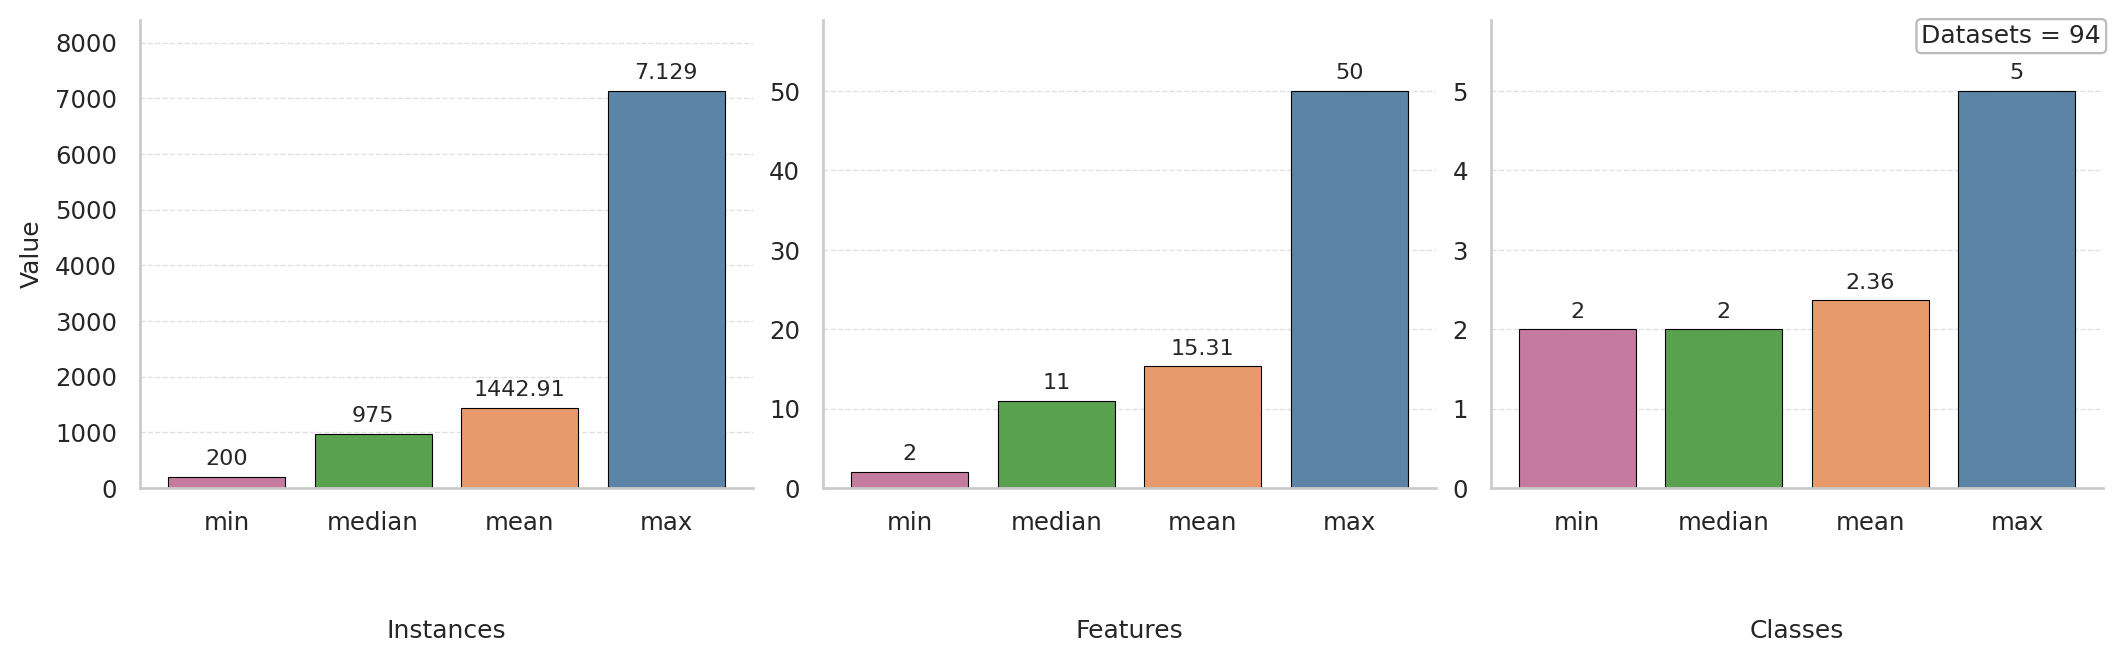

In [5]:
df_summary_stats = final_datasets[[
    "NumberOfInstances",
    "NumberOfFeatures",
    "NumberOfClasses"
]]

# Basic descriptive statistics
summary_stats = df_summary_stats.describe().T

# Add median (describe() does not include it)
summary_stats["median"] = df_summary_stats.median()

# Total number of datasets
n_datasets = int(summary_stats.loc["NumberOfInstances", "count"])

# Data prepared for plotting (min / median / mean / max)
plot_summary = summary_stats[["min", "median", "mean", "max"]].copy()
plot_summary = plot_summary.reset_index().rename(columns={"index": "Metric"})

# Color palette
color_palette = {
    "min": "#C57B9F",
    "median": "#59A14F",
    "mean": "#E79B6C",
    "max": "#5B84A6"
}
stat_order = ["min", "median", "mean", "max"]

# More formal plot style
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
})

metrics = ["NumberOfInstances", "NumberOfFeatures", "NumberOfClasses"]
metric_labels = {
    "NumberOfInstances": "Instances",
    "NumberOfFeatures": "Features",
    "NumberOfClasses": "Classes",
}

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), dpi=200, constrained_layout=True)

for ax, metric in zip(axes, metrics):
    row = plot_summary[plot_summary["Metric"] == metric][stat_order].iloc[0]
    values = row.values.astype(float)

    bars = ax.bar(
        stat_order,
        values,
        color=[color_palette[key] for key in stat_order],
        edgecolor="black",
        linewidth=0.4
    )

    ax.set_xlabel("")
    ax.set_ylabel("Value" if ax is axes[0] else "")

    # Subtle grid only on the y-axis
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
    ax.grid(False, axis="x")

    # Remove top and right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Add value labels above bars
    y_max = values.max()
    y_offset = 0.02 * y_max if y_max > 0 else 0.1

    for bar, value, stat_name in zip(bars, values, stat_order):
        if metric in ["NumberOfInstances", "NumberOfFeatures"] and stat_name in ["min", "median", "max"]:
            label = f"{int(round(value)):,}".replace(",", ".")
        elif stat_name == "mean":
            label = f"{value:.2f}"
        else:
            label = f"{int(round(value))}" if abs(value - round(value)) < 1e-9 else f"{value:.2f}"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + y_offset,
            label,
            ha="center",
            va="bottom",
            fontsize=8
        )

    # Add some space above the bars
    ax.set_ylim(0, y_max * 1.18)

# Add centered labels below each subplot
for ax, metric in zip(axes, metrics):
    ax.text(
        0.5, -0.28,
        metric_labels[metric],
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9
    )

# Add total number of datasets to the figure
fig.text(
    0.995, 0.98,
    f"Datasets = {n_datasets}",
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=0.9)
)

output_file = "dataset_summary.pdf"

plt.savefig(
    output_file,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
)

print(f"Figure saved to: {output_file}")

plt.show()

In [8]:
# Baixando os datasets filtrados:

datasets = {}   # {nome: {'data': X, 'target': y}}
failed = []

for i, row in final_datasets.iterrows():
    did = int(row['did'])
    name = row['name']

    try:
        ds = openml.datasets.get_dataset(did, download_data=True,
                                         download_qualities=False,
                                         download_features_meta_data=False)
        X, y, _, _ = ds.get_data(dataset_format='dataframe',
                                 target=ds.default_target_attribute)

        unique_name = f"{name}_did{did}" # No caso de haver versões duplicadas

        datasets[unique_name] = {'data': X, 'target': y}
        print(f"[Sucesso]: {i}: {unique_name}  ({X.shape[0]}×{X.shape[1]})")

    except Exception as e:
        failed.append(name)
        print(f"[Erro]: {i}: {name}: {e}")

print("\nDownload concluído!")
print(f"Datasets carregados com sucesso: {len(datasets)}")
print(f"Número de falhas: {len(failed)}")

[Sucesso]: 0: balance-scale_did11  (625×4)
[Sucesso]: 1: breast-w_did15  (699×9)
[Sucesso]: 2: diabetes_did37  (768×8)
[Sucesso]: 3: heart-statlog_did53  (270×13)
[Sucesso]: 4: vehicle_did54  (846×18)
[Sucesso]: 5: ionosphere_did59  (351×34)
[Sucesso]: 6: oil_spill_did311  (937×49)
[Sucesso]: 7: SPECTF_did337  (349×44)
[Sucesso]: 8: prnn_synth_did464  (250×2)
[Sucesso]: 9: rmftsa_sleepdata_did679  (1024×2)
[Sucesso]: 10: fri_c3_1000_25_did715  (1000×25)
[Sucesso]: 11: pwLinear_did721  (200×10)
[Sucesso]: 12: analcatdata_supreme_did728  (4052×7)
[Sucesso]: 13: machine_cpu_did733  (209×6)
[Sucesso]: 14: space_ga_did737  (3107×6)
[Sucesso]: 15: pm10_did750  (500×7)
[Sucesso]: 16: strikes_did770  (625×6)
[Sucesso]: 17: quake_did772  (2178×3)
[Sucesso]: 18: disclosure_x_bias_did774  (662×3)
[Sucesso]: 19: bodyfat_did778  (252×14)
[Sucesso]: 20: delta_ailerons_did803  (7129×5)
[Sucesso]: 21: chscase_vine2_did814  (468×2)
[Sucesso]: 22: chatfield_4_did820  (235×12)
[Sucesso]: 23: stock_did841

# Extracting meta-features from the datasets

In [10]:
import time
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer, SimpleImputer

from pymfe.mfe import MFE

# OUTPUT FILES
METAFEATURES_CSV = "new_meta_features.csv"
TIMES_CSV = "meta_feature_times.csv"
ERRORS_CSV = "meta_feature_errors.csv"

# STORAGE
meta_features = []
times_data = []
errors_data = []
# LOOP
for dataset_name, dataset in list(datasets.items()):

    start_time = time.time()

    print(f'Extracting meta-features from {dataset_name}...', end=' ')

    try:
        # DATA
        X = dataset['data'].copy()
        y = dataset['target']

        # CATEGORICAL FEATURES
        for col in X.select_dtypes(include=['object']).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        # MISSING VALUES
        imputer = KNNImputer(n_neighbors=3)

        try:
            X = pd.DataFrame(
                imputer.fit_transform(X),
                columns=X.columns
            )

        except Exception:
            imputer = SimpleImputer(
                missing_values=np.nan,
                strategy='most_frequent'
            )

            X = pd.DataFrame(
                imputer.fit_transform(X),
                columns=X.columns
            )

        # TARGET ENCODING
        if y.dtype == 'object':
            le = LabelEncoder()
            y = le.fit_transform(y)
        else:
            y = np.array(y)

        # META-FEATURE EXTRACTION
        mfe = MFE(
            groups=[
                'landmarking',
                'general',
                'statistical',
                'model-based',
                'info-theory',
                'relative',
                'clustering',
                'complexity',
                'itemset',
                'concept'
            ],
            summary=[
                'median',
                'min',
                'max',
                'mean',
                'sd',
                'quantiles',
                'histogram'
            ]
        )

        # suppress warnings only inside extraction
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            mfe.fit(X.values, y)
            ft = mfe.extract()

        # CREATE DATAFRAME
        df_meta = pd.DataFrame(
            [ft[1]],
            columns=ft[0],
            index=[dataset_name]
        )

        meta_features.append(df_meta)

        # SAVE INCREMENTALLY
        partial_meta_df = pd.concat(
            meta_features,
            ignore_index=False
        )

        partial_meta_df.to_csv(METAFEATURES_CSV)

        # TIME
        elapsed_time = time.time() - start_time

        times_data.append({
            'dataset': dataset_name,
            'time_seconds': elapsed_time
        })

        pd.DataFrame(times_data).to_csv(
            TIMES_CSV,
            index=False
        )

        print(f'Done ({elapsed_time:.2f}s)')

    except Exception as e:

        elapsed_time = time.time() - start_time

        errors_data.append({
            'dataset': dataset_name,
            'error': str(e),
            'time_until_error': elapsed_time
        })

        pd.DataFrame(errors_data).to_csv(
            ERRORS_CSV,
            index=False
        )

        print(f'Error: {e}')

meta_features_df = pd.concat(
    meta_features,
    ignore_index=False
)

print("\nFinished!")
print(f"Meta-features saved to: {METAFEATURES_CSV}")
print(f"Times saved to: {TIMES_CSV}")
print(f"Errors saved to: {ERRORS_CSV}")

Extracting meta-features from balance-scale_did11... Done (0.39s)
Extracting meta-features from breast-w_did15... Done (0.60s)
Extracting meta-features from diabetes_did37... Done (0.70s)
Extracting meta-features from heart-statlog_did53... Done (0.77s)
Extracting meta-features from vehicle_did54... Done (1.56s)
Extracting meta-features from ionosphere_did59... Done (1.36s)
Extracting meta-features from oil_spill_did311... Done (2.98s)
Extracting meta-features from SPECTF_did337... Done (2.13s)
Extracting meta-features from prnn_synth_did464... Done (0.20s)
Extracting meta-features from rmftsa_sleepdata_did679... Done (0.66s)
Extracting meta-features from fri_c3_1000_25_did715... Done (1.93s)
Extracting meta-features from pwLinear_did721... Done (0.62s)
Extracting meta-features from analcatdata_supreme_did728... Done (8.37s)
Extracting meta-features from machine_cpu_did733... Done (0.42s)
Extracting meta-features from space_ga_did737... Done (6.00s)
Extracting meta-features from pm10_d

In [ ]:
intermediate_df = pd.concat(meta_features, ignore_index=False)
intermediate_df.to_csv('new_meta_features_.csv')

# Algorithm Performance Evaluation

## Classification without Dimensionality Reduction using KNN

In [11]:
import time
import json
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

results = {
    'Name': [],
    'Score': []
}

# Itera sobre os datasets já carregados em memória
for dataset_name, dataset_content in datasets.items():

    try:

        print(f"[INFO] Processando: {dataset_name}")

        start_time_test = time.time()

        # Recupera X e y
        X = dataset_content['data'].copy()
        y = dataset_content['target'].copy()


        # Converter colunas categóricas
        for col in X.select_dtypes(include=['object', 'category']).columns:

            le = LabelEncoder()

            X[col] = le.fit_transform(
                X[col].astype(str)
            )

        # Escalonamento
        scaler = StandardScaler()

        X = scaler.fit_transform(X)


        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []

        for train_index, test_index in skf.split(X, y):

            X_train, X_test = X[train_index], X[test_index]

            y_train, y_test = (
                y.iloc[train_index],
                y.iloc[test_index]
            )

            # Modelo
            neigh = KNeighborsClassifier(
                n_neighbors=5,
                weights='uniform',
                algorithm='auto',
                leaf_size=10,
                metric='minkowski',
                p=2
            )

            # Treinamento
            neigh.fit(X_train, y_train)

            # Predição
            y_pred = neigh.predict(X_test)

            # F1-score
            score = f1_score(
                y_test,
                y_pred,
                average='micro'
            )

            f1_scores.append(score)

        # Média final
        avg_f1 = np.mean(f1_scores)

        # Salvar resultado
        results['Name'].append(dataset_name)

        results['Score'].append(avg_f1)

        elapsed = time.time() - start_time_test

        print(
            f"[SUCESSO] {dataset_name} | "
            f"F1: {avg_f1:.4f} | "
            f"Tempo: {elapsed:.2f}s"
        )

    except Exception as e:

        print(f"[ERRO] {dataset_name}: {e}")


with open(
    "ClassificationNoreduction.json",
    "w"
) as outfile:

    json.dump(results, outfile, indent=3)

print("\nProcessamento concluído!")

[INFO] Processando: balance-scale_did11
[SUCESSO] balance-scale_did11 | F1: 0.8352 | Tempo: 0.03s
[INFO] Processando: breast-w_did15
[ERRO] breast-w_did15: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
[INFO] Processando: diabetes_did37
[SUCESSO] diabetes_did37 | F1: 0.7291 | Tempo: 0.02s
[INFO] Processando: heart-statlog_did53
[SUCESSO] heart-statlog_did53 | F1: 0.8148 | Tempo: 0.01s
[INFO] Processa

/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

[SUCESSO] oil_spill_did311 | F1: 0.9627 | Tempo: 0.18s
[INFO] Processando: SPECTF_did337
[SUCESSO] SPECTF_did337 | F1: 0.7477 | Tempo: 0.04s
[INFO] Processando: prnn_synth_did464
[SUCESSO] prnn_synth_did464 | F1: 0.8520 | Tempo: 0.02s
[INFO] Processando: rmftsa_sleepdata_did679
[SUCESSO] rmftsa_sleepdata_did679 | F1: 0.5078 | Tempo: 0.02s
[INFO] Processando: fri_c3_1000_25_did715
[SUCESSO] fri_c3_1000_25_did715 | F1: 0.6280 | Tempo: 0.05s
[INFO] Processando: pwLinear_did721
[SUCESSO] pwLinear_did721 | F1: 0.8100 | Tempo: 0.01s
[INFO] Processando: analcatdata_supreme_did728
[SUCESSO] analcatdata_supreme_did728 | F1: 0.9788 | Tempo: 0.04s
[INFO] Processando: machine_cpu_did733
[SUCESSO] machine_cpu_did733 | F1: 0.9328 | Tempo: 0.01s
[INFO] Processando: space_ga_did737


/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

[SUCESSO] space_ga_did737 | F1: 0.8149 | Tempo: 0.03s
[INFO] Processando: pm10_did750
[SUCESSO] pm10_did750 | F1: 0.5540 | Tempo: 0.02s
[INFO] Processando: strikes_did770
[SUCESSO] strikes_did770 | F1: 0.8544 | Tempo: 0.04s
[INFO] Processando: quake_did772
[SUCESSO] quake_did772 | F1: 0.5395 | Tempo: 0.03s
[INFO] Processando: disclosure_x_bias_did774
[SUCESSO] disclosure_x_bias_did774 | F1: 0.4970 | Tempo: 0.02s
[INFO] Processando: bodyfat_did778
[SUCESSO] bodyfat_did778 | F1: 0.8734 | Tempo: 0.02s
[INFO] Processando: delta_ailerons_did803


...

/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

[SUCESSO] total_score_did46505 | F1: 0.6092 | Tempo: 0.03s
[INFO] Processando: dataset_credit-g_did46532
[SUCESSO] dataset_credit-g_did46532 | F1: 0.7170 | Tempo: 0.02s
[INFO] Processando: maternal_health_risk_did46600
[SUCESSO] maternal_health_risk_did46600 | F1: 0.6834 | Tempo: 0.02s
[INFO] Processando: student_lifestyle_dataset_did46752
[SUCESSO] student_lifestyle_dataset_did46752 | F1: 0.8700 | Tempo: 0.04s
[INFO] Processando: air-quality-and-pollution-assessment_did46762


/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

[SUCESSO] air-quality-and-pollution-assessment_did46762 | F1: 0.9216 | Tempo: 0.13s
[INFO] Processando: football-player-position_did46764
[SUCESSO] football-player-position_did46764 | F1: 0.8147 | Tempo: 0.14s
[INFO] Processando: hepatitis_c_virus_hcv_for_egyptian_patients_did46850
[SUCESSO] hepatitis_c_virus_hcv_for_egyptian_patients_did46850 | F1: 0.2592 | Tempo: 0.04s
[INFO] Processando: depression_2020_did46876
[ERRO] depression_2020_did46876: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the followi

/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/daniel-silva/Documents/personal/meta-dr/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

In [12]:
# Load the CSV file containing the classification results
# This file stores the performance of the classifier without dimensionality reduction
# Path relative to project root (run the notebook from the repo root, e.g. meta-dr/)
from pathlib import Path
performance_without_reduction = pd.read_csv(Path("data") / "baseline" / "ClassificationNoreduction_new.csv")

# Useful to quickly inspect the structure and verify that the data loaded correctly
performance_without_reduction.head()


FileNotFoundError: [Errno 2] No such file or directory: 'data/baseline/ClassificationNoreduction_new.csv'

## Classification with Dimensionality Reduction using KNN

### (PCA)

In [11]:
import warnings
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 5

def process_dataset_pca(dataset_name, dataset, k):
    try:
        # Load dataset from OpenML
        print(f"[INFO] Starting dataset: {dataset_name}")

        X = dataset['data'].copy()
        y = dataset['target'].copy()

        print(f"[INFO] Shape: {X.shape}")

        print(f"[INFO] Dataset loaded: {dataset_name} | Shape: {X.shape}")

        # Handle missing values and scale features
        X = pd.get_dummies(X)
        X = X.fillna(0)

        X = StandardScaler().fit_transform(X.astype(float))

        # Limit dataset size for faster processing
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        f1_scores = []

        for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset_name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]

            # Apply PCA
            pca = PCA(n_components=0.95)

            X_train_pca = pca.fit_transform(X_train)
            X_test_pca = pca.transform(X_test)

            num_components = pca.n_components_

            print(f"[INFO] Selected components: {num_components}")
            print(f"[INFO] Explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")
            

            print(f"[INFO] Selected components: {num_components}")

            # Train KNN classifier
            n_neighbors = min(k, len(X_train))
            neigh = KNeighborsClassifier(n_neighbors=n_neighbors)
            neigh.fit(X_train_pca, y_train)

            # Predict and evaluate
            y_pred = neigh.predict(X_test_pca)
            score = f1_score(y_test, y_pred, average='micro')
            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)
        print(f"[SUCCESS] Finished dataset: {dataset_name} | Mean F1: {mean_score:.4f}\n")

        return (dataset_name, mean_score)

    except Exception as e:
        print(f"[ERROR] Dataset ID {dataset_name} failed: {str(e)}\n")
        return ('__error__', f"{dataset_name}: {str(e)}")


# Parallel execution (adjust n_jobs based on CPU)
print("[INFO] Starting parallel processing...\n")

results = Parallel(n_jobs=2, backend='loky', verbose=10)(
    delayed(process_dataset_pca)(dataset_name, dataset, k)
    for dataset_name, dataset in datasets.items()
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:
    if res[0] == '__error__':
        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")
    else:
        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        print(f"[DONE] {res[0]} | Mean F1: {res[1]:.4f}")


pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_PCA.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

[INFO] Starting parallel processing...



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


[INFO] Starting dataset: balance-scale_did11
[INFO] Shape: (625, 4)
[INFO] Dataset loaded: balance-scale_did11 | Shape: (625, 4)
[INFO] Processing fold 1/5 for dataset balance-scale_did11
[INFO] Selected components: 4
[INFO] Explained variance: 1.0000
[INFO] Selected components: 4
[INFO] Fold 1 F1-score: 0.8080
[INFO] Processing fold 2/5 for dataset balance-scale_did11
[INFO] Selected components: 4
[INFO] Explained variance: 1.0000
[INFO] Selected components: 4
[INFO] Fold 2 F1-score: 0.8080
[INFO] Processing fold 3/5 for dataset balance-scale_did11
[INFO] Selected components: 4
[INFO] Explained variance: 1.0000
[INFO] Selected components: 4
[INFO] Fold 3 F1-score: 0.8160
[INFO] Processing fold 4/5 for dataset balance-scale_did11
[INFO] Selected components: 4
[INFO] Explained variance: 1.0000
[INFO] Selected components: 4
[INFO] Fold 4 F1-score: 0.8480
[INFO] Processing fold 5/5 for dataset balance-scale_did11
[INFO] Selected components: 4
[INFO] Explained variance: 1.0000
[INFO] Selec

[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:    0.9s


[INFO] Starting dataset: oil_spill_did311
[INFO] Shape: (937, 49)
[INFO] Dataset loaded: oil_spill_did311 | Shape: (937, 49)
[INFO] Processing fold 1/5 for dataset oil_spill_did311
[INFO] Fold 2 F1-score: 0.8286
[INFO] Processing fold 3/5 for dataset ionosphere_did59
[INFO] Selected components: 18
[INFO] Explained variance: 0.9545
[INFO] Selected components: 18
[INFO] Selected components: 23
[INFO] Explained variance: 0.9540
[INFO] Selected components: 23
[INFO] Fold 3 F1-score: 0.8429
[INFO] Processing fold 4/5 for dataset ionosphere_did59
[INFO] Selected components: 23
[INFO] Explained variance: 0.9560
[INFO] Selected components: 23
[INFO] Fold 1 F1-score: 0.9681
[INFO] Processing fold 2/5 for dataset oil_spill_did311
[INFO] Selected components: 18
[INFO] Explained variance: 0.9524
[INFO] Selected components: 18
[INFO] Fold 4 F1-score: 0.8714
[INFO] Processing fold 5/5 for dataset ionosphere_did59
[INFO] Selected components: 23
[INFO] Explained variance: 0.9559
[INFO] Selected compon

...

[Parallel(n_jobs=2)]: Batch computation too fast (0.13643813133239746s.) Setting batch_size=8.


[INFO] Selected components: 11
[INFO] Explained variance: 0.9583
[INFO] Selected components: 11
[INFO] Fold 1 F1-score: 0.8333
[INFO] Processing fold 2/5 for dataset CostaMadre1_did1446
[INFO] Selected components: 11
[INFO] Explained variance: 0.9584
[INFO] Selected components: 11
[INFO] Fold 2 F1-score: 0.8136
[INFO] Processing fold 3/5 for dataset CostaMadre1_did1446
[INFO] Selected components: 11
[INFO] Explained variance: 0.9511
[INFO] Selected components: 11
[INFO] Selected components: 11
[INFO] Explained variance: 0.9535
[INFO] Selected components: 11
[INFO] Fold 1 F1-score: 0.9259
[INFO] Processing fold 2/5 for dataset mw1_did1071
[INFO] Fold 3 F1-score: 0.8136
[INFO] Processing fold 4/5 for dataset CostaMadre1_did1446
[INFO] Selected components: 10
[INFO] Explained variance: 0.9518
[INFO] Selected components: 10
[INFO] Fold 4 F1-score: 0.8136
[INFO] Processing fold 5/5 for dataset CostaMadre1_did1446
[INFO] Selected components: 11
[INFO] Explained variance: 0.9596
[INFO] Select

[Parallel(n_jobs=2)]: Done  38 tasks      | elapsed:    2.5s



[INFO] Shape: (748, 4)
[INFO] Dataset loaded: blood-transfusion-service-center_did1464 | Shape: (748, 4)
[INFO] Processing fold 1/5 for dataset PieChart1_did1451
[INFO] Selected components: 12
[INFO] Explained variance: 0.9561
[INFO] Selected components: 12
[INFO] Processing fold 1/5 for dataset blood-transfusion-service-center_did1464
[INFO] Selected components: 3
[INFO] Explained variance: 1.0000
[INFO] Selected components: 3
[INFO] Fold 1 F1-score: 0.9078
[INFO] Processing fold 2/5 for dataset PieChart1_did1451
[INFO] Fold 1 F1-score: 0.7467
[INFO] Processing fold 2/5 for dataset blood-transfusion-service-center_did1464
[INFO] Selected components: 3
[INFO] Explained variance: 1.0000
[INFO] Selected components: 3
[INFO] Fold 2 F1-score: 0.7933
[INFO] Processing fold 3/5 for dataset blood-transfusion-service-center_did1464
[INFO] Selected components: 12
[INFO] Explained variance: 0.9590
[INFO] Selected components: 12
[INFO] Selected components: 3
[INFO] Explained variance: 1.0000
[IN

[Parallel(n_jobs=2)]: Done  94 out of  94 | elapsed:    4.4s finished


### Kernel Principal Component Analysis (kPCA)

In [12]:
import warnings
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 5


def process_dataset_kpca(dataset_name, dataset, k):

    try:
        print(f"[INFO] Starting dataset: {dataset_name}")

        # Load dataset already in memory
        X = dataset['data'].copy()
        y = dataset['target'].copy()

        print(f"[INFO] Dataset loaded: {dataset_name} | Shape: {X.shape}")

        # Encode categorical variables
        for col in X.select_dtypes(include=['object', 'category']).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        # Handle missing values
        X = X.fillna(0)

        # Scale features
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit dataset size
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")

            X = X[:2000]

            if hasattr(y, 'iloc'):
                y = y.iloc[:2000]
            else:
                y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []

        for fold, (train_index, test_index) in enumerate(
            skf.split(X, y),
            start=1
        ):

            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset_name}")

            X_train, X_test = X[train_index], X[test_index]

            if hasattr(y, 'iloc'):
                y_train = y.iloc[train_index]
                y_test = y.iloc[test_index]
            else:
                y_train = y[train_index]
                y_test = y[test_index]

            # Apply Kernel PCA
            # KernelPCA is used instead of standard PCA because it can capture non-linear relationships between features through kernel functions. In this implementation, the RBF (Radial Basis Function) kernel is adopted since it is one of the most effective and commonly used kernels for modeling complex data manifolds. The number of components is limited to a maximum of 20 (while also respecting dataset dimensions) in order to reduce computational cost, avoid excessively large latent spaces, and improve generalization for the KNN classifier. The parameter gamma=0.01 controls the influence radius of samples in the RBF kernel and provides a stable balance between underfitting and overfitting for standardized datasets. Finally, random_state=42 is used to ensure experimental reproducibility.
            kpca = KernelPCA(
                n_components=min(20, X_train.shape[1], X_train.shape[0] - 1),
                kernel='rbf',
                gamma=0.01,
                random_state=42
            )

            X_train_kpca = kpca.fit_transform(X_train)
            X_test_kpca = kpca.transform(X_test)

            print(f"[INFO] KernelPCA components: {X_train_kpca.shape[1]}")
            

            # Train KNN
            n_neighbors = min(k, len(X_train_kpca))

            neigh = KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights='uniform',
                algorithm='auto',
                leaf_size=10,
                metric='minkowski',
                p=2
            )

            neigh.fit(X_train_kpca, y_train)

            # Predict
            y_pred = neigh.predict(X_test_kpca)

            score = f1_score(
                y_test,
                y_pred,
                average='micro'
            )

            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)

        print(
            f"[SUCCESS] Finished dataset: "
            f"{dataset_name} | Mean F1: {mean_score:.4f}\n"
        )

        return (dataset_name, mean_score)

    except Exception as e:

        print(
            f"[ERROR] Dataset {dataset_name} failed: "
            f"{str(e)}\n"
        )

        return ('__error__', f"{dataset_name}: {str(e)}")


# Parallel execution
print("[INFO] Starting parallel processing...\n")

results = Parallel(
    n_jobs=2,
    backend='loky',
    verbose=10
)(
    delayed(process_dataset_kpca)(
        dataset_name,
        dataset,
        k
    )
    for dataset_name, dataset in datasets.items()
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:

    if res[0] == '__error__':

        skipped_datasets.append(res[1])

        print(f"[SKIPPED] {res[1]}")

    else:

        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])

        print(
            f"[DONE] {res[0]} | "
            f"Mean F1: {res[1]:.4f}"
        )

# Save results
print("\n[INFO] Saving results to files...")

# with open('ClassificationWithReduction_KPCA.json', 'w') as f:
#     json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_KPCA.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

[INFO] Starting parallel processing...



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


[INFO] Starting dataset: breast-w_did15
[INFO] Dataset loaded: breast-w_did15 | Shape: (699, 9)
[INFO] Processing fold 1/5 for dataset breast-w_did15
[INFO] Starting dataset: balance-scale_did11
[INFO] Dataset loaded: balance-scale_did11 | Shape: (625, 4)
[INFO] KernelPCA components: 9
[INFO] Processing fold 1/5 for dataset balance-scale_did11
[INFO] Fold 1 F1-score: 0.9786
[INFO] Processing fold 2/5 for dataset breast-w_did15
[INFO] KernelPCA components: 4
[INFO] Fold 1 F1-score: 0.8320
[INFO] Processing fold 2/5 for dataset balance-scale_did11
[INFO] KernelPCA components: 9
[INFO] Fold 2 F1-score: 0.9643
[INFO] Processing fold 3/5 for dataset breast-w_did15
[INFO] KernelPCA components: 4
[INFO] Fold 2 F1-score: 0.8560
[INFO] Processing fold 3/5 for dataset balance-scale_did11
[INFO] KernelPCA components: 9
[INFO] Fold 3 F1-score: 0.9714
[INFO] Processing fold 4/5 for dataset breast-w_did15
[INFO] KernelPCA components: 4
[INFO] Fold 3 F1-score: 0.8000
[INFO] Processing fold 4/5 for da

[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    1.0s


[INFO] KernelPCA components: 8
[INFO] Fold 3 F1-score: 0.7403
[INFO] Processing fold 4/5 for dataset diabetes_did37
[INFO] KernelPCA components: 8
[INFO] Fold 4 F1-score: 0.7255
[INFO] Processing fold 5/5 for dataset diabetes_did37
[INFO] KernelPCA components: 13
[INFO] Fold 1 F1-score: 0.7963
[INFO] Processing fold 2/5 for dataset heart-statlog_did53
[INFO] KernelPCA components: 8
[INFO] Fold 5 F1-score: 0.6993
[SUCCESS] Finished dataset: diabetes_did37 | Mean F1: 0.7317

[INFO] Starting dataset: vehicle_did54
[INFO] Dataset loaded: vehicle_did54 | Shape: (846, 18)
[INFO] Processing fold 1/5 for dataset vehicle_did54
[INFO] KernelPCA components: 13
[INFO] Fold 2 F1-score: 0.8704
[INFO] Processing fold 3/5 for dataset heart-statlog_did53
[INFO] KernelPCA components: 13
[INFO] Fold 3 F1-score: 0.7778
[INFO] Processing fold 4/5 for dataset heart-statlog_did53
[INFO] KernelPCA components: 13
[INFO] Fold 4 F1-score: 0.8148
[INFO] Processing fold 5/5 for dataset heart-statlog_did53
[INFO] K

...

[Parallel(n_jobs=2)]: Done  68 tasks      | elapsed:   37.1s


[INFO] KernelPCA components: 20
[INFO] Fold 5 F1-score: 0.9150
[SUCCESS] Finished dataset: pol_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44382 | Mean F1: 0.9315

[INFO] Starting dataset: kdd_ipums_la_97-small_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44392
[INFO] Dataset loaded: kdd_ipums_la_97-small_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44392 | Shape: (2000, 20)
[INFO] Processing fold 1/5 for dataset kdd_ipums_la_97-small_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44392
[INFO] KernelPCA components: 16
[INFO] Fold 1 F1-score: 0.8300
[INFO] Processing fold 2/5 for dataset house_16H_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44387
[INFO] KernelPCA components: 20
[INFO] Fold 1 F1-score: 0.8350
[INFO] Processing fold 2/5 for dataset kdd_ipums_la_97-small_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44392
[INFO] KernelPCA components: 16
[INFO] KernelPCA components: 20
[INFO] Fold 2 F1-score: 0.8575
[INF

[Parallel(n_jobs=2)]: Done  81 tasks      | elapsed:   53.2s


[INFO] KernelPCA components: 18
[INFO] Fold 1 F1-score: 0.3750
[INFO] Processing fold 2/5 for dataset Apple_Stock_Price_Trends_(2014-2023)_did46420
[INFO] KernelPCA components: 20
[INFO] Fold 1 F1-score: 0.6950
[INFO] Processing fold 2/5 for dataset German-Credit-Data-Creditability-2_did46482
[INFO] KernelPCA components: 20
[INFO] Fold 2 F1-score: 0.7750
[INFO] Processing fold 3/5 for dataset German-Credit-Data-Creditability-2_did46482
[INFO] KernelPCA components: 20
[INFO] KernelPCA components: 18
[INFO] Fold 2 F1-score: 0.3650
[INFO] Processing fold 3/5 for dataset Apple_Stock_Price_Trends_(2014-2023)_did46420
[INFO] Fold 3 F1-score: 0.7400
[INFO] Processing fold 4/5 for dataset German-Credit-Data-Creditability-2_did46482
[INFO] KernelPCA components: 20
[INFO] Fold 4 F1-score: 0.7200
[INFO] Processing fold 5/5 for dataset German-Credit-Data-Creditability-2_did46482
[INFO] KernelPCA components: 20
[INFO] KernelPCA components: 18
[INFO] Fold 3 F1-score: 0.3825
[INFO] Processing fold 4/

[Parallel(n_jobs=2)]: Done  94 out of  94 | elapsed:  1.1min finished


### (Latent Dirichlet Allocation- LDA)

In [13]:
import warnings
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings("ignore")

dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 5


def process_dataset_lda(dataset_name, dataset, k):

    try:

        print(f"[INFO] Starting dataset: {dataset_name}")

        # Load dataset already in memory
        X = dataset['data'].copy()
        y = dataset['target'].copy()

        print(
            f"[INFO] Dataset loaded: "
            f"{dataset_name} | Shape: {X.shape}"
        )

        # Encode categorical features
        for col in X.select_dtypes(
            include=['object', 'category']
        ).columns:

            le = LabelEncoder()

            X[col] = le.fit_transform(
                X[col].astype(str)
            )

        # Encode target if categorical
        if hasattr(y, "dtype") and y.dtype == "object":

            y = np.array(
                pd.factorize(y)[0]
            )

            print("[INFO] Target variable encoded")

        # Handle missing values
        X = X.fillna(0)

        # # LDA requires non-negative values.
        # MinMaxScaler is used because it scales the data to [0, 1],
        # preserving the non-negative structure required by LatentDirichletAllocation.
        X = MinMaxScaler().fit_transform(
                X.astype(float)
        )

        # Limit dataset size
        if X.shape[0] > 2000:

            print(
                f"[INFO] Reducing dataset size "
                f"from {X.shape[0]} to 2000 samples"
            )

            X = X[:2000]

            if hasattr(y, 'iloc'):
                y = y.iloc[:2000]
            else:
                y = y[:2000]

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []

        for fold, (
            train_index,
            test_index
        ) in enumerate(
            skf.split(X, y),
            start=1
        ):

            print(
                f"[INFO] Processing fold "
                f"{fold}/5 for dataset {dataset_name}"
            )

            X_train, X_test = (
                X[train_index],
                X[test_index]
            )

            if hasattr(y, 'iloc'):

                y_train = y.iloc[train_index]
                y_test = y.iloc[test_index]

            else:

                y_train = y[train_index]
                y_test = y[test_index]

            # Number of latent topics
            n_components = min(
                10,
                X_train.shape[1],
                X_train.shape[0] - 1
            )

            # Apply Latent Dirichlet Allocation
            lda = LatentDirichletAllocation(
                n_components=n_components,
                learning_method='batch',
                max_iter=20,
                random_state=42
            )

            X_train_lda = lda.fit_transform(X_train)

            X_test_lda = lda.transform(X_test)

            print(
                f"[INFO] Selected components "
                f"(topics): {n_components}"
            )

            # Train KNN classifier
            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train))
            )

            neigh.fit(X_train_lda, y_train)

            # Predict
            y_pred = neigh.predict(X_test_lda)

            # Evaluate
            score = f1_score(
                y_test,
                y_pred,
                average='micro'
            )

            f1_scores.append(score)

            print(
                f"[INFO] Fold {fold} "
                f"F1-score: {score:.4f}"
            )

        mean_score = np.mean(f1_scores)

        print(
            f"[SUCCESS] Finished dataset: "
            f"{dataset_name} | Mean F1: "
            f"{mean_score:.4f}\n"
        )

        return (dataset_name, mean_score)

    except Exception as e:

        print(
            f"[ERROR] Dataset "
            f"{dataset_name} failed: "
            f"{str(e)}\n"
        )

        return (
            '__error__',
            f"{dataset_name}: {str(e)}"
        )


# Parallel execution
print("[INFO] Starting processing...\n")

results = Parallel(
    n_jobs=1,
    backend='loky',
    verbose=10
)(
    delayed(process_dataset_lda)(
        dataset_name,
        dataset,
        k
    )
    for dataset_name, dataset in datasets.items()
)

print("\n[INFO] Processing results...\n")

# Post-process results
for res in results:

    if res[0] == '__error__':

        skipped_datasets.append(res[1])

        print(f"[SKIPPED] {res[1]}")

    else:

        dictionary['Name'].append(res[0])

        dictionary['Score'].append(res[1])

        print(
            f"[DONE] {res[0]} | "
            f"Mean F1: {res[1]:.4f}"
        )

# Save results
print("\n[INFO] Saving results to files...")

# with open(
#     'ClassificationWithReduction_LDA.json',
#     'w'
# ) as f:

#     json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_LDA.csv',
    index=False
)

print("\n[FINAL REPORT]")

print(
    f"Total skipped datasets: "
    f"{len(skipped_datasets)}"
)

print(f"Skipped IDs: {skipped_datasets}")

[INFO] Starting processing...

[INFO] Starting dataset: balance-scale_did11
[INFO] Dataset loaded: balance-scale_did11 | Shape: (625, 4)
[INFO] Processing fold 1/5 for dataset balance-scale_did11
[INFO] Selected components (topics): 4
[INFO] Fold 1 F1-score: 0.7840
[INFO] Processing fold 2/5 for dataset balance-scale_did11
[INFO] Selected components (topics): 4
[INFO] Fold 2 F1-score: 0.7760
[INFO] Processing fold 3/5 for dataset balance-scale_did11
[INFO] Selected components (topics): 4
[INFO] Fold 3 F1-score: 0.8240
[INFO] Processing fold 4/5 for dataset balance-scale_did11
[INFO] Selected components (topics): 4
[INFO] Fold 4 F1-score: 0.8400
[INFO] Processing fold 5/5 for dataset balance-scale_did11
[INFO] Selected components (topics): 4
[INFO] Fold 5 F1-score: 0.8480
[SUCCESS] Finished dataset: balance-scale_did11 | Mean F1: 0.8144

[INFO] Starting dataset: breast-w_did15
[INFO] Dataset loaded: breast-w_did15 | Shape: (699, 9)
[INFO] Processing fold 1/5 for dataset breast-w_did15


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    3.5s


[INFO] Selected components (topics): 9
[INFO] Fold 1 F1-score: 0.9571
[INFO] Processing fold 2/5 for dataset breast-w_did15
[INFO] Selected components (topics): 9
[INFO] Fold 2 F1-score: 0.9571
[INFO] Processing fold 3/5 for dataset breast-w_did15
[INFO] Selected components (topics): 9
[INFO] Fold 3 F1-score: 0.9571
[INFO] Processing fold 4/5 for dataset breast-w_did15
[INFO] Selected components (topics): 9
[INFO] Fold 4 F1-score: 0.9500
[INFO] Processing fold 5/5 for dataset breast-w_did15
[INFO] Selected components (topics): 9
[INFO] Fold 5 F1-score: 0.9712
[SUCCESS] Finished dataset: breast-w_did15 | Mean F1: 0.9585

[INFO] Starting dataset: diabetes_did37
[INFO] Dataset loaded: diabetes_did37 | Shape: (768, 8)
[INFO] Processing fold 1/5 for dataset diabetes_did37
[INFO] Selected components (topics): 8
[INFO] Fold 1 F1-score: 0.6558
[INFO] Processing fold 2/5 for dataset diabetes_did37
[INFO] Selected components (topics): 8
[INFO] Fold 2 F1-score: 0.7532
[INFO] Processing fold 3/5 f

[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   10.2s


[INFO] Selected components (topics): 10
[INFO] Fold 1 F1-score: 0.3588
[INFO] Processing fold 2/5 for dataset vehicle_did54
[INFO] Selected components (topics): 10
[INFO] Fold 2 F1-score: 0.4024
[INFO] Processing fold 3/5 for dataset vehicle_did54
[INFO] Selected components (topics): 10
[INFO] Fold 3 F1-score: 0.3846
[INFO] Processing fold 4/5 for dataset vehicle_did54
[INFO] Selected components (topics): 10
[INFO] Fold 4 F1-score: 0.3669
[INFO] Processing fold 5/5 for dataset vehicle_did54
[INFO] Selected components (topics): 10
[INFO] Fold 5 F1-score: 0.4142
[SUCCESS] Finished dataset: vehicle_did54 | Mean F1: 0.3854

[INFO] Starting dataset: ionosphere_did59
[INFO] Dataset loaded: ionosphere_did59 | Shape: (351, 34)
[INFO] Processing fold 1/5 for dataset ionosphere_did59
[INFO] Selected components (topics): 10
[INFO] Fold 1 F1-score: 0.7465
[INFO] Processing fold 2/5 for dataset ionosphere_did59
[INFO] Selected components (topics): 10
[INFO] Fold 2 F1-score: 0.7857
[INFO] Processing

...

[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:  5.4min


[INFO] Selected components (topics): 10
[INFO] Fold 1 F1-score: 0.7375
[INFO] Processing fold 2/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Selected components (topics): 10
[INFO] Fold 2 F1-score: 0.7400
[INFO] Processing fold 3/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Selected components (topics): 10
[INFO] Fold 3 F1-score: 0.7700
[INFO] Processing fold 4/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Selected components (topics): 10
[INFO] Fold 4 F1-score: 0.7275
[INFO] Processing fold 5/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Selected components (topics): 10
[INFO] Fold 5 F1-score: 0.7825
[SUCCESS] Finished dataset: MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397 | Mean F1: 0.7515

[INFO] Starting dataset: bank-marketing_seed_0_nrows

[Parallel(n_jobs=1)]: Done  84 tasks      | elapsed:  7.4min


[INFO] Selected components (topics): 10
[INFO] Fold 1 F1-score: 0.6700
[INFO] Processing fold 2/5 for dataset dataset_credit-g_did46532
[INFO] Selected components (topics): 10
[INFO] Fold 2 F1-score: 0.6150
[INFO] Processing fold 3/5 for dataset dataset_credit-g_did46532
[INFO] Selected components (topics): 10
[INFO] Fold 3 F1-score: 0.6200
[INFO] Processing fold 4/5 for dataset dataset_credit-g_did46532
[INFO] Selected components (topics): 10
[INFO] Fold 4 F1-score: 0.6750
[INFO] Processing fold 5/5 for dataset dataset_credit-g_did46532
[INFO] Selected components (topics): 10
[INFO] Fold 5 F1-score: 0.6450
[SUCCESS] Finished dataset: dataset_credit-g_did46532 | Mean F1: 0.6450

[INFO] Starting dataset: maternal_health_risk_did46600
[INFO] Dataset loaded: maternal_health_risk_did46600 | Shape: (1014, 6)
[INFO] Processing fold 1/5 for dataset maternal_health_risk_did46600
[INFO] Selected components (topics): 6
[INFO] Fold 1 F1-score: 0.7241
[INFO] Processing fold 2/5 for dataset materna

[Parallel(n_jobs=1)]: Done  94 out of  94 | elapsed:  8.9min finished


###  T-Distributed Stochastic Neighbor Embedding (t-SNE)

In [15]:
import warnings
warnings.filterwarnings("ignore")


dictionary = {'Name': [], 'Score': []}
skipped_datasets = []
k = 5


def process_dataset(dataset_name, dataset, k):

    try:
        print(f"[INFO] Starting dataset: {dataset_name}")

        X = dataset['data'].copy()
        y = dataset['target'].copy()

        print(f"[INFO] Dataset loaded: {dataset_name} | Shape: {X.shape}")

        # Encode categorical features
        for col in X.select_dtypes(include=['object', 'category']).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        # Encode target labels if categorical
        if hasattr(y, "dtype") and (
            y.dtype == "object" or str(y.dtype) == "category"
        ):
            y = np.array(pd.factorize(y.astype(str))[0])
            print("[INFO] Target variable encoded")
        else:
            y = np.array(y)

        # Handle missing values
        X = X.fillna(0)

        # Standardize features
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit dataset size because t-SNE is computationally expensive
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Validate number of classes
        if len(np.unique(y)) < 2:
            raise ValueError("Dataset has less than 2 classes")

        # Handle datasets with only 1 feature
        if X.shape[1] < 2:
            print("[WARNING] Dataset has only 1 feature. Duplicating feature.")
            X = np.column_stack([X, X])

        # Dynamic perplexity
        perplexity_value = min(
            30,
            max(2, X.shape[0] // 10)
        )

        # Candidate dimensions for t-SNE
        components_candidates = [2, 5, 10, 20]

        # Avoid invalid dimensions
        components_candidates = [
            c for c in components_candidates
            if c < X.shape[0]
        ]

        best_score = -1
        best_n_components = None
        best_embedding = None

        # t-SNE is used as a non-linear dimensionality reduction technique.
        # Since t-SNE does not have explained variance like PCA, the number
        # of components is selected empirically by testing candidate dimensions
        # and choosing the one that gives the best cross-validated F1-score
        # with a KNN classifier.

        for n_comp in components_candidates:

            print(f"[INFO] Testing t-SNE with {n_comp} components")

            tsne = TSNE(
                n_components=n_comp,
                perplexity=perplexity_value,
                max_iter=1000,
                learning_rate='auto',
                init='random',
                method='exact',
                random_state=42
            )

            X_embedded = tsne.fit_transform(X)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_embedded))
            )

            scores = cross_val_score(
                neigh,
                X_embedded,
                y,
                cv=3,
                scoring='f1_micro'
            )

            mean_score = scores.mean()

            print(
                f"[INFO] Components: {n_comp} | "
                f"Mean F1: {mean_score:.4f}"
            )

            if mean_score > best_score:
                best_score = mean_score
                best_n_components = n_comp
                best_embedding = X_embedded

        X_tsne = best_embedding

        print(f"[SUCCESS] Best t-SNE components: {best_n_components}")
        print(f"[INFO] Best validation F1-score: {best_score:.4f}")

        # Final Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []

        for fold, (train_index, test_index) in enumerate(
            skf.split(X_tsne, y),
            start=1
        ):

            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset_name}")

            X_train, X_test = X_tsne[train_index], X_tsne[test_index]
            y_train, y_test = y[train_index], y[test_index]

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train))
            )

            neigh.fit(X_train, y_train)

            y_pred = neigh.predict(X_test)

            score = f1_score(
                y_test,
                y_pred,
                average='micro'
            )

            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)

        print(
            f"[SUCCESS] Finished dataset: {dataset_name} | "
            f"Mean F1: {mean_score:.4f}\n"
        )

        return (
            dataset_name,
            mean_score,
            best_n_components
        )

    except Exception as e:

        print(f"[ERROR] Dataset {dataset_name} failed: {str(e)}\n")

        return (
            '__error__',
            f"{dataset_name}: {str(e)}"
        )


print("[INFO] Starting parallel processing...\n")

results = Parallel(
    n_jobs=2,
    backend='loky',
    verbose=10
)(
    delayed(process_dataset)(
        dataset_name,
        dataset,
        k
    )
    for dataset_name, dataset in datasets.items()
)

print("\n[INFO] Processing results...\n")

for res in results:

    if res[0] == '__error__':

        skipped_datasets.append(res[1])
        print(f"[SKIPPED] {res[1]}")

    else:

        dictionary['Name'].append(res[0])
        dictionary['Score'].append(res[1])
        dictionary.setdefault('Best_n_components', []).append(res[2])

        print(
            f"[DONE] {res[0]} | "
            f"Mean F1: {res[1]:.4f} | "
            f"Best components: {res[2]}"
        )

print("\n[INFO] Saving results to files...")

# with open('ClassificationWithReduction_tSNE.json', 'w') as f:
#     json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_tSNE.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total processed datasets: {len(dictionary['Name'])}")
print(f"Total skipped datasets: {len(skipped_datasets)}")
print(f"Skipped IDs: {skipped_datasets}")

[INFO] Starting parallel processing...



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


[INFO] Starting dataset: balance-scale_did11
[INFO] Dataset loaded: balance-scale_did11 | Shape: (625, 4)
[INFO] Target variable encoded
[INFO] Testing t-SNE with 2 components
[INFO] Starting dataset: breast-w_did15
[INFO] Dataset loaded: breast-w_did15 | Shape: (699, 9)
[INFO] Target variable encoded
[INFO] Testing t-SNE with 2 components
[INFO] Components: 2 | Mean F1: 0.6594
[INFO] Testing t-SNE with 5 components
[INFO] Components: 2 | Mean F1: 0.9599
[INFO] Testing t-SNE with 5 components
[INFO] Components: 5 | Mean F1: 0.7777
[INFO] Testing t-SNE with 10 components
[INFO] Components: 10 | Mean F1: 0.7713
[INFO] Testing t-SNE with 20 components
[INFO] Components: 5 | Mean F1: 0.9599
[INFO] Testing t-SNE with 10 components
[INFO] Components: 20 | Mean F1: 0.7889
[SUCCESS] Best t-SNE components: 20
[INFO] Best validation F1-score: 0.7889
[INFO] Processing fold 1/5 for dataset balance-scale_did11
[INFO] Fold 1 F1-score: 0.8320
[INFO] Processing fold 2/5 for dataset balance-scale_did11

[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   20.5s


[INFO] Components: 2 | Mean F1: 0.7383
[INFO] Testing t-SNE with 5 components
[INFO] Components: 10 | Mean F1: 0.9471
[INFO] Testing t-SNE with 20 components
[INFO] Components: 5 | Mean F1: 0.7435
[INFO] Testing t-SNE with 10 components
[INFO] Components: 20 | Mean F1: 0.9285
[SUCCESS] Best t-SNE components: 2
[INFO] Best validation F1-score: 0.9599
[INFO] Processing fold 1/5 for dataset breast-w_did15
[INFO] Fold 1 F1-score: 0.9643
[INFO] Processing fold 2/5 for dataset breast-w_did15
[INFO] Fold 2 F1-score: 0.9571
[INFO] Processing fold 3/5 for dataset breast-w_did15
[INFO] Fold 3 F1-score: 0.9714
[INFO] Processing fold 4/5 for dataset breast-w_did15
[INFO] Fold 4 F1-score: 0.9643
[INFO] Processing fold 5/5 for dataset breast-w_did15
[INFO] Fold 5 F1-score: 0.9640
[SUCCESS] Finished dataset: breast-w_did15 | Mean F1: 0.9642

[INFO] Starting dataset: heart-statlog_did53
[INFO] Dataset loaded: heart-statlog_did53 | Shape: (270, 13)
[INFO] Target variable encoded
[INFO] Testing t-SNE wi

...

[Parallel(n_jobs=2)]: Done  68 tasks      | elapsed: 60.6min


[INFO] Components: 2 | Mean F1: 0.7935
[INFO] Testing t-SNE with 5 components
[INFO] Components: 20 | Mean F1: 0.9280
[SUCCESS] Best t-SNE components: 20
[INFO] Best validation F1-score: 0.9280
[INFO] Processing fold 1/5 for dataset pol_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44382
[INFO] Fold 1 F1-score: 0.9475
[INFO] Processing fold 2/5 for dataset pol_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44382
[INFO] Fold 2 F1-score: 0.9375
[INFO] Processing fold 3/5 for dataset pol_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44382
[INFO] Fold 3 F1-score: 0.9000
[INFO] Processing fold 4/5 for dataset pol_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44382
[INFO] Fold 4 F1-score: 0.9325
[INFO] Processing fold 5/5 for dataset pol_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44382
[INFO] Fold 5 F1-score: 0.9300
[SUCCESS] Finished dataset: pol_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44382 | Mean F1: 0.9295

[INFO] 

[Parallel(n_jobs=2)]: Done  81 tasks      | elapsed: 84.4min


[INFO] Components: 2 | Mean F1: 0.3495
[INFO] Testing t-SNE with 5 components
[INFO] Components: 2 | Mean F1: 0.7200
[INFO] Testing t-SNE with 5 components
[INFO] Components: 5 | Mean F1: 0.6870
[INFO] Testing t-SNE with 10 components
[INFO] Components: 10 | Mean F1: 0.6890
[INFO] Testing t-SNE with 20 components
[INFO] Components: 5 | Mean F1: 0.3275
[INFO] Testing t-SNE with 10 components
[INFO] Components: 20 | Mean F1: 0.6930
[SUCCESS] Best t-SNE components: 2
[INFO] Best validation F1-score: 0.7200
[INFO] Processing fold 1/5 for dataset German-Credit-Data-Creditability-2_did46482
[INFO] Fold 1 F1-score: 0.7050
[INFO] Processing fold 2/5 for dataset German-Credit-Data-Creditability-2_did46482
[INFO] Fold 2 F1-score: 0.7150
[INFO] Processing fold 3/5 for dataset German-Credit-Data-Creditability-2_did46482
[INFO] Fold 3 F1-score: 0.7900
[INFO] Processing fold 4/5 for dataset German-Credit-Data-Creditability-2_did46482
[INFO] Fold 4 F1-score: 0.7200
[INFO] Processing fold 5/5 for data

[Parallel(n_jobs=2)]: Done  94 out of  94 | elapsed: 101.9min finished


###  Locally Linear Embedding (LLE)

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from joblib import Parallel, delayed

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score


dictionary = {
    'Name': [],
    'Score': [],
    'Best_n_components': [],
    'Status': []
}

k = 5


def process_dataset_lle(dataset_name, dataset, k):

    try:
        print(f"[INFO] Starting dataset: {dataset_name}")

        X = dataset['data'].copy()
        y = dataset['target'].copy()

        print(f"[INFO] Dataset loaded: {dataset_name} | Shape: {X.shape}")

        for col in X.select_dtypes(include=['object', 'category']).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        if hasattr(y, "dtype") and (
            y.dtype == "object" or str(y.dtype) == "category"
        ):
            y = np.array(pd.factorize(y.astype(str))[0])
            print("[INFO] Target variable encoded")
        else:
            y = np.array(y)

        X = X.fillna(0)
        X = StandardScaler().fit_transform(X.astype(float))

        if X.shape[0] > 1500:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 1500 samples")
            X = X[:1500]
            y = y[:1500]

        if len(np.unique(y)) < 2:
            print("[WARNING] Dataset has less than 2 classes.")

            return (
                dataset_name,
                np.nan,
                np.nan,
                "single_class"
            )

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []
        selected_components = []

        for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):

            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset_name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            components_candidates = [2, 3, 5, 10, 20]

            components_candidates = [
                c for c in components_candidates
                if c < X_train.shape[1] and c < X_train.shape[0] - 1
            ]

            if len(components_candidates) == 0:
                components_candidates = [1]

            best_score = -1
            best_n_components = None
            best_X_train_lle = None
            best_X_test_lle = None

            for n_comp in components_candidates:

                n_neighbors = min(
                    max(n_comp + 2, 10),
                    X_train.shape[0] - 1
                )

                try:
                    lle = LocallyLinearEmbedding(
                        n_neighbors=n_neighbors,
                        n_components=n_comp,
                        method='standard',
                        eigen_solver='dense',
                        random_state=42
                    )

                    X_train_lle = lle.fit_transform(X_train)
                    X_test_lle = lle.transform(X_test)

                    neigh = KNeighborsClassifier(
                        n_neighbors=min(k, len(X_train_lle))
                    )

                    neigh.fit(X_train_lle, y_train)
                    y_pred = neigh.predict(X_test_lle)

                    score = f1_score(
                        y_test,
                        y_pred,
                        average='micro'
                    )

                    print(
                        f"[INFO] Components: {n_comp} | "
                        f"Neighbors: {n_neighbors} | "
                        f"Fold validation F1: {score:.4f}"
                    )

                    if score > best_score:
                        best_score = score
                        best_n_components = n_comp
                        best_X_train_lle = X_train_lle
                        best_X_test_lle = X_test_lle

                except Exception as inner_error:
                    print(
                        f"[WARNING] LLE failed with "
                        f"{n_comp} components: {inner_error}"
                    )
                    continue

            if best_X_train_lle is None:
                print("[WARNING] All LLE configurations failed for this fold.")

                return (
                    dataset_name,
                    np.nan,
                    np.nan,
                    "lle_failed"
                )

            selected_components.append(best_n_components)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(best_X_train_lle))
            )

            neigh.fit(best_X_train_lle, y_train)
            y_pred = neigh.predict(best_X_test_lle)

            score = f1_score(
                y_test,
                y_pred,
                average='micro'
            )

            f1_scores.append(score)

            print(
                f"[INFO] Fold {fold} F1-score: {score:.4f} | "
                f"Best components: {best_n_components}"
            )

        mean_score = np.mean(f1_scores)

        most_common_components = max(
            set(selected_components),
            key=selected_components.count
        )

        print(
            f"[SUCCESS] Finished dataset: {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Most common components: {most_common_components}\n"
        )

        return (
            dataset_name,
            mean_score,
            most_common_components,
            "ok"
        )

    except Exception as e:

        print(f"[ERROR] Dataset {dataset_name} failed: {str(e)}\n")

        return (
            dataset_name,
            np.nan,
            np.nan,
            f"error: {str(e)}"
        )


print("[INFO] Starting parallel processing...\n")

results = Parallel(
    n_jobs=1,
    backend='loky',
    verbose=10
)(
    delayed(process_dataset_lle)(
        dataset_name,
        dataset,
        k
    )
    for dataset_name, dataset in datasets.items()
)

print("\n[INFO] Processing results...\n")

for res in results:

    dictionary['Name'].append(res[0])
    dictionary['Score'].append(res[1])
    dictionary['Best_n_components'].append(res[2])
    dictionary['Status'].append(res[3])

    print(
        f"[DONE] {res[0]} | "
        f"Score: {res[1]} | "
        f"Best components: {res[2]} | "
        f"Status: {res[3]}"
    )

print("\n[INFO] Saving results to files...")

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_LLE.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")
print(f"Successful datasets: {dictionary['Status'].count('ok')}")
print(f"Non-successful datasets: {len(dictionary['Name']) - dictionary['Status'].count('ok')}")

[INFO] Starting parallel processing...

[INFO] Starting dataset: balance-scale_did11
[INFO] Dataset loaded: balance-scale_did11 | Shape: (625, 4)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset balance-scale_did11
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.4720
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.6000
[INFO] Fold 1 F1-score: 0.6000 | Best components: 3
[INFO] Processing fold 2/5 for dataset balance-scale_did11
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.6560
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.6080
[INFO] Fold 2 F1-score: 0.6560 | Best components: 2
[INFO] Processing fold 3/5 for dataset balance-scale_did11
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.3360
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.5120
[INFO] Fold 3 F1-score: 0.5120 | Best components: 3
[INFO] Processing fold 4/5 for dataset balance-scale_did11
[INFO] Components: 2 | Neighbors: 1

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.5s


[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.9500
[INFO] Fold 1 F1-score: 0.9500 | Best components: 5
[INFO] Processing fold 2/5 for dataset breast-w_did15
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.8643
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.8929
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.9500
[INFO] Fold 2 F1-score: 0.9500 | Best components: 5
[INFO] Processing fold 3/5 for dataset breast-w_did15
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.9000
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.9286
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.9429
[INFO] Fold 3 F1-score: 0.9429 | Best components: 5
[INFO] Processing fold 4/5 for dataset breast-w_did15
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.9000
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.9571
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.9500
[INFO] Fold 4 F1-score

[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    8.0s


[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.5824
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.5412
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.5706
[INFO] Components: 10 | Neighbors: 12 | Fold validation F1: 0.6235
[INFO] Fold 1 F1-score: 0.6235 | Best components: 10
[INFO] Processing fold 2/5 for dataset vehicle_did54
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.4556
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.4852
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.5444
[INFO] Components: 10 | Neighbors: 12 | Fold validation F1: 0.6509
[INFO] Fold 2 F1-score: 0.6509 | Best components: 10
[INFO] Processing fold 3/5 for dataset vehicle_did54
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.3609
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.5030
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.5325
[INFO] Components: 10 | Neighbors: 12 | Fold validation F1: 

...

[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:  5.0min


[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.6333
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.7033
[INFO] Fold 1 F1-score: 0.7033 | Best components: 5
[INFO] Processing fold 2/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.6400
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.6133
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.7233
[INFO] Fold 2 F1-score: 0.7233 | Best components: 5
[INFO] Processing fold 3/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.6467
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.6900
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.6800
[INFO] Fold 3 F1-score: 0.6900 | Best components: 3
[INFO] Processing fold 4/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_1

[Parallel(n_jobs=1)]: Done  84 tasks      | elapsed:  6.3min


[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.6950
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.6600
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.6250
[INFO] Components: 10 | Neighbors: 12 | Fold validation F1: 0.6550
[INFO] Fold 1 F1-score: 0.6950 | Best components: 2
[INFO] Processing fold 2/5 for dataset dataset_credit-g_did46532
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.6200
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.6400
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.6350
[INFO] Components: 10 | Neighbors: 12 | Fold validation F1: 0.6200
[INFO] Fold 2 F1-score: 0.6400 | Best components: 3
[INFO] Processing fold 3/5 for dataset dataset_credit-g_did46532
[INFO] Components: 2 | Neighbors: 10 | Fold validation F1: 0.6250
[INFO] Components: 3 | Neighbors: 10 | Fold validation F1: 0.6750
[INFO] Components: 5 | Neighbors: 10 | Fold validation F1: 0.6450
[INFO] Components: 10 | Neighbors: 12 

[Parallel(n_jobs=1)]: Done  94 out of  94 | elapsed:  7.2min finished


###  Truncated singular value decomposition and latent semantic analysis

In [ ]:
import warnings
warnings.filterwarnings("ignore")

dictionary = {
    'Name': [],
    'Score': [],
    'Best_n_components': [],
    'Status': []
}

k = 5

def process_dataset_svd(dataset_name, dataset, k):

    try:
        print(f"[INFO] Starting dataset: {dataset_name}")

        X = dataset['data'].copy()
        y = dataset['target'].copy()

        print(f"[INFO] Dataset loaded: {dataset_name} | Shape: {X.shape}")

        # Encode categorical features
        for col in X.select_dtypes(include=['object', 'category']).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        # Encode target labels if categorical
        if hasattr(y, "dtype") and (
            y.dtype == "object" or str(y.dtype) == "category"
        ):
            y = np.array(pd.factorize(y.astype(str))[0])
            print("[INFO] Target variable encoded")
        else:
            y = np.array(y)

        # Handle missing values
        X = X.fillna(0)

        # Standardize features.
        # For dense tabular datasets, scaling is useful because SVD is affected
        # by feature magnitude. For sparse text matrices, scaling should usually
        # be avoided.
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit dataset size
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Validate number of classes
        if len(np.unique(y)) < 2:
            print("[WARNING] Dataset has less than 2 classes.")

            return (
                dataset_name,
                0,
                0,
                "single_class"
            )

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []
        selected_components = []

        for fold, (train_index, test_index) in enumerate(
            skf.split(X, y),
            start=1
        ):

            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset_name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # If the dataset has only one feature, SVD reduction is not useful.
            if X_train.shape[1] < 2:

                print("[WARNING] Dataset has only 1 feature. Skipping SVD reduction.")

                X_train_reduced = X_train
                X_test_reduced = X_test
                num_components = 1

            else:

                # TruncatedSVD is used as a linear dimensionality reduction
                # method based on matrix factorization. Unlike PCA, it does not
                # require explicit centering and is especially useful for
                # high-dimensional data. The number of components is selected
                # using cumulative explained variance ratio, keeping the
                # smallest number of components that preserves at least 95% of
                # the variance captured by the decomposition.

                max_components = min(
                    X_train.shape[0] - 1,
                    X_train.shape[1] - 1,
                    100
                )

                max_components = max(1, max_components)

                svd = TruncatedSVD(
                    n_components=max_components,
                    n_iter=10,
                    random_state=42
                )

                X_train_svd_full = svd.fit_transform(X_train)
                X_test_svd_full = svd.transform(X_test)

                cumulative_variance = np.cumsum(
                    svd.explained_variance_ratio_
                )

                if cumulative_variance[-1] >= 0.95:
                    num_components = (
                        np.argmax(cumulative_variance >= 0.95) + 1
                    )
                else:
                    num_components = max_components

                num_components = max(
                    1,
                    min(num_components, max_components)
                )

                print(
                    f"[INFO] Selected components: {num_components} | "
                    f"Explained variance: {cumulative_variance[num_components - 1]:.4f}"
                )

                X_train_reduced = X_train_svd_full[:, :num_components]
                X_test_reduced = X_test_svd_full[:, :num_components]

            selected_components.append(num_components)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train_reduced))
            )

            neigh.fit(X_train_reduced, y_train)

            y_pred = neigh.predict(X_test_reduced)

            score = f1_score(
                y_test,
                y_pred,
                average='micro'
            )

            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)

        most_common_components = max(
            set(selected_components),
            key=selected_components.count
        )

        print(
            f"[SUCCESS] Finished dataset: {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Most common components: {most_common_components}\n"
        )

        return (
            dataset_name,
            mean_score,
            most_common_components,
            "ok"
        )

    except Exception as e:

        print(f"[ERROR] Dataset {dataset_name} failed: {str(e)}\n")

        return (
            dataset_name,
            0,
            0,
            f"error: {str(e)}"
        )


print("[INFO] Starting parallel processing...\n")

results = Parallel(
    n_jobs=2,
    backend='loky',
    verbose=10
)(
    delayed(process_dataset_svd)(
        dataset_name,
        dataset,
        k
    )
    for dataset_name, dataset in datasets.items()
)

print("\n[INFO] Processing results...\n")

for res in results:

    dictionary['Name'].append(res[0])
    dictionary['Score'].append(res[1])
    dictionary['Best_n_components'].append(res[2])
    dictionary['Status'].append(res[3])

    print(
        f"[DONE] {res[0]} | "
        f"Score: {res[1]} | "
        f"Best components: {res[2]} | "
        f"Status: {res[3]}"
    )

print("\n[INFO] Saving results to files...")

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_TruncatedSVD.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")
print(f"Successful datasets: {dictionary['Status'].count('ok')}")
print(
    f"Datasets without valid classification: "
    f"{len(dictionary['Name']) - dictionary['Status'].count('ok')}"
)

[INFO] Starting parallel processing...



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


[INFO] Starting dataset: breast-w_did15
[INFO] Dataset loaded: breast-w_did15 | Shape: (699, 9)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset breast-w_did15
[INFO] Starting dataset: balance-scale_did11
[INFO] Dataset loaded: balance-scale_did11 | Shape: (625, 4)
[INFO] Target variable encoded
[INFO] Selected components: 7 | Explained variance: 0.9622
[INFO] Processing fold 1/5 for dataset balance-scale_did11
[INFO] Fold 1 F1-score: 0.9643
[INFO] Processing fold 2/5 for dataset breast-w_did15
[INFO] Selected components: 3 | Explained variance: 0.7581
[INFO] Selected components: 7 | Explained variance: 0.9614
[INFO] Fold 1 F1-score: 0.4960
[INFO] Processing fold 2/5 for dataset balance-scale_did11
[INFO] Fold 2 F1-score: 0.9643
[INFO] Processing fold 3/5 for dataset breast-w_did15
[INFO] Selected components: 3 | Explained variance: 0.7611
[INFO] Selected components: 7 | Explained variance: 0.9638
[INFO] Fold 2 F1-score: 0.8880
[INFO] Processing fold 3/5 for datase

[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:    1.0s


[INFO] Selected components: 7 | Explained variance: 0.9628
[INFO] Fold 2 F1-score: 0.6568
[INFO] Processing fold 3/5 for dataset vehicle_did54
[INFO] Selected components: 7 | Explained variance: 0.9639
[INFO] Fold 2 F1-score: 0.8286
[INFO] Processing fold 3/5 for dataset ionosphere_did59
[INFO] Fold 3 F1-score: 0.6923
[INFO] Processing fold 4/5 for dataset vehicle_did54
[INFO] Selected components: 23 | Explained variance: 0.9540
[INFO] Selected components: 7 | Explained variance: 0.9634
[INFO] Fold 4 F1-score: 0.7219
[INFO] Processing fold 5/5 for dataset vehicle_did54
[INFO] Selected components: 7 | Explained variance: 0.9632
[INFO] Fold 5 F1-score: 0.6686
[SUCCESS] Finished dataset: vehicle_did54 | Mean F1: 0.6773 | Most common components: 7

[INFO] Starting dataset: oil_spill_did311
[INFO] Dataset loaded: oil_spill_did311 | Shape: (937, 49)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset oil_spill_did311
[INFO] Fold 3 F1-score: 0.8429
[INFO] Processing fold 4/5

...

[Parallel(n_jobs=2)]: Batch computation too fast (0.04852867126464844s.) Setting batch_size=4.
[Parallel(n_jobs=2)]: Done  30 tasks      | elapsed:    3.6s


[INFO] Selected components: 11 | Explained variance: 0.9505
[INFO] Fold 1 F1-score: 0.9323
[INFO] Processing fold 2/5 for dataset PizzaCutter1_did1443
[INFO] Selected components: 12 | Explained variance: 0.9598
[INFO] Fold 2 F1-score: 0.9394
[INFO] Processing fold 3/5 for dataset PizzaCutter1_did1443
[INFO] Selected components: 11 | Explained variance: 0.9511
[INFO] Fold 3 F1-score: 0.9394
[INFO] Processing fold 4/5 for dataset PizzaCutter1_did1443
[INFO] Selected components: 12 | Explained variance: 0.9548
[INFO] Fold 4 F1-score: 0.8864
[INFO] Processing fold 5/5 for dataset PizzaCutter1_did1443
[INFO] Selected components: 11 | Explained variance: 0.9536
[INFO] Fold 5 F1-score: 0.9091
[SUCCESS] Finished dataset: PizzaCutter1_did1443 | Mean F1: 0.9213 | Most common components: 11

[INFO] Starting dataset: CostaMadre1_did1446
[INFO] Dataset loaded: CostaMadre1_did1446 | Shape: (296, 37)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset CostaMadre1_did1446
[INFO] Sele

[Parallel(n_jobs=2)]: Done  62 tasks      | elapsed:    6.1s


[INFO] Selected components: 9 | Explained variance: 0.9773
[INFO] Fold 1 F1-score: 0.7000
[INFO] Processing fold 2/5 for dataset covertype_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44377
[INFO] Selected components: 8 | Explained variance: 0.9689
[INFO] Fold 4 F1-score: 0.7500
[INFO] Processing fold 5/5 for dataset wine_did43980
[INFO] Fold 2 F1-score: 0.7125
[INFO] Processing fold 3/5 for dataset covertype_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44377
[INFO] Selected components: 9 | Explained variance: 0.9769
[INFO] Selected components: 8 | Explained variance: 0.9696
[INFO] Fold 5 F1-score: 0.7600
[SUCCESS] Finished dataset: wine_did43980 | Mean F1: 0.7535 | Most common components: 9

[INFO] Starting dataset: credit_did44345
[INFO] Dataset loaded: credit_did44345 | Shape: (2000, 10)
[INFO] Fold 3 F1-score: 0.6875
[INFO] Processing fold 4/5 for dataset covertype_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44377
[INFO] Target variable encoded


[Parallel(n_jobs=2)]: Done  94 out of  94 | elapsed:    9.8s finished


###  IncrementalPCA

In [14]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd

from joblib import Parallel, delayed

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score


dictionary = {
    'Name': [],
    'Score': [],
    'Best_n_components': [],
    'Status': []
}

k = 5


def process_dataset_ipca(dataset_name, dataset, k):

    try:
        print(f"[INFO] Starting dataset: {dataset_name}")

        # Load dataset already in memory
        X = dataset['data'].copy()
        y = dataset['target'].copy()

        print(f"[INFO] Dataset loaded: {dataset_name} | Shape: {X.shape}")

        # Encode categorical features
        for col in X.select_dtypes(include=['object', 'category']).columns:

            le = LabelEncoder()

            X[col] = le.fit_transform(
                X[col].astype(str)
            )

        # Encode target labels if categorical
        if hasattr(y, "dtype") and (
            y.dtype == "object"
            or str(y.dtype) == "category"
        ):

            y = np.array(
                pd.factorize(y.astype(str))[0]
            )

            print("[INFO] Target variable encoded")

        else:

            y = np.array(y)

        # Handle missing values
        X = X.fillna(0)

        # Standardize features
        X = StandardScaler().fit_transform(
            X.astype(float)
        )

        # Limit dataset size
        if X.shape[0] > 2000:

            print(
                f"[INFO] Reducing dataset size "
                f"from {X.shape[0]} to 2000 samples"
            )

            X = X[:2000]
            y = y[:2000]

        # Validate number of classes
        if len(np.unique(y)) < 2:

            print(
                "[WARNING] Dataset has less "
                "than 2 classes."
            )

            return (
                dataset_name,
                0,
                0,
                "single_class"
            )

        # Stratified 5-Fold Cross Validation
        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []
        selected_components = []

        for fold, (
            train_index,
            test_index
        ) in enumerate(
            skf.split(X, y),
            start=1
        ):

            print(
                f"[INFO] Processing fold "
                f"{fold}/5 for dataset "
                f"{dataset_name}"
            )

            X_train, X_test = (
                X[train_index],
                X[test_index]
            )

            y_train, y_test = (
                y[train_index],
                y[test_index]
            )

            # Handle datasets with only one feature
            if X_train.shape[1] < 2:

                print(
                    "[WARNING] Dataset has only "
                    "1 feature. Skipping IPCA reduction."
                )

                X_train_reduced = X_train
                X_test_reduced = X_test

                num_components = 1

            else:

                # IncrementalPCA is a memory-efficient approximation
                # of PCA. The number of components is selected using
                # cumulative explained variance, preserving at least
                # 95% of the variance.

                max_components = min(
                    X_train.shape[0] - 1,
                    X_train.shape[1]
                )

                max_components = max(
                    1,
                    max_components
                )

                batch_size = min(
                    200,
                    X_train.shape[0]
                )

                ipca = IncrementalPCA(
                    n_components=max_components,
                    batch_size=batch_size
                )

                X_train_ipca_full = (
                    ipca.fit_transform(X_train)
                )

                X_test_ipca_full = (
                    ipca.transform(X_test)
                )

                cumulative_variance = np.cumsum(
                    ipca.explained_variance_ratio_
                )

                if cumulative_variance[-1] >= 0.95:

                    num_components = (
                        np.argmax(
                            cumulative_variance >= 0.95
                        ) + 1
                    )

                else:

                    num_components = max_components

                num_components = max(
                    1,
                    min(
                        num_components,
                        max_components
                    )
                )

                print(
                    f"[INFO] Selected components: "
                    f"{num_components} | "
                    f"Explained variance: "
                    f"{cumulative_variance[num_components - 1]:.4f}"
                )

                X_train_reduced = (
                    X_train_ipca_full[:, :num_components]
                )

                X_test_reduced = (
                    X_test_ipca_full[:, :num_components]
                )

            selected_components.append(
                num_components
            )

            # Train KNN classifier
            neigh = KNeighborsClassifier(
                n_neighbors=min(
                    k,
                    len(X_train_reduced)
                )
            )

            neigh.fit(
                X_train_reduced,
                y_train
            )

            # Predict
            y_pred = neigh.predict(
                X_test_reduced
            )

            # Evaluate
            score = f1_score(
                y_test,
                y_pred,
                average='micro'
            )

            f1_scores.append(score)

            print(
                f"[INFO] Fold {fold} "
                f"F1-score: {score:.4f}"
            )

        mean_score = np.mean(f1_scores)

        most_common_components = max(
            set(selected_components),
            key=selected_components.count
        )

        print(
            f"[SUCCESS] Finished dataset: "
            f"{dataset_name} | Mean F1: "
            f"{mean_score:.4f} | "
            f"Most common components: "
            f"{most_common_components}\n"
        )

        return (
            dataset_name,
            mean_score,
            most_common_components,
            "ok"
        )

    except Exception as e:

        print(
            f"[ERROR] Dataset "
            f"{dataset_name} failed: "
            f"{str(e)}\n"
        )

        return (
            dataset_name,
            0,
            0,
            f"error: {str(e)}"
        )


# Parallel execution
print("[INFO] Starting parallel processing...\n")

results = Parallel(
    n_jobs=1,
    backend='loky',
    verbose=10
)(
    delayed(process_dataset_ipca)(
        dataset_name,
        dataset,
        k
    )
    for dataset_name, dataset in datasets.items()
)

print("\n[INFO] Processing results...\n")

for res in results:

    dictionary['Name'].append(res[0])
    dictionary['Score'].append(res[1])
    dictionary['Best_n_components'].append(res[2])
    dictionary['Status'].append(res[3])

    print(
        f"[DONE] {res[0]} | "
        f"Score: {res[1]} | "
        f"Best components: {res[2]} | "
        f"Status: {res[3]}"
    )

print("\n[INFO] Saving results to files...")


pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_IncrementalPCA.csv',
    index=False
)

print("\n[FINAL REPORT]")

print(
    f"Total datasets: "
    f"{len(dictionary['Name'])}"
)

print(
    f"Successful datasets: "
    f"{dictionary['Status'].count('ok')}"
)

print(
    f"Datasets without valid classification: "
    f"{len(dictionary['Name']) - dictionary['Status'].count('ok')}"
)

[INFO] Starting parallel processing...

[INFO] Starting dataset: balance-scale_did11
[INFO] Dataset loaded: balance-scale_did11 | Shape: (625, 4)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset balance-scale_did11
[INFO] Selected components: 4 | Explained variance: 1.0000
[INFO] Fold 1 F1-score: 0.8240
[INFO] Processing fold 2/5 for dataset balance-scale_did11
[INFO] Selected components: 4 | Explained variance: 1.0000
[INFO] Fold 2 F1-score: 0.8160
[INFO] Processing fold 3/5 for dataset balance-scale_did11
[INFO] Selected components: 4 | Explained variance: 1.0000
[INFO] Fold 3 F1-score: 0.7840
[INFO] Processing fold 4/5 for dataset balance-scale_did11
[INFO] Selected components: 4 | Explained variance: 1.0000
[INFO] Fold 4 F1-score: 0.8560
[INFO] Processing fold 5/5 for dataset balance-scale_did11
[INFO] Selected components: 4 | Explained variance: 1.0000
[INFO] Fold 5 F1-score: 0.8240
[SUCCESS] Finished dataset: balance-scale_did11 | Mean F1: 0.8208 | Most commo

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    0.1s


[INFO] Fold 2 F1-score: 0.8286
[INFO] Processing fold 3/5 for dataset ionosphere_did59
[INFO] Selected components: 23 | Explained variance: 0.9540
[INFO] Fold 3 F1-score: 0.8429
[INFO] Processing fold 4/5 for dataset ionosphere_did59
[INFO] Selected components: 23 | Explained variance: 0.9560
[INFO] Fold 4 F1-score: 0.8714
[INFO] Processing fold 5/5 for dataset ionosphere_did59
[INFO] Selected components: 23 | Explained variance: 0.9559
[INFO] Fold 5 F1-score: 0.8143
[SUCCESS] Finished dataset: ionosphere_did59 | Mean F1: 0.8404 | Most common components: 23

[INFO] Starting dataset: oil_spill_did311
[INFO] Dataset loaded: oil_spill_did311 | Shape: (937, 49)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset oil_spill_did311
[INFO] Selected components: 18 | Explained variance: 0.9545
[INFO] Fold 1 F1-score: 0.9681
[INFO] Processing fold 2/5 for dataset oil_spill_did311
[INFO] Selected components: 18 | Explained variance: 0.9524
[INFO] Fold 2 F1-score: 0.9681
[INFO] Pr

[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:    1.8s


[INFO] Fold 1 F1-score: 0.7143
[INFO] Processing fold 2/5 for dataset SPECTF_did337
[INFO] Selected components: 25 | Explained variance: 0.9548
[INFO] Fold 2 F1-score: 0.8143
[INFO] Processing fold 3/5 for dataset SPECTF_did337
[INFO] Selected components: 24 | Explained variance: 0.9507
[INFO] Fold 3 F1-score: 0.7000
[INFO] Processing fold 4/5 for dataset SPECTF_did337
[INFO] Selected components: 24 | Explained variance: 0.9512
[INFO] Fold 4 F1-score: 0.6429
[INFO] Processing fold 5/5 for dataset SPECTF_did337
[INFO] Selected components: 24 | Explained variance: 0.9516
[INFO] Fold 5 F1-score: 0.6957
[SUCCESS] Finished dataset: SPECTF_did337 | Mean F1: 0.7134 | Most common components: 24

[INFO] Starting dataset: prnn_synth_did464
[INFO] Dataset loaded: prnn_synth_did464 | Shape: (250, 2)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset prnn_synth_did464
[INFO] Selected components: 2 | Explained variance: 1.0000
[INFO] Fold 1 F1-score: 0.8400
[INFO] Processing fold 

...

[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    6.1s


[INFO] Fold 5 F1-score: 0.7675
[SUCCESS] Finished dataset: bank-marketing_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44402 | Mean F1: 0.7505 | Most common components: 7

[INFO] Starting dataset: Higgs_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44417
[INFO] Dataset loaded: Higgs_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44417 | Shape: (2000, 24)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset Higgs_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44417
[INFO] Selected components: 20 | Explained variance: 0.9618
[INFO] Fold 1 F1-score: 0.5300
[INFO] Processing fold 2/5 for dataset Higgs_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44417
[INFO] Selected components: 20 | Explained variance: 0.9598
[INFO] Fold 2 F1-score: 0.5325
[INFO] Processing fold 3/5 for dataset Higgs_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44417
[INFO] Selected components: 20 | Explained variance: 0.9602
[INFO] Fold 3

[Parallel(n_jobs=1)]: Done  84 tasks      | elapsed:    7.0s


[INFO] Fold 1 F1-score: 0.2744
[INFO] Processing fold 2/5 for dataset hepatitis_c_virus_hcv_for_egyptian_patients_did46850
[INFO] Selected components: 26 | Explained variance: 0.9607
[INFO] Fold 2 F1-score: 0.2635
[INFO] Processing fold 3/5 for dataset hepatitis_c_virus_hcv_for_egyptian_patients_did46850
[INFO] Selected components: 26 | Explained variance: 0.9614
[INFO] Fold 3 F1-score: 0.2455
[INFO] Processing fold 4/5 for dataset hepatitis_c_virus_hcv_for_egyptian_patients_did46850
[INFO] Selected components: 26 | Explained variance: 0.9627
[INFO] Fold 4 F1-score: 0.2419
[INFO] Processing fold 5/5 for dataset hepatitis_c_virus_hcv_for_egyptian_patients_did46850
[INFO] Selected components: 26 | Explained variance: 0.9607
[INFO] Fold 5 F1-score: 0.2960
[SUCCESS] Finished dataset: hepatitis_c_virus_hcv_for_egyptian_patients_did46850 | Mean F1: 0.2643 | Most common components: 26

[INFO] Starting dataset: depression_2020_did46876
[INFO] Dataset loaded: depression_2020_did46876 | Shape: (

[Parallel(n_jobs=1)]: Done  94 out of  94 | elapsed:    7.8s finished


### RandomTreesEmbedding

In [ ]:
import warnings
warnings.filterwarnings("ignore")

dictionary = {
    'Name': [],
    'Score': [],
    'Best_n_components': [],
    'Status': []
}

k = 5


def process_dataset_randomtrees(dataset_name, dataset, k):

    try:
        print(f"[INFO] Starting dataset: {dataset_name}")

        X = dataset['data'].copy()
        y = dataset['target'].copy()

        print(f"[INFO] Dataset loaded: {dataset_name} | Shape: {X.shape}")

        # Encode categorical features
        for col in X.select_dtypes(include=['object', 'category']).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        # Encode target labels if categorical
        if hasattr(y, "dtype") and (
            y.dtype == "object" or str(y.dtype) == "category"
        ):
            y = np.array(pd.factorize(y.astype(str))[0])
            print("[INFO] Target variable encoded")
        else:
            y = np.array(y)

        # Handle missing values
        X = X.fillna(0)

        # RandomTreesEmbedding is tree-based, so scaling is not required
        X = X.astype(float).values

        # Limit dataset size
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Validate number of classes
        if len(np.unique(y)) < 2:
            print("[WARNING] Dataset has less than 2 classes.")

            return (
                dataset_name,
                0,
                0,
                "single_class"
            )

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []
        selected_components = []

        for fold, (train_index, test_index) in enumerate(
            skf.split(X, y),
            start=1
        ):

            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset_name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # RandomTreesEmbedding creates a sparse high-dimensional binary
            # representation based on leaf indices from randomized trees.
            # Since the embedding can be very large, TruncatedSVD is applied
            # after the tree embedding. The number of SVD components is chosen
            # using cumulative explained variance, preserving at least 95%
            # of the variance captured in the embedded space.

            random_trees = RandomTreesEmbedding(
                n_estimators=100,
                max_depth=5,
                min_samples_leaf=1,
                sparse_output=True,
                random_state=42
            )

            X_train_embed = random_trees.fit_transform(X_train)
            X_test_embed = random_trees.transform(X_test)

            print(f"[INFO] Embedding dimension: {X_train_embed.shape[1]}")

            max_components = min(
                X_train_embed.shape[0] - 1,
                X_train_embed.shape[1] - 1,
                100
            )

            max_components = max(1, max_components)

            if X_train_embed.shape[1] <= 1:

                print("[WARNING] Embedding has only 1 feature. Skipping SVD.")

                X_train_reduced = X_train_embed.toarray()
                X_test_reduced = X_test_embed.toarray()
                num_components = 1

            else:

                svd = TruncatedSVD(
                    n_components=max_components,
                    n_iter=10,
                    random_state=42
                )

                X_train_svd_full = svd.fit_transform(X_train_embed)
                X_test_svd_full = svd.transform(X_test_embed)

                cumulative_variance = np.cumsum(
                    svd.explained_variance_ratio_
                )

                if cumulative_variance[-1] >= 0.95:
                    num_components = (
                        np.argmax(cumulative_variance >= 0.95) + 1
                    )
                else:
                    num_components = max_components

                num_components = max(
                    1,
                    min(num_components, max_components)
                )

                print(
                    f"[INFO] Selected components: {num_components} | "
                    f"Explained variance: "
                    f"{cumulative_variance[num_components - 1]:.4f}"
                )

                X_train_reduced = X_train_svd_full[:, :num_components]
                X_test_reduced = X_test_svd_full[:, :num_components]

                # Scaling after SVD helps KNN because KNN is distance-based
                scaler = StandardScaler()

                X_train_reduced = scaler.fit_transform(X_train_reduced)
                X_test_reduced = scaler.transform(X_test_reduced)

            selected_components.append(num_components)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train_reduced))
            )

            neigh.fit(X_train_reduced, y_train)

            y_pred = neigh.predict(X_test_reduced)

            score = f1_score(
                y_test,
                y_pred,
                average='micro'
            )

            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)

        most_common_components = max(
            set(selected_components),
            key=selected_components.count
        )

        print(
            f"[SUCCESS] Finished dataset: {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Most common components: {most_common_components}\n"
        )

        return (
            dataset_name,
            mean_score,
            most_common_components,
            "ok"
        )

    except Exception as e:

        print(f"[ERROR] Dataset {dataset_name} failed: {str(e)}\n")

        return (
            dataset_name,
            0,
            0,
            f"error: {str(e)}"
        )


print("[INFO] Starting parallel processing...\n")

results = Parallel(
    n_jobs=1,
    backend='loky',
    verbose=10
)(
    delayed(process_dataset_randomtrees)(
        dataset_name,
        dataset,
        k
    )
    for dataset_name, dataset in datasets.items()
)

print("\n[INFO] Processing results...\n")

for res in results:

    dictionary['Name'].append(res[0])
    dictionary['Score'].append(res[1])
    dictionary['Best_n_components'].append(res[2])
    dictionary['Status'].append(res[3])

    print(
        f"[DONE] {res[0]} | "
        f"Score: {res[1]} | "
        f"Best components: {res[2]} | "
        f"Status: {res[3]}"
    )

print("\n[INFO] Saving results to files...")

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_RandomTreesEmbedding.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")
print(f"Successful datasets: {dictionary['Status'].count('ok')}")
print(
    f"Datasets without valid classification: "
    f"{len(dictionary['Name']) - dictionary['Status'].count('ok')}"
)

[INFO] Starting parallel processing...

[INFO] Starting dataset: balance-scale_did11
[INFO] Dataset loaded: balance-scale_did11 | Shape: (625, 4)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset balance-scale_did11
[INFO] Embedding dimension: 3190
[INFO] Selected components: 100 | Explained variance: 0.8202
[INFO] Fold 1 F1-score: 0.8480
[INFO] Processing fold 2/5 for dataset balance-scale_did11
[INFO] Embedding dimension: 3189
[INFO] Selected components: 100 | Explained variance: 0.8202
[INFO] Fold 2 F1-score: 0.8160
[INFO] Processing fold 3/5 for dataset balance-scale_did11
[INFO] Embedding dimension: 3192
[INFO] Selected components: 100 | Explained variance: 0.8202
[INFO] Fold 3 F1-score: 0.8000
[INFO] Processing fold 4/5 for dataset balance-scale_did11
[INFO] Embedding dimension: 3192
[INFO] Selected components: 100 | Explained variance: 0.8194
[INFO] Fold 4 F1-score: 0.8000
[INFO] Processing fold 5/5 for dataset balance-scale_did11
[INFO] Embedding dimension: 

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    2.1s


[INFO] Selected components: 100 | Explained variance: 0.8615
[INFO] Fold 1 F1-score: 0.6786
[INFO] Processing fold 2/5 for dataset breast-w_did15
[INFO] Embedding dimension: 2820
[INFO] Selected components: 100 | Explained variance: 0.8590
[INFO] Fold 2 F1-score: 0.6643
[INFO] Processing fold 3/5 for dataset breast-w_did15
[INFO] Embedding dimension: 2814
[INFO] Selected components: 100 | Explained variance: 0.8563
[INFO] Fold 3 F1-score: 0.6857
[INFO] Processing fold 4/5 for dataset breast-w_did15
[INFO] Embedding dimension: 2797
[INFO] Selected components: 100 | Explained variance: 0.8578
[INFO] Fold 4 F1-score: 0.6643
[INFO] Processing fold 5/5 for dataset breast-w_did15
[INFO] Embedding dimension: 2845
[INFO] Selected components: 100 | Explained variance: 0.8532
[INFO] Fold 5 F1-score: 0.6763
[SUCCESS] Finished dataset: breast-w_did15 | Mean F1: 0.6738 | Most common components: 100

[INFO] Starting dataset: diabetes_did37
[INFO] Dataset loaded: diabetes_did37 | Shape: (768, 8)
[INF

[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   10.1s


[INFO] Selected components: 100 | Explained variance: 0.8132
[INFO] Fold 1 F1-score: 0.6941
[INFO] Processing fold 2/5 for dataset vehicle_did54
[INFO] Embedding dimension: 2294
[INFO] Selected components: 100 | Explained variance: 0.8146
[INFO] Fold 2 F1-score: 0.6923
[INFO] Processing fold 3/5 for dataset vehicle_did54
[INFO] Embedding dimension: 2313
[INFO] Selected components: 100 | Explained variance: 0.8157
[INFO] Fold 3 F1-score: 0.6746
[INFO] Processing fold 4/5 for dataset vehicle_did54
[INFO] Embedding dimension: 2304
[INFO] Selected components: 100 | Explained variance: 0.8161
[INFO] Fold 4 F1-score: 0.7633
[INFO] Processing fold 5/5 for dataset vehicle_did54
[INFO] Embedding dimension: 2318
[INFO] Selected components: 100 | Explained variance: 0.8150
[INFO] Fold 5 F1-score: 0.6864
[SUCCESS] Finished dataset: vehicle_did54 | Mean F1: 0.7021 | Most common components: 100

[INFO] Starting dataset: ionosphere_did59
[INFO] Dataset loaded: ionosphere_did59 | Shape: (351, 34)
[INF

...

[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:  3.8min


[INFO] Selected components: 100 | Explained variance: 0.8150
[INFO] Fold 1 F1-score: 0.7450
[INFO] Processing fold 2/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Embedding dimension: 2274
[INFO] Selected components: 100 | Explained variance: 0.8173
[INFO] Fold 2 F1-score: 0.7375
[INFO] Processing fold 3/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Embedding dimension: 2293
[INFO] Selected components: 100 | Explained variance: 0.8115
[INFO] Fold 3 F1-score: 0.7675
[INFO] Processing fold 4/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Embedding dimension: 2258
[INFO] Selected components: 100 | Explained variance: 0.8203
[INFO] Fold 4 F1-score: 0.7300
[INFO] Processing fold 5/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Embedding dimension: 2263
[INFO] Selected components: 100 

[Parallel(n_jobs=1)]: Done  84 tasks      | elapsed:  4.5min


[INFO] Selected components: 100 | Explained variance: 0.7105
[INFO] Fold 1 F1-score: 0.6600
[INFO] Processing fold 2/5 for dataset dataset_credit-g_did46532
[INFO] Embedding dimension: 2844
[INFO] Selected components: 100 | Explained variance: 0.7101
[INFO] Fold 2 F1-score: 0.7000
[INFO] Processing fold 3/5 for dataset dataset_credit-g_did46532
[INFO] Embedding dimension: 2853
[INFO] Selected components: 100 | Explained variance: 0.7075
[INFO] Fold 3 F1-score: 0.6850
[INFO] Processing fold 4/5 for dataset dataset_credit-g_did46532
[INFO] Embedding dimension: 2812
[INFO] Selected components: 100 | Explained variance: 0.7091
[INFO] Fold 4 F1-score: 0.6550
[INFO] Processing fold 5/5 for dataset dataset_credit-g_did46532
[INFO] Embedding dimension: 2842
[INFO] Selected components: 100 | Explained variance: 0.7015
[INFO] Fold 5 F1-score: 0.7400
[SUCCESS] Finished dataset: dataset_credit-g_did46532 | Mean F1: 0.6880 | Most common components: 100

[INFO] Starting dataset: maternal_health_risk

[Parallel(n_jobs=1)]: Done  94 out of  94 | elapsed:  5.2min finished


###  SelectKbest

In [18]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_selection import SelectKBest, chi2

dictionary = {
    'Name': [],
    'Score': [],
    'Best_n_components': [],
    'Status': []
}

k = 5


def process_dataset_selectkbest(dataset_name, dataset, k):

    try:
        print(f"[INFO] Starting dataset: {dataset_name}")

        X = dataset['data'].copy()
        y = dataset['target'].copy()

        print(f"[INFO] Dataset loaded: {dataset_name} | Shape: {X.shape}")

        # Encode categorical features
        for col in X.select_dtypes(include=['object', 'category']).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        # Encode target labels if categorical
        if hasattr(y, "dtype") and (
            y.dtype == "object" or str(y.dtype) == "category"
        ):
            y = np.array(pd.factorize(y.astype(str))[0])
            print("[INFO] Target variable encoded")
        else:
            y = np.array(y)

        # Handle missing values
        X = X.fillna(0)

        # chi2 requires non-negative features.
        # MinMaxScaler maps all features to [0, 1].
        X = MinMaxScaler().fit_transform(X.astype(float))

        # Limit dataset size
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Validate number of classes
        if len(np.unique(y)) < 2:
            print("[WARNING] Dataset has less than 2 classes.")

            return (
                dataset_name,
                0,
                0,
                "single_class"
            )

        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []
        selected_features = []

        for fold, (train_index, test_index) in enumerate(
            skf.split(X, y),
            start=1
        ):

            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset_name}")

            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # SelectKBest is a supervised feature selection method.
            # Since it does not provide explained variance like PCA, the
            # number of selected features is chosen empirically by testing
            # candidate values and keeping the one with the best validation
            # F1-score inside the training fold.

            max_features = X_train.shape[1]

            feature_candidates = [
                1,
                max(1, int(max_features * 0.25)),
                max(1, int(max_features * 0.50)),
                max(1, int(max_features * 0.75)),
                max_features
            ]

            feature_candidates = sorted(
                list(set([
                    c for c in feature_candidates
                    if 1 <= c <= max_features
                ]))
            )

            best_score = -1
            best_n_features = None
            best_X_train_selected = None
            best_X_test_selected = None

            for n_features in feature_candidates:

                print(
                    f"[INFO] Testing SelectKBest with "
                    f"{n_features} features"
                )

                selector = SelectKBest(
                    score_func=chi2,
                    k=n_features
                )

                X_train_selected = selector.fit_transform(
                    X_train,
                    y_train
                )

                X_test_selected = selector.transform(
                    X_test
                )

                neigh = KNeighborsClassifier(
                    n_neighbors=min(k, len(X_train_selected))
                )

                neigh.fit(X_train_selected, y_train)

                y_pred = neigh.predict(X_test_selected)

                score = f1_score(
                    y_test,
                    y_pred,
                    average='micro'
                )

                print(
                    f"[INFO] Features: {n_features} | "
                    f"Fold validation F1: {score:.4f}"
                )

                if score > best_score:
                    best_score = score
                    best_n_features = n_features
                    best_X_train_selected = X_train_selected
                    best_X_test_selected = X_test_selected

            selected_features.append(best_n_features)

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(best_X_train_selected))
            )

            neigh.fit(best_X_train_selected, y_train)

            y_pred = neigh.predict(best_X_test_selected)

            score = f1_score(
                y_test,
                y_pred,
                average='micro'
            )

            f1_scores.append(score)

            print(
                f"[INFO] Fold {fold} F1-score: {score:.4f} | "
                f"Best features: {best_n_features}"
            )

        mean_score = np.mean(f1_scores)

        most_common_features = max(
            set(selected_features),
            key=selected_features.count
        )

        print(
            f"[SUCCESS] Finished dataset: {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Most common selected features: {most_common_features}\n"
        )

        return (
            dataset_name,
            mean_score,
            most_common_features,
            "ok"
        )

    except Exception as e:

        print(f"[ERROR] Dataset {dataset_name} failed: {str(e)}\n")

        return (
            dataset_name,
            0,
            0,
            f"error: {str(e)}"
        )


print("[INFO] Starting parallel processing...\n")

results = Parallel(
    n_jobs=1,
    backend='loky',
    verbose=10
)(
    delayed(process_dataset_selectkbest)(
        dataset_name,
        dataset,
        k
    )
    for dataset_name, dataset in datasets.items()
)

print("\n[INFO] Processing results...\n")

for res in results:

    dictionary['Name'].append(res[0])
    dictionary['Score'].append(res[1])
    dictionary['Best_n_components'].append(res[2])
    dictionary['Status'].append(res[3])

    print(
        f"[DONE] {res[0]} | "
        f"Score: {res[1]} | "
        f"Best features: {res[2]} | "
        f"Status: {res[3]}"
    )

print("\n[INFO] Saving results to files...")

with open('ClassificationWithReduction_SelectKBest.json', 'w') as f:
    json.dump(dictionary, f, indent=3)

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_SelectKBest.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")
print(f"Successful datasets: {dictionary['Status'].count('ok')}")
print(
    f"Datasets without valid classification: "
    f"{len(dictionary['Name']) - dictionary['Status'].count('ok')}"
)

[INFO] Starting parallel processing...

[INFO] Starting dataset: balance-scale_did11
[INFO] Dataset loaded: balance-scale_did11 | Shape: (625, 4)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset balance-scale_did11
[INFO] Testing SelectKBest with 1 features
[INFO] Features: 1 | Fold validation F1: 0.4640
[INFO] Testing SelectKBest with 2 features
[INFO] Features: 2 | Fold validation F1: 0.5840
[INFO] Testing SelectKBest with 3 features
[INFO] Features: 3 | Fold validation F1: 0.6960
[INFO] Testing SelectKBest with 4 features
[INFO] Features: 4 | Fold validation F1: 0.8320
[INFO] Fold 1 F1-score: 0.8320 | Best features: 4
[INFO] Processing fold 2/5 for dataset balance-scale_did11
[INFO] Testing SelectKBest with 1 features
[INFO] Features: 1 | Fold validation F1: 0.4560
[INFO] Testing SelectKBest with 2 features
[INFO] Features: 2 | Fold validation F1: 0.5760
[INFO] Testing SelectKBest with 3 features
[INFO] Features: 3 | Fold validation F1: 0.6640
[INFO] Testing Sel

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.1s


[INFO] Fold 4 F1-score: 0.7386 | Best features: 6
[INFO] Processing fold 5/5 for dataset diabetes_did37
[INFO] Testing SelectKBest with 1 features
[INFO] Features: 1 | Fold validation F1: 0.5948
[INFO] Testing SelectKBest with 2 features
[INFO] Features: 2 | Fold validation F1: 0.6471
[INFO] Testing SelectKBest with 4 features
[INFO] Features: 4 | Fold validation F1: 0.6928
[INFO] Testing SelectKBest with 6 features
[INFO] Features: 6 | Fold validation F1: 0.6993
[INFO] Testing SelectKBest with 8 features
[INFO] Features: 8 | Fold validation F1: 0.6863
[INFO] Fold 5 F1-score: 0.6993 | Best features: 6
[SUCCESS] Finished dataset: diabetes_did37 | Mean F1: 0.7642 | Most common selected features: 6

[INFO] Starting dataset: heart-statlog_did53
[INFO] Dataset loaded: heart-statlog_did53 | Shape: (270, 13)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset heart-statlog_did53
[INFO] Testing SelectKBest with 1 features
[INFO] Features: 1 | Fold validation F1: 0.8704
[INFO]

[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    0.3s


[INFO] Features: 18 | Fold validation F1: 0.7515
[INFO] Fold 4 F1-score: 0.7515 | Best features: 18
[INFO] Processing fold 5/5 for dataset vehicle_did54
[INFO] Testing SelectKBest with 1 features
[INFO] Features: 1 | Fold validation F1: 0.4734
[INFO] Testing SelectKBest with 4 features
[INFO] Features: 4 | Fold validation F1: 0.5740
[INFO] Testing SelectKBest with 9 features
[INFO] Features: 9 | Fold validation F1: 0.6627
[INFO] Testing SelectKBest with 13 features
[INFO] Features: 13 | Fold validation F1: 0.7219
[INFO] Testing SelectKBest with 18 features
[INFO] Features: 18 | Fold validation F1: 0.7574
[INFO] Fold 5 F1-score: 0.7574 | Best features: 18
[SUCCESS] Finished dataset: vehicle_did54 | Mean F1: 0.7305 | Most common selected features: 18

[INFO] Starting dataset: ionosphere_did59
[INFO] Dataset loaded: ionosphere_did59 | Shape: (351, 34)
[INFO] Target variable encoded
[INFO] Processing fold 1/5 for dataset ionosphere_did59
[INFO] Testing SelectKBest with 1 features
[INFO] Fe

...

[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    8.7s


[INFO] Features: 10 | Fold validation F1: 0.7675
[INFO] Fold 1 F1-score: 0.8025 | Best features: 7
[INFO] Processing fold 2/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Testing SelectKBest with 1 features
[INFO] Features: 1 | Fold validation F1: 0.7050
[INFO] Testing SelectKBest with 2 features
[INFO] Features: 2 | Fold validation F1: 0.7525
[INFO] Testing SelectKBest with 5 features
[INFO] Features: 5 | Fold validation F1: 0.7650
[INFO] Testing SelectKBest with 7 features
[INFO] Features: 7 | Fold validation F1: 0.7650
[INFO] Testing SelectKBest with 10 features
[INFO] Features: 10 | Fold validation F1: 0.7650
[INFO] Fold 2 F1-score: 0.7650 | Best features: 5
[INFO] Processing fold 3/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Testing SelectKBest with 1 features
[INFO] Features: 1 | Fold validation F1: 0.7050
[INFO] Testing SelectKBest with 2 features
[INFO] Features: 2 | Fold 

[Parallel(n_jobs=1)]: Done  84 tasks      | elapsed:   10.7s


[INFO] Features: 6 | Fold validation F1: 0.7241
[INFO] Fold 1 F1-score: 0.7241 | Best features: 6
[INFO] Processing fold 2/5 for dataset maternal_health_risk_did46600
[INFO] Testing SelectKBest with 1 features
[INFO] Features: 1 | Fold validation F1: 0.5665
[INFO] Testing SelectKBest with 3 features
[INFO] Features: 3 | Fold validation F1: 0.6355
[INFO] Testing SelectKBest with 4 features
[INFO] Features: 4 | Fold validation F1: 0.6995
[INFO] Testing SelectKBest with 6 features
[INFO] Features: 6 | Fold validation F1: 0.7291
[INFO] Fold 2 F1-score: 0.7291 | Best features: 6
[INFO] Processing fold 3/5 for dataset maternal_health_risk_did46600
[INFO] Testing SelectKBest with 1 features
[INFO] Features: 1 | Fold validation F1: 0.5961
[INFO] Testing SelectKBest with 3 features
[INFO] Features: 3 | Fold validation F1: 0.6158
[INFO] Testing SelectKBest with 4 features
[INFO] Features: 4 | Fold validation F1: 0.7044
[INFO] Testing SelectKBest with 6 features
[INFO] Features: 6 | Fold validati

[Parallel(n_jobs=1)]: Done  94 out of  94 | elapsed:   12.2s finished


###  SpectralEmbedding

In [20]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd

from joblib import Parallel, delayed

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.manifold import SpectralEmbedding
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score


dictionary = {
    'Name': [],
    'Score': [],
    'Best_n_components': [],
    'Status': []
}

k = 5


def process_dataset_spectral(dataset_name, dataset, k):

    try:
        print(f"[INFO] Starting dataset: {dataset_name}")

        X = dataset['data'].copy()
        y = dataset['target'].copy()

        print(f"[INFO] Dataset loaded: {dataset_name} | Shape: {X.shape}")

        # Encode categorical features
        for col in X.select_dtypes(include=['object', 'category']).columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

        # Encode target labels if categorical
        if hasattr(y, "dtype") and (
            y.dtype == "object" or str(y.dtype) == "category"
        ):
            y = np.array(pd.factorize(y.astype(str))[0])
            print("[INFO] Target variable encoded")
        else:
            y = np.array(y)

        # Handle missing values
        X = X.fillna(0)

        # Standardize features because SpectralEmbedding depends on distances
        X = StandardScaler().fit_transform(X.astype(float))

        # Limit dataset size because SpectralEmbedding can be expensive
        if X.shape[0] > 2000:
            print(f"[INFO] Reducing dataset size from {X.shape[0]} to 2000 samples")
            X = X[:2000]
            y = y[:2000]

        # Validate number of classes
        if len(np.unique(y)) < 2:
            print("[WARNING] Dataset has less than 2 classes.")

            return (
                dataset_name,
                0,
                0,
                "single_class"
            )

        # SpectralEmbedding is a non-linear manifold learning method based on
        # the graph Laplacian. Unlike PCA, it does not provide explained
        # variance and does not support a proper transform() for unseen data in
        # scikit-learn. Therefore, n_components is selected empirically by
        # testing candidate dimensions and choosing the one with the best
        # cross-validated F1-score on the learned embedding.

        components_candidates = [2, 3, 5, 10, 20]

        components_candidates = [
            c for c in components_candidates
            if c < X.shape[0] - 1
        ]

        if len(components_candidates) == 0:
            components_candidates = [1]

        best_score = -1
        best_n_components = None
        best_embedding = None

        n_neighbors = min(
            10,
            X.shape[0] - 1
        )

        for n_comp in components_candidates:

            print(
                f"[INFO] Testing SpectralEmbedding with "
                f"{n_comp} components"
            )

            try:
                embed = SpectralEmbedding(
                    n_components=n_comp,
                    n_neighbors=n_neighbors,
                    affinity='nearest_neighbors',
                    random_state=42
                )

                X_embed = embed.fit_transform(X)

                neigh = KNeighborsClassifier(
                    n_neighbors=min(k, len(X_embed))
                )

                scores = cross_val_score(
                    neigh,
                    X_embed,
                    y,
                    cv=5,
                    scoring='f1_micro'
                )

                mean_score = scores.mean()

                print(
                    f"[INFO] Components: {n_comp} | "
                    f"Mean F1: {mean_score:.4f}"
                )

                if mean_score > best_score:
                    best_score = mean_score
                    best_n_components = n_comp
                    best_embedding = X_embed

            except Exception as inner_error:

                print(
                    f"[WARNING] SpectralEmbedding failed with "
                    f"{n_comp} components: {inner_error}"
                )

                continue

        if best_embedding is None:
            print("[WARNING] All SpectralEmbedding configurations failed.")

            return (
                dataset_name,
                0,
                0,
                "spectral_failed"
            )

        # Final evaluation on the best embedding
        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        f1_scores = []

        for fold, (train_index, test_index) in enumerate(
            skf.split(best_embedding, y),
            start=1
        ):

            print(f"[INFO] Processing fold {fold}/5 for dataset {dataset_name}")

            X_train, X_test = (
                best_embedding[train_index],
                best_embedding[test_index]
            )

            y_train, y_test = (
                y[train_index],
                y[test_index]
            )

            neigh = KNeighborsClassifier(
                n_neighbors=min(k, len(X_train))
            )

            neigh.fit(X_train, y_train)
            y_pred = neigh.predict(X_test)

            score = f1_score(
                y_test,
                y_pred,
                average='micro'
            )

            f1_scores.append(score)

            print(f"[INFO] Fold {fold} F1-score: {score:.4f}")

        mean_score = np.mean(f1_scores)

        print(
            f"[SUCCESS] Finished dataset: {dataset_name} | "
            f"Mean F1: {mean_score:.4f} | "
            f"Best components: {best_n_components}\n"
        )

        return (
            dataset_name,
            mean_score,
            best_n_components,
            "ok"
        )

    except Exception as e:

        print(f"[ERROR] Dataset {dataset_name} failed: {str(e)}\n")

        return (
            dataset_name,
            0,
            0,
            f"error: {str(e)}"
        )


print("[INFO] Starting parallel processing...\n")

results = Parallel(
    n_jobs=1,
    backend='loky',
    verbose=10
)(
    delayed(process_dataset_spectral)(
        dataset_name,
        dataset,
        k
    )
    for dataset_name, dataset in datasets.items()
)

print("\n[INFO] Processing results...\n")

for res in results:

    dictionary['Name'].append(res[0])
    dictionary['Score'].append(res[1])
    dictionary['Best_n_components'].append(res[2])
    dictionary['Status'].append(res[3])

    print(
        f"[DONE] {res[0]} | "
        f"Score: {res[1]} | "
        f"Best components: {res[2]} | "
        f"Status: {res[3]}"
    )

print("\n[INFO] Saving results to files...")

pd.DataFrame(dictionary).to_csv(
    'ClassificationWithReduction_SpectralEmbedding.csv',
    index=False
)

print("\n[FINAL REPORT]")
print(f"Total datasets: {len(dictionary['Name'])}")
print(f"Successful datasets: {dictionary['Status'].count('ok')}")
print(
    f"Datasets without valid classification: "
    f"{len(dictionary['Name']) - dictionary['Status'].count('ok')}"
)

[INFO] Starting parallel processing...

[INFO] Starting dataset: balance-scale_did11
[INFO] Dataset loaded: balance-scale_did11 | Shape: (625, 4)
[INFO] Target variable encoded
[INFO] Testing SpectralEmbedding with 2 components
[INFO] Components: 2 | Mean F1: 0.3968
[INFO] Testing SpectralEmbedding with 3 components
[INFO] Components: 3 | Mean F1: 0.5600
[INFO] Testing SpectralEmbedding with 5 components
[INFO] Components: 5 | Mean F1: 0.6928
[INFO] Testing SpectralEmbedding with 10 components
[INFO] Components: 10 | Mean F1: 0.6976
[INFO] Testing SpectralEmbedding with 20 components
[INFO] Components: 20 | Mean F1: 0.7088
[INFO] Processing fold 1/5 for dataset balance-scale_did11
[INFO] Fold 1 F1-score: 0.8080
[INFO] Processing fold 2/5 for dataset balance-scale_did11
[INFO] Fold 2 F1-score: 0.8320
[INFO] Processing fold 3/5 for dataset balance-scale_did11
[INFO] Fold 3 F1-score: 0.8080
[INFO] Processing fold 4/5 for dataset balance-scale_did11
[INFO] Fold 4 F1-score: 0.8400
[INFO] Pr

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.4s


[INFO] Components: 20 | Mean F1: 0.9643
[INFO] Processing fold 1/5 for dataset breast-w_did15
[INFO] Fold 1 F1-score: 0.9643
[INFO] Processing fold 2/5 for dataset breast-w_did15
[INFO] Fold 2 F1-score: 0.9714
[INFO] Processing fold 3/5 for dataset breast-w_did15
[INFO] Fold 3 F1-score: 0.9786
[INFO] Processing fold 4/5 for dataset breast-w_did15
[INFO] Fold 4 F1-score: 0.9714
[INFO] Processing fold 5/5 for dataset breast-w_did15
[INFO] Fold 5 F1-score: 0.9784
[SUCCESS] Finished dataset: breast-w_did15 | Mean F1: 0.9728 | Best components: 20

[INFO] Starting dataset: diabetes_did37
[INFO] Dataset loaded: diabetes_did37 | Shape: (768, 8)
[INFO] Target variable encoded
[INFO] Testing SpectralEmbedding with 2 components
[INFO] Components: 2 | Mean F1: 0.6576
[INFO] Testing SpectralEmbedding with 3 components
[INFO] Components: 3 | Mean F1: 0.7188
[INFO] Testing SpectralEmbedding with 5 components
[INFO] Components: 5 | Mean F1: 0.7240
[INFO] Testing SpectralEmbedding with 10 components
[I

[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    1.3s


[INFO] Components: 3 | Mean F1: 0.5934
[INFO] Testing SpectralEmbedding with 5 components
[INFO] Components: 5 | Mean F1: 0.6277
[INFO] Testing SpectralEmbedding with 10 components
[INFO] Components: 10 | Mean F1: 0.6466
[INFO] Testing SpectralEmbedding with 20 components
[INFO] Components: 20 | Mean F1: 0.6690
[INFO] Processing fold 1/5 for dataset vehicle_did54
[INFO] Fold 1 F1-score: 0.6471
[INFO] Processing fold 2/5 for dataset vehicle_did54
[INFO] Fold 2 F1-score: 0.6509
[INFO] Processing fold 3/5 for dataset vehicle_did54
[INFO] Fold 3 F1-score: 0.6509
[INFO] Processing fold 4/5 for dataset vehicle_did54
[INFO] Fold 4 F1-score: 0.6568
[INFO] Processing fold 5/5 for dataset vehicle_did54
[INFO] Fold 5 F1-score: 0.6864
[SUCCESS] Finished dataset: vehicle_did54 | Mean F1: 0.6584 | Best components: 20

[INFO] Starting dataset: ionosphere_did59
[INFO] Dataset loaded: ionosphere_did59 | Shape: (351, 34)
[INFO] Target variable encoded
[INFO] Testing SpectralEmbedding with 2 components
[

...

[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:   38.4s


[INFO] Components: 3 | Mean F1: 0.7235
[INFO] Testing SpectralEmbedding with 5 components
[INFO] Components: 5 | Mean F1: 0.7345
[INFO] Testing SpectralEmbedding with 10 components
[INFO] Components: 10 | Mean F1: 0.7275
[INFO] Testing SpectralEmbedding with 20 components
[INFO] Components: 20 | Mean F1: 0.7510
[INFO] Processing fold 1/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Fold 1 F1-score: 0.7325
[INFO] Processing fold 2/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Fold 2 F1-score: 0.7325
[INFO] Processing fold 3/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Fold 3 F1-score: 0.7300
[INFO] Processing fold 4/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_stratify_True_did44397
[INFO] Fold 4 F1-score: 0.7275
[INFO] Processing fold 5/5 for dataset MagicTelescope_seed_0_nrows_2000_nclasses_10_ncols_100_s

[Parallel(n_jobs=1)]: Done  84 tasks      | elapsed:   55.1s


[INFO] Components: 3 | Mean F1: 0.6620
[INFO] Testing SpectralEmbedding with 5 components
[INFO] Components: 5 | Mean F1: 0.6790
[INFO] Testing SpectralEmbedding with 10 components
[INFO] Components: 10 | Mean F1: 0.6740
[INFO] Testing SpectralEmbedding with 20 components
[INFO] Components: 20 | Mean F1: 0.6980
[INFO] Processing fold 1/5 for dataset dataset_credit-g_did46532
[INFO] Fold 1 F1-score: 0.6750
[INFO] Processing fold 2/5 for dataset dataset_credit-g_did46532
[INFO] Fold 2 F1-score: 0.7050
[INFO] Processing fold 3/5 for dataset dataset_credit-g_did46532
[INFO] Fold 3 F1-score: 0.6800
[INFO] Processing fold 4/5 for dataset dataset_credit-g_did46532
[INFO] Fold 4 F1-score: 0.7150
[INFO] Processing fold 5/5 for dataset dataset_credit-g_did46532
[INFO] Fold 5 F1-score: 0.7000
[SUCCESS] Finished dataset: dataset_credit-g_did46532 | Mean F1: 0.6950 | Best components: 20

[INFO] Starting dataset: maternal_health_risk_did46600
[INFO] Dataset loaded: maternal_health_risk_did46600 | Sh

[Parallel(n_jobs=1)]: Done  94 out of  94 | elapsed:  1.1min finished


# Classification Results After Dimensionality Reduction on a Single Dataset Collection


In [4]:
import pandas as pd

csv_paths = [
    "data/dimensionality_reduction/ClassificationWithReduction_PCA.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_IncrementalPCA.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_RandomTreesEmbedding.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_SelectKBest.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_SpectralEmbedding.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_TruncatedSVD.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_LDA.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_LLE.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_KPCA.csv",
    "data/dimensionality_reduction/ClassificationWithReduction_tSNE.csv"
]

nomes = [
    "PCA",
    "IncrementalPCA",
    "RandomTreesEmbedding",
    "SelectKBest",
    "SpectralEmbedding",
    "TruncatedSVD",
    "LDA",
    "LLE",
    "KPCA",
    "t-SNE"
]

dfs = []

for path, nome in zip(csv_paths, nomes):
    df = pd.read_csv(path)

    # mantém apenas Name e Score
    df = df[["Name", "Score"]].copy()

    # renomeia Score para o nome do método
    df = df.rename(columns={"Score": nome})

    dfs.append(df)

merged_df = dfs[0]

for df in dfs[1:]:
    merged_df = pd.merge(
        merged_df,
        df,
        on="Name",
        how="outer"
    )

output_path = "data/dimensionality_reduction/merged/mergedatsetwithreduction.csv"

merged_df.to_csv(output_path, index=False)

In [5]:
df_DR_technique_result = pd.read_csv('data/dimensionality_reduction/merged/mergedatsetwithreduction.csv')
df_DR_technique_result = df_DR_technique_result.drop(columns=['Name'])
df_DR_technique_result

,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.363000,0.363000,0.346500,0.367000,0.370000,0.363000,0.359500,0.360000,0.349000,0.363000
1,0.518077,0.535202,0.517951,0.535112,0.512345,0.535202,0.502929,0.548392,0.516155,0.514286
2,0.847226,0.847226,0.859301,0.871655,0.877669,0.847226,0.856410,0.880699,0.850256,0.856224
3,0.824294,0.824294,0.868249,0.874972,0.847966,0.824294,0.861525,0.881751,0.834350,0.844463
4,0.729000,0.729000,0.723000,0.760000,0.711000,0.729000,0.682000,0.682000,0.735000,0.733000
...,...,...,...,...,...,...,...,...,...,...
89,0.972000,0.973500,0.976500,0.976000,0.962500,0.808500,0.711500,0.826000,0.972000,0.977000
90,0.785000,0.785000,0.742500,0.805000,0.788750,0.783750,0.506250,0.778750,0.787500,0.788750
91,0.966620,0.966620,0.920897,0.971899,0.952569,0.966620,0.919174,0.943782,0.957833,0.959587
92,0.962500,0.962500,0.981500,0.967000,0.966000,0.962500,0.963500,0.948667,0.962000,0.972000


In [6]:
df_DR_technique_result.mean()

PCA                     0.790847
IncrementalPCA          0.791190
RandomTreesEmbedding    0.776797
SelectKBest             0.819867
SpectralEmbedding       0.784525
TruncatedSVD            0.777592
LDA                     0.719957
LLE                     0.753509
KPCA                    0.796828
t-SNE                   0.794103
dtype: float64

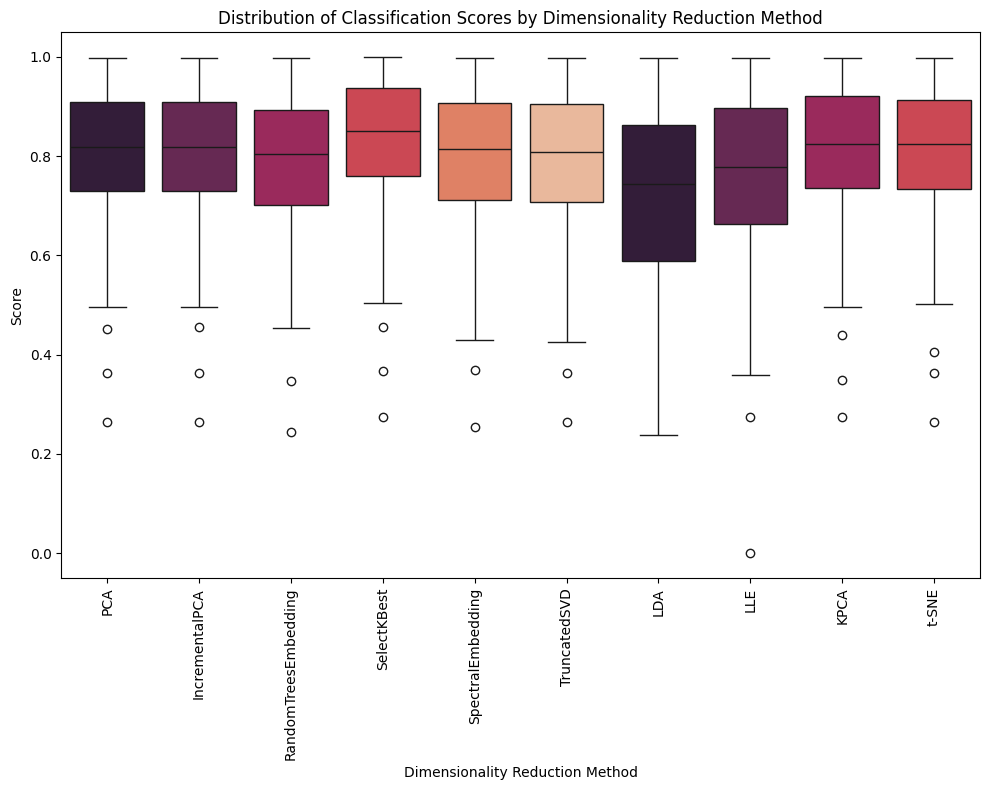

In [7]:
# Score Distribution by Dimensionality Reduction Method

import seaborn as sns
import matplotlib.pyplot as plt

# Convert from wide format to long format for plotting
df_melted = df_DR_technique_result.melt(
    var_name="Algorithm",
    value_name="Score"
)

plt.figure(figsize=(10, 8))
sns.boxplot(
    data=df_melted,
    x="Algorithm",
    y="Score",
    palette=sns.color_palette("rocket")
)

plt.xticks(rotation=90)
plt.title("Distribution of Classification Scores by Dimensionality Reduction Method")
plt.xlabel("Dimensionality Reduction Method")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [8]:
# # Ranking of Dimensionality Reduction Methods

# # Apply ranking (row-wise)
# df_ranking_algorithms = df_DR_technique_result.rank(
#     axis=1,
#     method='dense',
#     ascending=False
# ).astype(int)


# # Display
# df_ranking_algorithms.head(10)


# Apply ranking (row-wise)
df_ranking_algorithms = df_DR_technique_result.rank(
    axis=1,
    method='average',
    ascending=False
)


# Display
df_ranking_algorithms.head(10)

,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,4.5,4.5,10.0,2.0,1.0,4.5,8.0,7.0,9.0,4.5
1,5.0,2.5,6.0,4.0,9.0,2.5,10.0,1.0,7.0,8.0
2,9.0,9.0,4.0,3.0,2.0,9.0,5.0,1.0,7.0,6.0
3,9.0,9.0,3.0,2.0,5.0,9.0,4.0,1.0,7.0,6.0
4,5.0,5.0,7.0,1.0,8.0,5.0,9.5,9.5,2.0,3.0
5,5.0,5.0,7.0,1.0,8.0,5.0,9.5,9.5,2.0,3.0
6,6.0,6.0,9.0,1.0,3.0,6.0,10.0,4.0,8.0,2.0
7,6.5,6.5,8.0,1.0,9.0,5.0,4.0,10.0,2.0,3.0
8,8.0,8.0,5.5,1.0,5.5,8.0,10.0,2.0,3.5,3.5
9,8.0,8.0,5.5,1.0,5.5,8.0,10.0,2.0,3.5,3.5


In [9]:
df_DR_technique_result.head(10)

,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.363000,0.363000,0.346500,0.367000,0.370000,0.363000,0.359500,0.360000,0.349000,0.363000
1,0.518077,0.535202,0.517951,0.535112,0.512345,0.535202,0.502929,0.548392,0.516155,0.514286
2,0.847226,0.847226,0.859301,0.871655,0.877669,0.847226,0.856410,0.880699,0.850256,0.856224
3,0.824294,0.824294,0.868249,0.874972,0.847966,0.824294,0.861525,0.881751,0.834350,0.844463
4,0.729000,0.729000,0.723000,0.760000,0.711000,0.729000,0.682000,0.682000,0.735000,0.733000
5,0.729000,0.729000,0.723000,0.760000,0.711000,0.729000,0.682000,0.682000,0.735000,0.733000
6,0.545500,0.545500,0.533000,0.624000,0.552000,0.545500,0.487000,0.548667,0.537500,0.553500
7,0.749000,0.749000,0.747000,0.783500,0.737000,0.749500,0.751500,0.701333,0.769000,0.758500
8,0.885490,0.885490,0.889333,0.905098,0.889333,0.885490,0.869569,0.897255,0.889412,0.889412
9,0.885490,0.885490,0.889333,0.905098,0.889333,0.885490,0.869569,0.897255,0.889412,0.889412


Before performing the meta-learning stage, the classification results obtained from each dimensionality reduction method are transformed into a ranking representation. This step is important because the meta-model learns to recommend the best technique based on relative performance rather than absolute scores.

For each dataset (row), the algorithms are ranked according to their classification performance, where higher scores receive better positions (i.e., rank 1 corresponds to the best-performing method). This is achieved using a descending ranking strategy. In the presence of ties, the average ranking method is adopted, assigning the mean rank to tied values. Finally, the ranking values are converted to integers to standardize the representation.

# Analise Meta-Feature

## Meta-features (pymfe)

🔗 Documentation: https://pymfe.readthedocs.io/en/latest/auto_pages/meta_features_description.html

## Summaries

- **mean**: Average value of each attribute
- **sd**: Standard deviation of each attribute 

## Group: General

- **freq_class.mean**: frequência relativa média de cada classe distinta  
- **freq_class.sd**: desvio padrão da frequência relativa das classes  
- **nr_num**: número de características numéricas  
- **nr_attr**: número total de atributos  
- **attr_to_inst**: proporção entre número de atributos e instâncias  
- **nr_inst**: número de instâncias (linhas) no conjunto de dados  
- **inst_to_attr**: proporção entre número de instâncias e atributos  
- **nr_class**: número de classes distintas  
- **nr_bin**: número de atributos binários  

## Group Statistical

- **can_cor**: Canonical correlations of data
- **g_mean**: Geometric mean of each attribute
- **h_mean**: Harmonic mean of each attribute


In [22]:
def load_metafeatures(path):
    df = pd.read_csv(path)

    # manter só numérico
    df = df.select_dtypes(include=[np.number])

    # limpar valores problemáticos
    df = df.replace([np.inf, -np.inf], np.nan)

    # preencher NaN
    df = df.fillna(df.mean())

    return df

all_metafeatures = load_metafeatures(
    "data/metafeatures/new_meta_features.csv"
)

In [23]:
from sklearn.feature_selection import VarianceThreshold


def remover_colunas_nan(df, threshold_nan=0.05):
    total_antes = df.shape[1]

    nan_ratio = df.isna().mean()
    colunas_removidas = nan_ratio[nan_ratio >= threshold_nan].index.tolist()

    df_filtrado = df.drop(columns=colunas_removidas)

    print("\nRemoção de colunas com NaN")
    print(f"Limite de NaN          : {threshold_nan * 100:.2f}%")
    print(f"Total de colunas antes : {total_antes}")
    print(f"Total de colunas depois: {df_filtrado.shape[1]}")
    print(f"Colunas removidas      : {len(colunas_removidas)}")

    if colunas_removidas:
        print("\nColunas removidas por NaN:")
        for col in colunas_removidas:
            print(f"- {col}: {nan_ratio[col] * 100:.2f}% NaN")

    return df_filtrado, colunas_removidas


def remover_baixa_variancia(df, threshold_variancia=0.01):
    total_antes = df.shape[1]

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    non_numeric_cols = df.columns.difference(numeric_cols)

    selector = VarianceThreshold(threshold=threshold_variancia)
    selector.fit(df[numeric_cols])

    colunas_mantidas = numeric_cols[selector.get_support()].tolist()
    colunas_removidas = numeric_cols[~selector.get_support()].tolist()

    df_filtrado = df[colunas_mantidas + non_numeric_cols.tolist()]

    print("\nRemoção de colunas com baixa variância")
    print(f"Limite de variância    : {threshold_variancia}")
    print(f"Total de colunas antes : {total_antes}")
    print(f"Total de colunas depois: {df_filtrado.shape[1]}")
    print(f"Colunas removidas      : {len(colunas_removidas)}")

    if colunas_removidas:
        print("\nColunas removidas por baixa variância:")
        for col in colunas_removidas:
            print(f"- {col}: variância = {df[col].var():.6f}")

    return df_filtrado, colunas_removidas


def remover_alta_correlacao(df, threshold_corr=0.95):
    total_antes = df.shape[1]

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    non_numeric_cols = df.columns.difference(numeric_cols)

    corr_matrix = df[numeric_cols].corr().abs()

    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    colunas_removidas = [
        col for col in upper_triangle.columns
        if any(upper_triangle[col] >= threshold_corr)
    ]

    df_filtrado = df.drop(columns=colunas_removidas)

    print("\nRemoção de colunas altamente correlacionadas")
    print(f"Limite de correlação   : {threshold_corr}")
    print(f"Total de colunas antes : {total_antes}")
    print(f"Total de colunas depois: {df_filtrado.shape[1]}")
    print(f"Colunas removidas      : {len(colunas_removidas)}")

    if colunas_removidas:
        print("\nColunas removidas por alta correlação:")
        for col in colunas_removidas:
            corr_max = upper_triangle[col].max()
            print(f"- {col}: correlação máxima = {corr_max:.4f}")

    return df_filtrado, colunas_removidas


def selecionar_metafeatures(
    df,
    threshold_nan=0.05,
    threshold_variancia=0.01,
    threshold_corr=0.95
):
    print("=" * 70)
    print("PROCESSO DE SELEÇÃO DE METAFEATURES")
    print("=" * 70)

    total_inicial = df.shape[1]

    df, removidas_nan = remover_colunas_nan(
        df,
        threshold_nan=threshold_nan
    )

    df, removidas_variancia = remover_baixa_variancia(
        df,
        threshold_variancia=threshold_variancia
    )

    df, removidas_corr = remover_alta_correlacao(
        df,
        threshold_corr=threshold_corr
    )

    total_final = df.shape[1]

    print("\n" + "=" * 70)
    print("RESUMO FINAL")
    print("=" * 70)
    print(f"Total inicial de colunas : {total_inicial}")
    print(f"Total final de colunas   : {total_final}")
    print(f"Total removidas          : {total_inicial - total_final}")
    print(f"Removidas por NaN        : {len(removidas_nan)}")
    print(f"Removidas por variância  : {len(removidas_variancia)}")
    print(f"Removidas por correlação : {len(removidas_corr)}")

    relatorio = {
        "nan": removidas_nan,
        "baixa_variancia": removidas_variancia,
        "alta_correlacao": removidas_corr
    }

    return df, relatorio

In [24]:
all_metafeatures_filtrado, relatorio_remocao = selecionar_metafeatures(
    all_metafeatures,
    threshold_nan=0.05,
    threshold_variancia=0.01,
    threshold_corr=0.95
)

PROCESSO DE SELEÇÃO DE METAFEATURES

Remoção de colunas com NaN
Limite de NaN          : 5.00%
Total de colunas antes : 1146
Total de colunas depois: 1034
Colunas removidas      : 112

Colunas removidas por NaN:
- attr_conc.quantiles: 100.00% NaN
- attr_ent.quantiles: 100.00% NaN
- best_node.quantiles: 100.00% NaN
- best_node.quantiles.relative: 100.00% NaN
- can_cor.quantiles: 100.00% NaN
- class_conc.quantiles: 100.00% NaN
- cohesiveness.quantiles: 100.00% NaN
- conceptvar.quantiles: 100.00% NaN
- cor.quantiles: 100.00% NaN
- cov.quantiles: 100.00% NaN
- eigenvalues.quantiles: 100.00% NaN
- elite_nn.quantiles: 100.00% NaN
- elite_nn.quantiles.relative: 100.00% NaN
- f1.quantiles: 100.00% NaN
- f1v.histogram.0: 100.00% NaN
- f1v.histogram.1: 100.00% NaN
- f1v.histogram.2: 100.00% NaN
- f1v.histogram.3: 100.00% NaN
- f1v.histogram.4: 100.00% NaN
- f1v.histogram.5: 100.00% NaN
- f1v.histogram.6: 100.00% NaN
- f1v.histogram.7: 100.00% NaN
- f1v.histogram.8: 100.00% NaN
- f1v.histogram.9:

In [25]:
all_metafeatures = all_metafeatures_filtrado.copy()
all_metafeatures.shape

(94, 453)

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

all_metafeatures_scaled = pd.DataFrame(
    scaler.fit_transform(all_metafeatures),
    columns=all_metafeatures.columns,
    index=all_metafeatures.index
)

all_metafeatures_scaled.head()

scaler = MinMaxScaler()

all_metafeatures_scaled = pd.DataFrame(
    scaler.fit_transform(all_metafeatures),
    columns=all_metafeatures.columns,
    index=all_metafeatures.index
)

all_metafeatures_scaled.head()

,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.5,attr_conc.histogram.9,attr_conc.max,attr_ent.histogram.0,attr_ent.histogram.5,attr_ent.histogram.9,attr_ent.max,attr_ent.mean,...,worst_node.histogram.9,worst_node.histogram.9.relative,worst_node.max,worst_node.max.relative,worst_node.mean,worst_node.mean.relative,worst_node.median.relative,worst_node.min,worst_node.min.relative,worst_node.sd.relative
0,0.000000,0.000000,1.000000,0.000000,1.958984e-08,0.000000,1.000000,0.000000,0.407383,0.426402,...,0.111111,0.166667,0.773542,0.666667,0.547618,0.500000,0.500000,0.381691,0.333333,0.666667
1,0.098718,0.380503,0.194444,0.055556,4.557519e-01,0.115741,0.222222,0.116959,0.577938,0.276131,...,0.444444,0.916667,0.939827,0.166667,0.872312,0.000000,0.166667,0.722630,0.000000,1.000000
2,0.779670,0.311321,0.000000,0.035714,2.043930e-01,0.130208,0.000000,0.657895,0.668690,0.625416,...,0.888889,1.000000,0.519670,0.083333,0.542610,0.000000,0.250000,0.489896,0.083333,0.166667
3,0.561538,0.641509,0.030303,0.015152,3.014333e-01,0.080128,0.000000,0.323887,0.488367,0.215178,...,0.222222,0.666667,0.583988,0.083333,0.505869,0.333333,0.250000,0.502734,0.666667,0.333333
4,0.576923,0.452830,0.000000,0.030303,8.013236e-01,0.115741,0.000000,0.818713,0.668603,0.667593,...,0.111111,0.166667,0.164262,0.166667,0.155616,0.333333,0.333333,0.200363,0.333333,0.166667


## Análise Índice de Impacto Ponderado

In [27]:
ranking_columns = df_ranking_algorithms.columns.tolist()

all_results = {}

n = len(ranking_columns)  # número de técnicas
k = 3                    # exemplo da teoria

denominator = n * (n + 1) - k * (k + 1)

for rank_col in ranking_columns:

    technique_rank = df_ranking_algorithms[rank_col]

    MF_names = []
    MF_impact_indices = []

    for mf_name in all_metafeatures_scaled.columns:

        mf_values = (
            all_metafeatures_scaled[mf_name]
            .fillna(0)
            .replace([np.inf, -np.inf], 0)
        )

        # Média da MF quando α está no Top-k
        top_k_mask = technique_rank <= k

        mf_top_k = mf_values[top_k_mask]

        mean_top_k = (
            mf_top_k.mean()
            if not mf_top_k.empty
            else 0
        )

        # Somatório da teoria
        impact_index = 0.0

        for i in range(k + 1, n + 1):

            pos_i_mask = technique_rank == i

            mf_i = mf_values[pos_i_mask]

            mean_i = (
                mf_i.mean()
                if not mf_i.empty
                else 0
            )

            impact_index += (
                (mean_top_k - mean_i)
                * (2 * i)
            )

        impact_index /= denominator

        MF_names.append(mf_name)
        MF_impact_indices.append(impact_index)

    results_df = pd.DataFrame({
        "MetaFeature": MF_names,
        "Impact_Index": MF_impact_indices
    })

    all_results[rank_col] = results_df

In [28]:
top_30_results = {}

for technique_name, results_df in all_results.items():
    
    df_top = results_df.copy()

    # Pega as 30 metafeatures com maior Impact_Index positivo
    # Ou seja, aquelas mais associadas ao algoritmo ficar em 1º lugar
    df_top = (
        df_top
        .sort_values(by="Impact_Index", ascending=False)
            .head(50)
        .reset_index(drop=True)
    )

    top_30_results[technique_name] = df_top

In [29]:
for technique_name, df_top in top_30_results.items():
    print("=" * 80)
    print(f"Técnica: {technique_name}")
    print("=" * 80)
    print(df_top)
    print()

Técnica: PCA
                          MetaFeature  Impact_Index
0      best_node.histogram.0.relative      0.345050
1             naive_bayes.sd.relative      0.308858
2              best_node.min.relative      0.298759
3                             cor.max      0.283064
4    naive_bayes.histogram.1.relative      0.280847
5         one_nn.histogram.4.relative      0.274090
6                         hubs.median      0.250629
7         one_nn.histogram.1.relative      0.248466
8             eigenvalues.histogram.0      0.243227
9             one_itemset.histogram.0      0.234224
10    worst_node.histogram.2.relative      0.232999
11   naive_bayes.histogram.3.relative      0.221949
12           random_node.min.relative      0.218376
13          leaves_corrob.histogram.0      0.209624
14                            max.min      0.204081
15      elite_nn.histogram.6.relative      0.199757
16   random_node.histogram.5.relative      0.194828
17             class_conc.histogram.1      0.193971

In [30]:
# Se quiser juntar tudo em um único DataFrame:

top_30_all_techniques = []

for technique_name, df_top in top_30_results.items():
    df_temp = df_top.copy()
    top_30_all_techniques.append(df_temp)

top_30_all_techniques = pd.concat(
    top_30_all_techniques,
    ignore_index=True
)

top_30_all_techniques

,MetaFeature,Impact_Index
0,best_node.histogram.0.relative,0.345050
1,naive_bayes.sd.relative,0.308858
2,best_node.min.relative,0.298759
3,cor.max,0.283064
4,naive_bayes.histogram.1.relative,0.280847
...,...,...
495,cor.histogram.0,0.082204
496,linear_discr.histogram.5,0.080762
497,worst_node.histogram.1,0.079406
498,naive_bayes.histogram.9.relative,0.078982


In [31]:

top_30_all_techniques.to_csv(
    "top_30_metafeatures_by_technique.csv",
    index=False
)

# Se quiser usar essas metafeatures para formar um conjunto único:

selected_metafeatures = (
    top_30_all_techniques["MetaFeature"]
    .drop_duplicates()
    .tolist()
)

print(f"Total de metafeatures únicas selecionadas: {len(selected_metafeatures)}")

# Criar um novo dataset só com essas metafeatures:

all_metafeatures_selected = all_metafeatures_scaled[selected_metafeatures].copy()

print(all_metafeatures_selected.shape)

Total de metafeatures únicas selecionadas: 287
(94, 287)


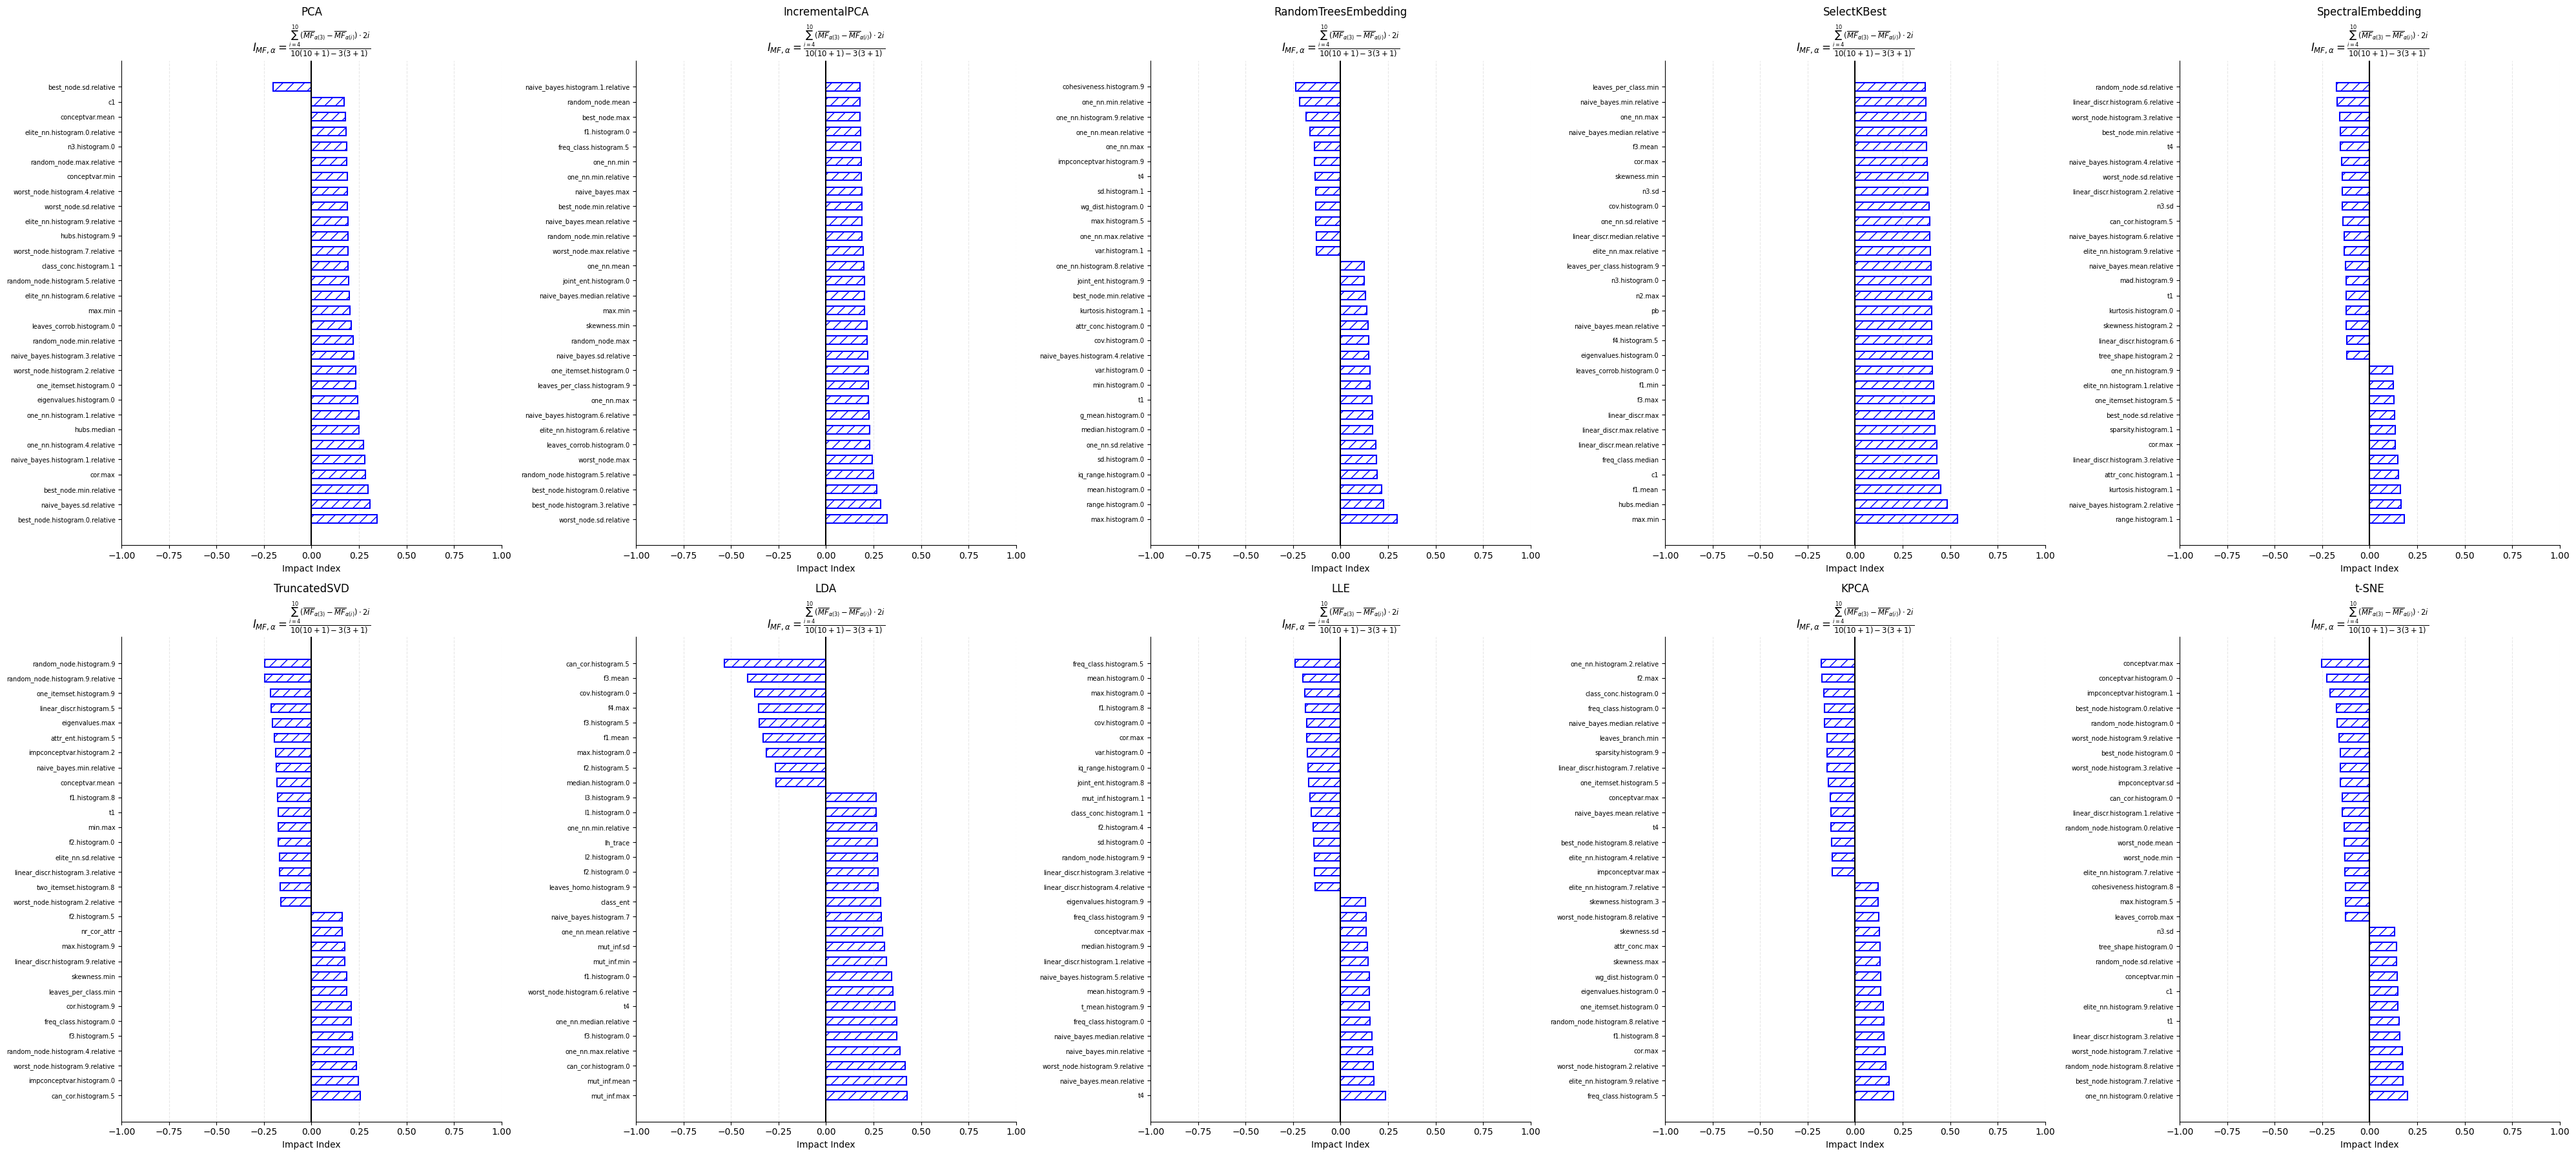

In [32]:
top_n = 30
n = len(df_ranking_algorithms.columns)
k = 3

fig, axs = plt.subplots(
    2,
    5,
    figsize=(40, 18),
    sharex=False
)

axs_flat = axs.flatten()

for i, (technique_name, results_df) in enumerate(all_results.items()):

    ax = axs_flat[i]

    df_plot = results_df.copy()

    # Top 30 maiores impactos em valor absoluto
    df_plot["abs_impact"] = df_plot["Impact_Index"].abs()

    df_plot = (
        df_plot
        .sort_values(by="abs_impact", ascending=False)
        .head(top_n)
        .sort_values(by="Impact_Index", ascending=True)
    )

    labels = df_plot["MetaFeature"]
    y = np.arange(len(df_plot))

    bars = ax.barh(
        y,
        df_plot["Impact_Index"],
        height=0.55,
        edgecolor="blue",
        linewidth=1.5,
        fill=False
    )

    for bar in bars:
        bar.set_hatch("//")

    ax.axvline(0, color="black", linewidth=1.5)

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=7)

    ax.invert_yaxis()

    max_val = df_plot["Impact_Index"].abs().max()

    limite = max(
        1.0,
        np.ceil(max_val * 1.2 / 0.25) * 0.25
    )

    ax.set_xlim(-limite, limite)

    # Nome da técnica separado da fórmula para não quebrar o LaTeX
    ax.set_title(
        rf'{technique_name}' '\n'
        rf'$I_{{MF,\alpha}}='
        rf'\frac{{\sum_{{i={k+1}}}^{{{n}}}'
        rf'(\overline{{MF}}_{{\alpha({k})}}'
        rf'-\overline{{MF}}_{{\alpha(i)}})\cdot 2i}}'
        rf'{{{n}({n}+1)-{k}({k}+1)}}$',
        fontsize=12,
        pad=10
    )

    ax.set_xlabel("Impact Index", fontsize=10)

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Remove subplots vazios
for j in range(i + 1, len(axs_flat)):
    fig.delaxes(axs_flat[j])

plt.tight_layout()

plt.savefig(
    "impact_index_all_techniques.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# Meta Data

In [33]:
def load_metafeatures(csv_path, drop_name=True):
    """
    Load a meta-feature dataset from a CSV file.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file.
    drop_name : bool, optional
        Whether to drop the 'Name' column. Default is True.

    Returns
    -------
    pd.DataFrame
        Loaded meta-feature DataFrame.
    """
    df = pd.read_csv(csv_path)

    if drop_name and "Name" in df.columns:
        df = df.drop(columns=["Name"])

    return df

def merge_with_rankings(metafeatures_df, rankings_df, include_name=False, dataset_names=None):
    """
    Merge a meta-feature dataset with the algorithm ranking dataset.

    Parameters
    ----------
    metafeatures_df : pd.DataFrame
        Meta-feature DataFrame.
    rankings_df : pd.DataFrame
        Ranking DataFrame.
    include_name : bool, optional
        Whether to include the 'Name' column in the final DataFrame.
    dataset_names : pd.Series or pd.DataFrame, optional
        Dataset names to include when include_name=True.

    Returns
    -------
    pd.DataFrame
        Combined DataFrame.
    """
    rankings_only = rankings_df.copy()

    if "Name" in rankings_only.columns:
        rankings_only = rankings_only.drop(columns=["Name"])

    merged_df = pd.concat([metafeatures_df.reset_index(drop=True),
                           rankings_only.reset_index(drop=True)], axis=1)

    if include_name and dataset_names is not None:
        merged_df.insert(0, "Name", dataset_names.reset_index(drop=True))

    return merged_df


In [34]:
all_meta_dataset = merge_with_rankings(
    metafeatures_df=all_metafeatures_selected,
    rankings_df=df_ranking_algorithms,
    include_name=False
)

all_meta_dataset.head(10)

,best_node.histogram.0.relative,naive_bayes.sd.relative,best_node.min.relative,cor.max,naive_bayes.histogram.1.relative,one_nn.histogram.4.relative,hubs.median,one_nn.histogram.1.relative,eigenvalues.histogram.0,one_itemset.histogram.0,...,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.909091,0.500000,0.000000,0.000000,0.250000,0.000000,1.000000,0.818182,0.000000,0.000000,...,4.5,4.5,10.0,2.0,1.0,4.5,8.0,7.0,9.0,4.5
1,0.363636,0.000000,0.333333,0.906882,0.583333,0.636364,0.325090,0.000000,0.907407,0.588783,...,5.0,2.5,6.0,4.0,9.0,2.5,10.0,1.0,7.0,8.0
2,0.181818,0.333333,0.583333,0.544341,1.000000,0.545455,0.707271,0.272727,0.893229,0.091258,...,9.0,9.0,4.0,3.0,2.0,9.0,5.0,1.0,7.0,6.0
3,0.272727,0.166667,0.500000,0.609712,0.500000,0.454545,0.768735,0.454545,0.785256,0.081524,...,9.0,9.0,3.0,2.0,5.0,9.0,4.0,1.0,7.0,6.0
4,0.181818,1.000000,0.500000,0.996318,0.750000,0.727273,1.000000,0.181818,0.964120,0.058047,...,5.0,5.0,7.0,1.0,8.0,5.0,9.5,9.5,2.0,3.0
5,0.727273,0.166667,0.500000,0.716050,0.916667,1.000000,0.889824,0.454545,0.840686,0.835522,...,5.0,5.0,7.0,1.0,8.0,5.0,9.5,9.5,2.0,3.0
6,0.363636,1.000000,0.500000,0.716050,0.416667,0.272727,0.990377,0.363636,1.000000,0.149632,...,6.0,6.0,9.0,1.0,3.0,6.0,10.0,4.0,8.0,2.0
7,0.272727,0.666667,0.333333,0.886732,0.666667,1.000000,0.550643,0.090909,0.928030,0.016543,...,6.5,6.5,8.0,1.0,9.0,5.0,4.0,10.0,2.0,3.0
8,0.090909,0.166667,0.583333,0.196443,0.333333,0.090909,0.999447,0.272727,0.510417,0.339683,...,8.0,8.0,5.5,1.0,5.5,8.0,10.0,2.0,3.5,3.5
9,0.272727,0.500000,0.166667,0.455104,0.750000,0.818182,1.000000,0.727273,0.510417,0.059944,...,8.0,8.0,5.5,1.0,5.5,8.0,10.0,2.0,3.5,3.5


# Meta-Model

In [131]:
# Target columns (algorithm rankings)
TARGET_COLUMNS = [
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

SELECTED_FEATURES = all_metafeatures_selected.columns.tolist()


# Helper functions
def prepare_features(dataframe, feature_columns):
    """
    Select, clean, and scale the predictive features.
    """
    X = dataframe[feature_columns].copy()
    X = X.fillna(0)
    X = X.replace([np.inf, -np.inf], 0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled


# def train_meta_model_loo(dataframe, feature_columns, target_columns, output_filename, model=None):
#     """
#     Train one meta-model per target using Leave-One-Out cross-validation.

#     Parameters
#     ----------
#     dataframe : pd.DataFrame
#         Meta-dataset containing predictive features and ranking targets.
#     feature_columns : list
#         List of feature column names.
#     target_columns : list
#         List of target column names.
#     output_filename : str
#         Output CSV filename for predictions.
#     model : sklearn regressor, optional
#         Regression model. If None, a default RandomForestRegressor is used.

#     Returns
#     -------
#     pd.DataFrame
#         DataFrame containing the predicted rankings for all targets.
#     """
#     # i want importance of features
#     if model is None:
#         model = RandomForestRegressor(
#             n_estimators=100,
#             random_state=42,
#             n_jobs=-1,
#             min_samples_split=4,
#             min_samples_leaf=3
#         )

#     X = dataframe[feature_columns].copy()
#     X = X.fillna(0)
#     X = X.replace([np.inf, -np.inf], 0)

#     y_all = dataframe[target_columns].copy()

#     loo = LeaveOneOut()
#     prediction_dict = {}
#     importance_metafeature = []

#     for target in target_columns:
#         y = y_all[target]
#         fold_predictions = []

#         for train_index, test_index in loo.split(X):
#             X_train = X.iloc[train_index].copy()
#             X_test = X.iloc[test_index].copy()
#             y_train = y.iloc[train_index]

#             scaler = StandardScaler()
#             X_train = scaler.fit_transform(X_train)
#             X_test = scaler.transform(X_test)

#             model.fit(X_train, y_train)
#             importance_metafeature.append(model.feature_importances_)
#             y_pred = model.predict(X_test)
#             fold_predictions.append(y_pred[0])

#         prediction_dict[f'PredictedRank_{target}'] = pd.Series(fold_predictions)

#     predictions_df = pd.DataFrame(prediction_dict)
#     predictions_df.to_csv(output_filename, index=False)

#     return predictions_df, importance_metafeature


def train_meta_model_loo(dataframe, feature_columns, target_columns, output_filename, model=None):
    """
    Train one meta-model per target using 5-Fold Cross-Validation.
    """

    if model is None:
        model = RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1,
            min_samples_split=4,
            min_samples_leaf=3,
            max_features="sqrt"
        )

    X = dataframe[feature_columns].copy()
    X = X.fillna(0)
    X = X.replace([np.inf, -np.inf], 0)

    y_all = dataframe[target_columns].copy()

    kfold = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    prediction_dict = {}
    importance_metafeature = []

    for target in target_columns:
        print(f"\n[INFO] Training target: {target}")

        y = y_all[target]
        fold_predictions = np.zeros(len(X))

        for fold_id, (train_index, test_index) in enumerate(kfold.split(X), start=1):
            print(f"  Fold {fold_id}/5")

            X_train = X.iloc[train_index].copy()
            X_test = X.iloc[test_index].copy()
            y_train = y.iloc[train_index]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model.fit(X_train, y_train)

            importance_metafeature.append(model.feature_importances_)

            y_pred = model.predict(X_test)

            fold_predictions[test_index] = y_pred

        prediction_dict[f'PredictedRank_{target}'] = pd.Series(fold_predictions)

    predictions_df = pd.DataFrame(prediction_dict)
    predictions_df.to_csv(output_filename, index=False)

    return predictions_df, importance_metafeature

In [ ]:
predictions_all, importance_all = train_meta_model_loo(
    dataframe=all_meta_dataset,
    feature_columns=SELECTED_FEATURES,
    target_columns=TARGET_COLUMNS,
    output_filename='data/predictions/predictions_ranking.csv'
)


[INFO] Training target: PCA
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: IncrementalPCA
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: RandomTreesEmbedding
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: SelectKBest
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: SpectralEmbedding
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: TruncatedSVD
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: LDA
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: LLE
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: KPCA
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: t-SNE
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5


Features selecionadas: 25


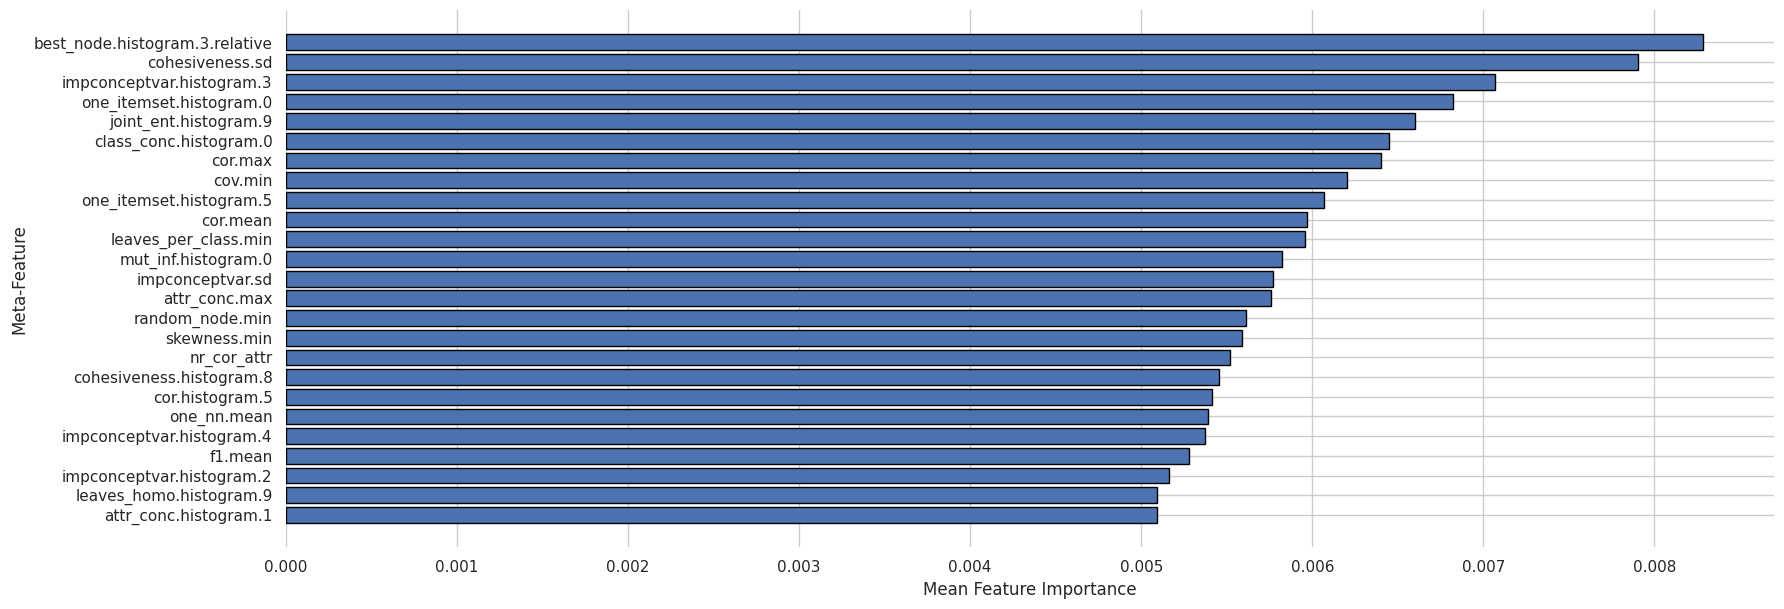

In [127]:
importance_metafeature = importance_all

importance_mean = np.mean(
    importance_metafeature,
    axis=0
)

importance_df = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "importance": importance_mean
})

# Mantém apenas features com importância
importance_df = importance_df[
                    importance_df["importance"] > 0.005

].copy()

print(f"Features selecionadas: {len(importance_df)}")

# Ordena para visualização
importance_df = (
    importance_df
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(18, max(6, len(importance_df) * 0.25)))

plt.barh(
    importance_df["feature"],
    importance_df["importance"],
    edgecolor="black"
)

plt.xlabel("Mean Feature Importance")
plt.ylabel("Meta-Feature")

# plt.title(
#     f"Meta-Features com Importance ({len(importance_df)} features)",
#     fontsize=16
# )

plt.box(False)

plt.tight_layout()

plt.savefig(
    "selected_metafeatures_importance_above.pdf",
    format="pdf",
    bbox_inches="tight"
) 

plt.show()

In [128]:
FINAL_SELECTED_FEATURES = (
    importance_df["feature"]
    .tolist()
)

print(f"Total final: {len(FINAL_SELECTED_FEATURES)}")

Total final: 25


In [129]:
predictions_final, importance_final = train_meta_model_loo(
    dataframe=all_meta_dataset,
    feature_columns=FINAL_SELECTED_FEATURES,
    target_columns=TARGET_COLUMNS,
    output_filename="data/predictions/predictions_ranking.csv"
)


[INFO] Training target: PCA
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: IncrementalPCA
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: RandomTreesEmbedding
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: SelectKBest
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: SpectralEmbedding
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: TruncatedSVD
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: LDA
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: LLE
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: KPCA
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

[INFO] Training target: t-SNE
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5


# Spearman Rank Correlation (SRC) Evaluation

## Meta-Model Ranking vs. Dimensionality Reduction Algorithm Ranking (All Meta-Features)

[0.06253053994807224, 0.34650615989763683, -0.19019836693335312, 0.2024692293161501, 0.9354953314429287, 0.947804480540862, 0.31290699076132283, 0.5106406566912542, 0.8828674456704912, 0.9199108349993231, 0.38768934767804786, 0.5828659631828563, 0.12884405501936824, 0.5471149893120582, 0.3525852153344375, 0.8145934285312865, 0.6810328622452321, -0.18192637473571155, 0.754658036542014, 0.5410359338752574, 0.06748974310538336, 0.6319494127140443, 0.8510677611520904, 0.590244307061843, 0.2249250511616239, 0.828283210838796, 0.8405540732215928, 0.5828659631828563, 0.828283210838796, 0.7939393939393938, 0.6297376185901407, 0.6442202750968412, 0.5460533760344654, 0.7781190959104828, 0.4724282017376836, 0.3006361283785259, 0.8632258720256917, 0.2857156055296304, 0.49391162098847435, 0.4800568148193976, 0.46015733935488656, 0.766928898924811, 0.8024353176576853, 0.40121765882884264, 0.6378115074703368, 0.27609440361293197, 0.6036697589859131, 0.5705951008000594, 0.3497195779097138, 0.572375433

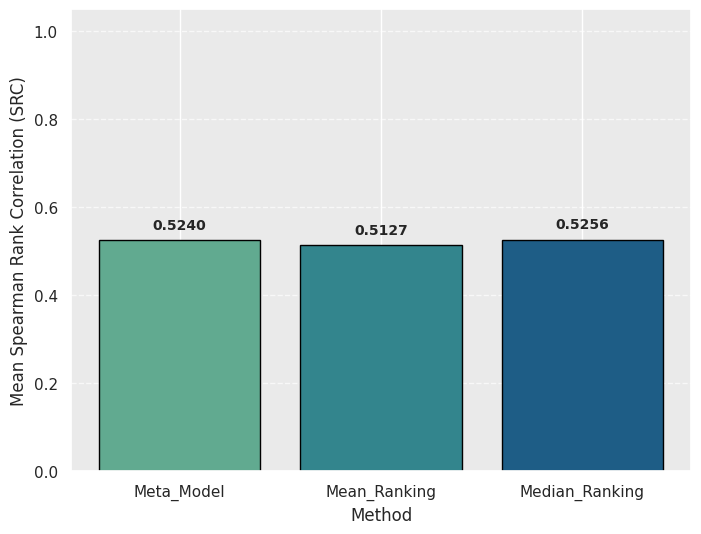

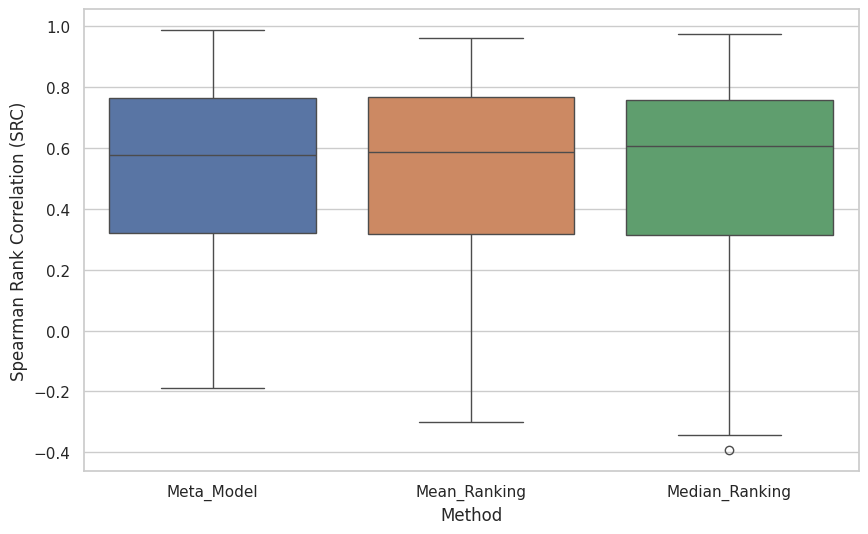

In [149]:
from scipy.stats import spearmanr
from sklearn.model_selection import LeaveOneOut

df_predicted_ranking_all_metafeatures = pd.read_csv(
    'data/predictions/predictions_ranking.csv'
)


# Compute Spearman correlation (True vs Predicted)
spearman_values_all_metafeatures = []

for i in range(len(df_ranking_algorithms)):
    true_rank = df_ranking_algorithms.iloc[i].tolist()
    predicted_rank = df_predicted_ranking_all_metafeatures.iloc[i].tolist()

    # Check for invalid cases (NaN or constant values)
    if (len(set(true_rank)) <= 1 or len(set(predicted_rank)) <= 1
        or np.isnan(true_rank).any() or np.isnan(predicted_rank).any()):
        spearman_values_all_metafeatures.append(np.nan)
        continue

    coef, _ = spearmanr(true_rank, predicted_rank)
    spearman_values_all_metafeatures.append(coef)

# Replace NaN values with 0
spearman_values_all_metafeatures = np.nan_to_num(
    spearman_values_all_metafeatures,
    nan=0.0
).tolist()

print(spearman_values_all_metafeatures)


# Baseline comparison (Mean and Median rankings)
true_rankings = df_ranking_algorithms.values.tolist()
df_true_rankings = pd.DataFrame(true_rankings)

loo = LeaveOneOut()

baseline_results_all_metafeatures = []

for train_index, test_index in loo.split(df_true_rankings):
    df_train = df_true_rankings.iloc[train_index]
    df_test = df_true_rankings.iloc[test_index]

    # Compute mean and median rankings from the training set
    mean_ranking = df_train.mean()
    median_ranking = df_train.median()

    # Compare the test instance with the baseline rankings
    rho_mean, _ = spearmanr(df_test.values.flatten(), mean_ranking.values)
    rho_median, _ = spearmanr(df_test.values.flatten(), median_ranking.values)

    baseline_results_all_metafeatures.append({
        "spearman_mean": rho_mean,
        "spearman_median": rho_median
    })

# Convert results to DataFrame
df_baseline_all_metafeatures = pd.DataFrame(
    baseline_results_all_metafeatures
).fillna(0.0)

df_baseline_all_metafeatures


# Combine results
df_model_all_metafeatures = pd.DataFrame(
    spearman_values_all_metafeatures,
    columns=['Meta_Model']
)

df_baseline_all_metafeatures = df_baseline_all_metafeatures.rename(columns={
    "spearman_mean": "Mean_Ranking",
    "spearman_median": "Median_Ranking"
})

df_comparative_all_metafeatures = pd.concat(
    [df_model_all_metafeatures, df_baseline_all_metafeatures],
    axis=1
)

df_comparative_all_metafeatures


# Bar plot (mean SRC per method)
mean_values_all_metafeatures = df_comparative_all_metafeatures.mean()

colors = sns.color_palette("crest", n_colors=len(mean_values_all_metafeatures))

plt.figure(figsize=(8, 6))
bars = plt.bar(
    mean_values_all_metafeatures.index,
    mean_values_all_metafeatures.values,
    color=colors,
    edgecolor="black"
)

plt.ylabel("Mean Spearman Rank Correlation (SRC)")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Boxplot (distribution of SRC values)
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_comparative_all_metafeatures)

plt.ylabel("Spearman Rank Correlation (SRC)")
plt.xlabel("Method")

plt.show()

# Comparative Analysis of Spearman Rank Correlation Across Meta-DR Variants and Baselines


--- 95% Confidence Intervals, Mean SRC, and Margin of Error ---
                   Mean SRC  CI Lower (95%)  CI Upper (95%)  Margin of Error
Meta-DR (All MFs)    0.5240          0.4642          0.5839           0.0599
Mean Baseline        0.5127          0.4485          0.5770           0.0642
Median Baseline      0.5256          0.4580          0.5933           0.0677


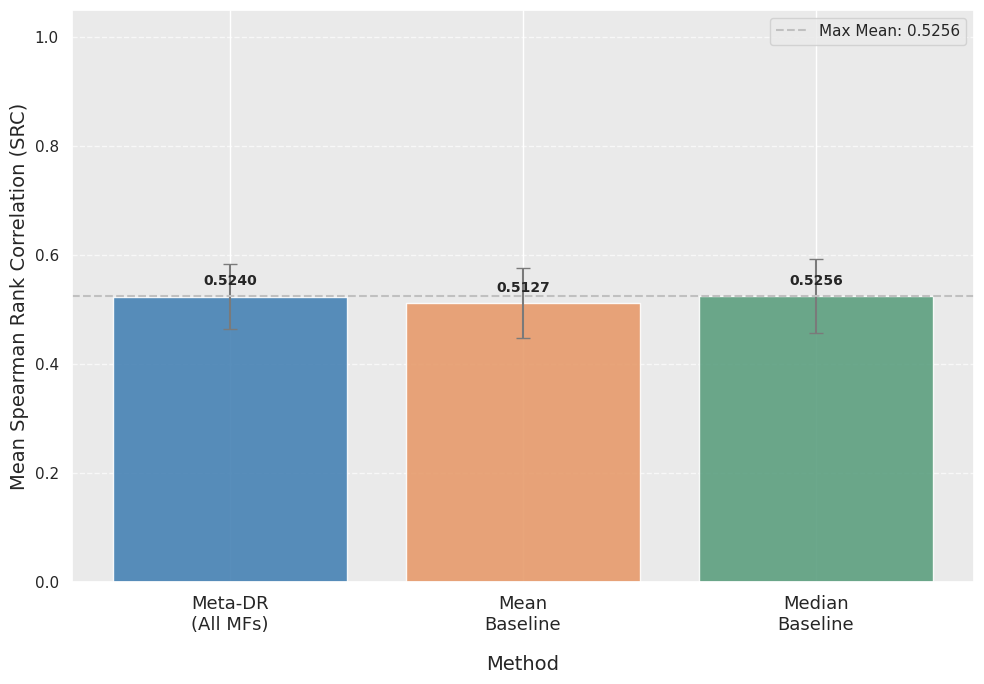

In [133]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats



df_all_metafeatures = pd.concat(
    [
        pd.DataFrame(spearman_values_all_metafeatures, columns=["Unified Proposal"]),
        pd.DataFrame(baseline_results_all_metafeatures)
    ],
    axis=1
)

# Rename baseline columns for consistency
for df in [df_all_metafeatures]:
    df.rename(
        columns={
            "spearman_mean": "Mean Baseline",
            "spearman_median": "Median Baseline"
        },
        inplace=True
    )

# Combine all methods into a single DataFrame
df_combined = pd.DataFrame({
    "Meta-DR (All MFs)": df_all_metafeatures["Unified Proposal"],
    "Mean Baseline": df_all_metafeatures["Mean Baseline"],
    "Median Baseline": df_all_metafeatures["Median Baseline"]
})

# Compute 95% confidence intervals
confidence_level = 0.95
alpha = 1 - confidence_level

means = df_combined.mean()
counts = df_combined.count()
stds = df_combined.std(ddof=1)
sems = stds / np.sqrt(counts)

try:
    margin_of_error = sems * stats.t.ppf(1 - alpha / 2, counts - 1)
except Exception as e:
    print(f"Warning: could not compute t-critical values. Error: {e}")
    margin_of_error = sems * 1.96

ci_lower = means - margin_of_error
ci_upper = means + margin_of_error

ci_df = pd.DataFrame({
    "Mean SRC": means,
    "CI Lower (95%)": ci_lower,
    "CI Upper (95%)": ci_upper,
    "Margin of Error": margin_of_error
}).reindex(means.index)

print("\n--- 95% Confidence Intervals, Mean SRC, and Margin of Error ---")
print(ci_df.to_string(float_format="{:.4f}".format))

# Bar plot with confidence intervals
sns.set_style("darkgrid")
sns.set(rc={"axes.facecolor": "#EAEAEA"})
plt.figure(figsize=(10, 7))

custom_colors = [
    "steelblue",  # Meta-DR (All MFs)
    "#E79B6C",    # Mean Baseline
    "#5C9F7F"     # Median Baseline
]

bars = plt.bar(
    means.index,
    means.values,
    yerr=margin_of_error.values,
    capsize=5,
    color=custom_colors,
    ecolor="#7A7A7A",
    alpha=0.9
)

# Reference line for the highest mean value
max_value = means.values.max()
plt.axhline(
    y=max_value,
    color="silver",
    linestyle="--",
    linewidth=1.5,
    label=f"Max Mean: {max_value:.4f}"
)

new_labels = [
    "Meta-DR\n(All MFs)",
    "Mean\nBaseline",
    "Median\nBaseline"
]

plt.ylabel("Mean Spearman Rank Correlation (SRC)", fontsize=14)
plt.xlabel("Method", fontsize=14, labelpad=15, x=0.5)
plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, fontsize=13)
plt.ylim(0, 1.05)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.savefig(
    "src_distributionbarIC.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

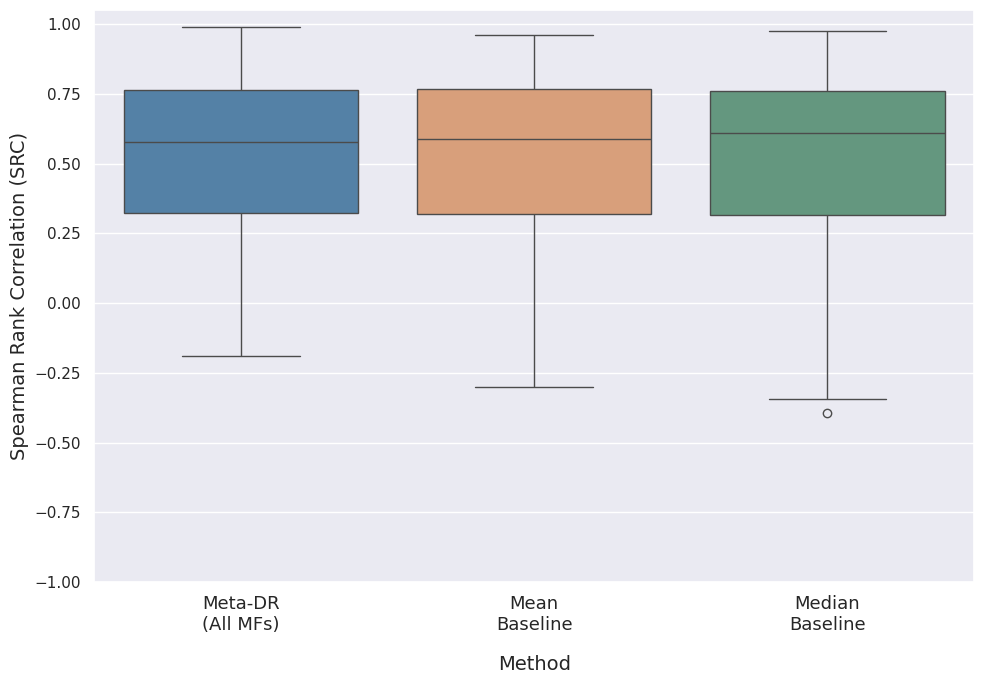

In [134]:


df_all_metafeatures = pd.concat(
    [
        pd.DataFrame(spearman_values_all_metafeatures, columns=["Unified Proposal"]),
        pd.DataFrame(baseline_results_all_metafeatures)
    ],
    axis=1
)

df_all_metafeatures = df_all_metafeatures.rename(columns={
    "spearman_mean": "Mean Baseline",
    "spearman_median": "Median Baseline"
})

# Combine all methods into a single DataFrame
df_combined = pd.DataFrame({
    "Meta-DR (All MFs)": df_all_metafeatures["Unified Proposal"],
    "Mean Baseline": df_all_metafeatures["Mean Baseline"],
    "Median Baseline": df_all_metafeatures["Median Baseline"]
})

# Convert to long format for seaborn
df_melted = df_combined.melt(var_name="Method", value_name="Spearman")

new_labels = [
    "Meta-DR\n(All MFs)",
    "Mean\nBaseline",
    "Median\nBaseline"
]

# Boxplot
sns.set(style="darkgrid")
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df_melted,
    x="Method",
    y="Spearman",
    palette=["steelblue", "#E79B6C", "#5C9F7F"]
)

plt.ylabel("Spearman Rank Correlation (SRC)", fontsize=14)
plt.xlabel("Method", fontsize=14, labelpad=15, x=0.5)
plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, fontsize=13)
plt.ylim(-1, 1.05)

plt.tight_layout()

plt.savefig(
    "src_distributionboxplot.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

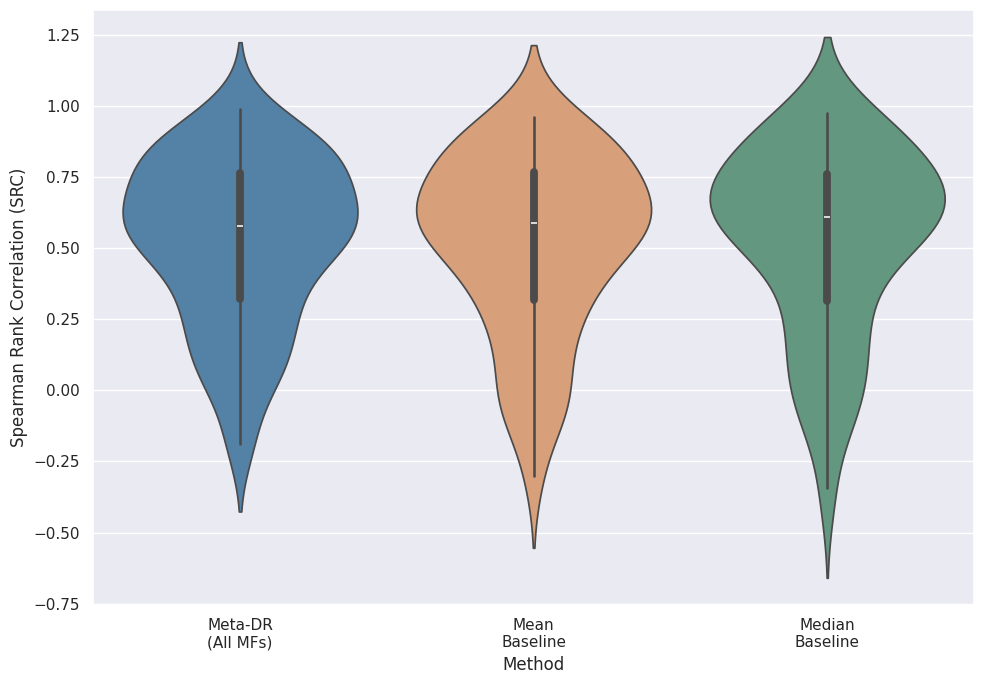

In [135]:
df_all_metafeatures = pd.concat(
    [
        pd.DataFrame(spearman_values_all_metafeatures, columns=["Unified Proposal"]),
        pd.DataFrame(baseline_results_all_metafeatures)
    ],
    axis=1
)

df_all_metafeatures = df_all_metafeatures.rename(columns={
    "spearman_mean": "Mean Baseline",
    "spearman_median": "Median Baseline"
})

# Combine all methods into a single DataFrame
df_combined = pd.DataFrame({
    "Meta-DR (All MFs)": df_all_metafeatures["Unified Proposal"],
    "Mean Baseline": df_all_metafeatures["Mean Baseline"],
    "Median Baseline": df_all_metafeatures["Median Baseline"]
})

# Convert to long format for seaborn
df_melted = df_combined.melt(var_name="Method", value_name="Spearman")

new_labels = [
    "Meta-DR\n(All MFs)",
    "Mean\nBaseline",
    "Median\nBaseline"
]

# Violin plot
sns.set(style="darkgrid")
plt.figure(figsize=(10, 7))

sns.violinplot(
    data=df_melted,
    x="Method",
    y="Spearman",
    palette=["steelblue", "#E79B6C", "#5C9F7F"]
)

plt.ylabel("Spearman Rank Correlation (SRC)", fontsize=12)
plt.xlabel("Method", fontsize=12)
plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

# Performance Comparison of Meta-DR Proposals, Baselines, and Dimensionality Reduction Techniques

In [136]:
ALGORITHMS = [
    'PCA',
    'IncrementalPCA',
    'RandomTreesEmbedding',
    'SelectKBest',
    'SpectralEmbedding',
    'TruncatedSVD',
    'LDA',
    'LLE',
    'KPCA',
    't-SNE'
]


# Load predicted rankings
df_predicted_all_metafeatures = pd.read_csv(
    'data/predictions/predictions_ranking.csv'
)

# Remove prefix if the CSV has columns like PredictedRank_PCA
df_predicted_all_metafeatures.columns = [
    col.replace('PredictedRank_', '')
    for col in df_predicted_all_metafeatures.columns
]

# Keep only algorithm columns and same order
df_predicted_all_metafeatures = df_predicted_all_metafeatures[ALGORITHMS]

# Ensure real performance has same algorithm columns
df_real_performance = df_DR_technique_result[ALGORITHMS].copy()


def calculate_proposal_performance(df_real_performance, df_predicted_ranking):
    results = []

    for i in range(len(df_real_performance)):
        predicted_ranks = df_predicted_ranking.iloc[i]

        # Best predicted rank: smaller is better
        recommended_algorithm = predicted_ranks.idxmin()

        # Real F1 of the recommended algorithm
        true_performance = df_real_performance.iloc[i][recommended_algorithm]

        results.append({
            'Dataset': i,
            'Recommended Algorithm': recommended_algorithm,
            'F1': true_performance
        })

    return pd.DataFrame(results)


# Unified proposal
unified_results = calculate_proposal_performance(
    df_real_performance,
    df_predicted_all_metafeatures
)


# Final comparison table
final_results_table = df_real_performance.copy()

final_results_table['Unified Proposal'] = unified_results['F1'].values


# Correct fixed-algorithm baseline:
# SelectKBest is a real fixed baseline, not the row-wise mean.
final_column_order = [
    'Unified Proposal',
    'PCA',
    'IncrementalPCA',
    'RandomTreesEmbedding',
    'SelectKBest',
    'SpectralEmbedding',
    'TruncatedSVD',
    'LDA',
    'LLE',
    'KPCA',
    't-SNE'
]

final_results_table = final_results_table[final_column_order]


display(final_results_table.head())

,Unified Proposal,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.367000,0.363000,0.363000,0.346500,0.367000,0.370000,0.363000,0.359500,0.360000,0.349000,0.363000
1,0.535112,0.518077,0.535202,0.517951,0.535112,0.512345,0.535202,0.502929,0.548392,0.516155,0.514286
2,0.871655,0.847226,0.847226,0.859301,0.871655,0.877669,0.847226,0.856410,0.880699,0.850256,0.856224
3,0.874972,0.824294,0.824294,0.868249,0.874972,0.847966,0.824294,0.861525,0.881751,0.834350,0.844463
4,0.760000,0.729000,0.729000,0.723000,0.760000,0.711000,0.729000,0.682000,0.682000,0.735000,0.733000


In [137]:
# Load predicted rankings from file
def load_predicted_rankings(filepath, column_names):
    """
    Load a predicted ranking file and assign the correct column names.

    Parameters
    ----------
    filepath : str
        Path to the CSV file with predicted rankings.
    column_names : list-like
        Column names corresponding to the dimensionality reduction algorithms.

    Returns
    -------
    pd.DataFrame
        DataFrame containing predicted rankings.
    """
    df_predicted = pd.read_csv(filepath)
    df_predicted.columns = column_names
    return df_predicted


# Compute the real performance of the recommended algorithm
def calculate_proposal_performance(df_real_performance, df_predicted_ranking):
    """
    Compute the true performance of the algorithm recommended by the meta-model.

    Parameters
    ----------
    df_real_performance : pd.DataFrame
        DataFrame with the true performance values of the algorithms.
    df_predicted_ranking : pd.DataFrame
        DataFrame with predicted rankings for the algorithms.

    Returns
    -------
    np.ndarray
        Array with the true performance of the recommended algorithm for each dataset.
    """
    # Select the algorithm with the best predicted rank in each row
    best_algorithms = df_predicted_ranking.idxmin(axis=1)

    row_indices = np.arange(len(df_real_performance))
    col_indices = df_real_performance.columns.get_indexer(best_algorithms)

    return df_real_performance.to_numpy()[row_indices, col_indices]


# Proposal files
proposal_files = {
    "Unified Proposal": "data/predictions/predictions_ranking.csv",
}


# Build final comparison table
final_results_table = df_DR_technique_result.copy()


# Add baseline methods
final_results_table["Mean Baseline"] = df_DR_technique_result.mean(axis=1)
final_results_table["Median Baseline"] = df_DR_technique_result.median(axis=1)

# Add proposal performances automatically
for proposal_name, filepath in proposal_files.items():
    df_predicted_rankings = load_predicted_rankings(
        filepath,
        df_DR_technique_result.columns
    )
    final_results_table[proposal_name] = calculate_proposal_performance(
        df_DR_technique_result,
        df_predicted_rankings
    )


# Reorder columns
final_column_order = [
    *proposal_files.keys(),
    "Mean Baseline",
    "Median Baseline",
    *df_DR_technique_result.columns
    ]

final_results_table = final_results_table[final_column_order]

display(final_results_table.head())

,Unified Proposal,Mean Baseline,Median Baseline,PCA,IncrementalPCA,RandomTreesEmbedding,SelectKBest,SpectralEmbedding,TruncatedSVD,LDA,LLE,KPCA,t-SNE
0,0.367000,0.360400,0.363000,0.363000,0.363000,0.346500,0.367000,0.370000,0.363000,0.359500,0.360000,0.349000,0.363000
1,0.535112,0.523565,0.518014,0.518077,0.535202,0.517951,0.535112,0.512345,0.535202,0.502929,0.548392,0.516155,0.514286
2,0.871655,0.859389,0.856317,0.847226,0.847226,0.859301,0.871655,0.877669,0.847226,0.856410,0.880699,0.850256,0.856224
3,0.874972,0.848616,0.846215,0.824294,0.824294,0.868249,0.874972,0.847966,0.824294,0.861525,0.881751,0.834350,0.844463
4,0.760000,0.721300,0.729000,0.729000,0.729000,0.723000,0.760000,0.711000,0.729000,0.682000,0.682000,0.735000,0.733000


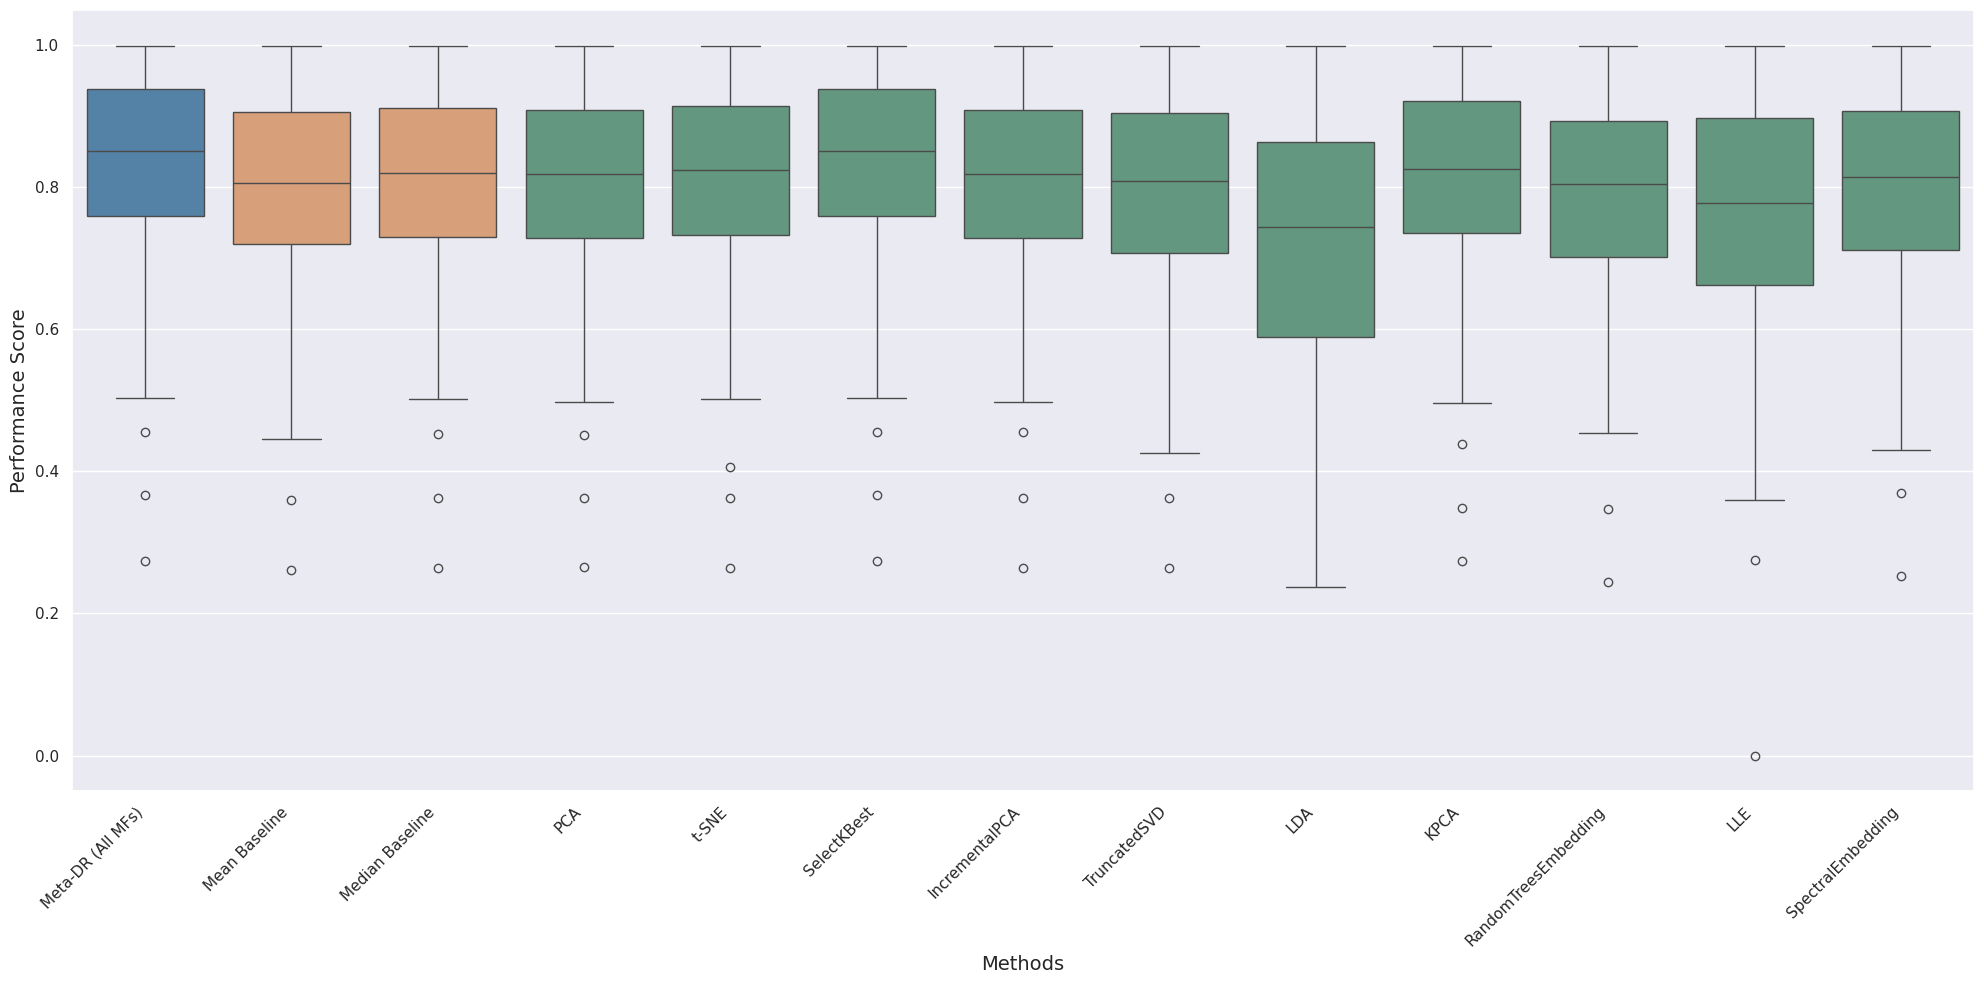

In [138]:
# Prepare data for the boxplot
columns_to_plot = [
    'Unified Proposal',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

df_plot = final_results_table[columns_to_plot].copy()

# Rename proposal columns for display
renamed_columns = {
    'Unified Proposal': 'Meta-DR (All MFs)',
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline',
}

df_plot.rename(columns=renamed_columns, inplace=True)

# Convert from wide to long format
df_long = df_plot.melt(var_name='Method', value_name='Performance')

# Define plotting order and colors
plot_order = [
    'Meta-DR (All MFs)',
    'Mean Baseline', 'Median Baseline',
    'PCA', 't-SNE', 'SelectKBest', 'IncrementalPCA', 'TruncatedSVD',
    'LDA', 'KPCA', 'RandomTreesEmbedding', 'LLE', 'SpectralEmbedding'
]

custom_colors = [
    'steelblue',   # Meta-DR proposals
    '#E79B6C', '#E79B6C',                                 # Baselines
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F' # Individual DR methods
]

# Create boxplot
sns.set_style("darkgrid")
plt.figure(figsize=(20, 10))

sns.boxplot(
    data=df_long,
    x='Method',
    y='Performance',
    order=plot_order,
    palette=custom_colors
)

plt.ylabel('Performance Score', fontsize=14)
plt.xlabel('Methods', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

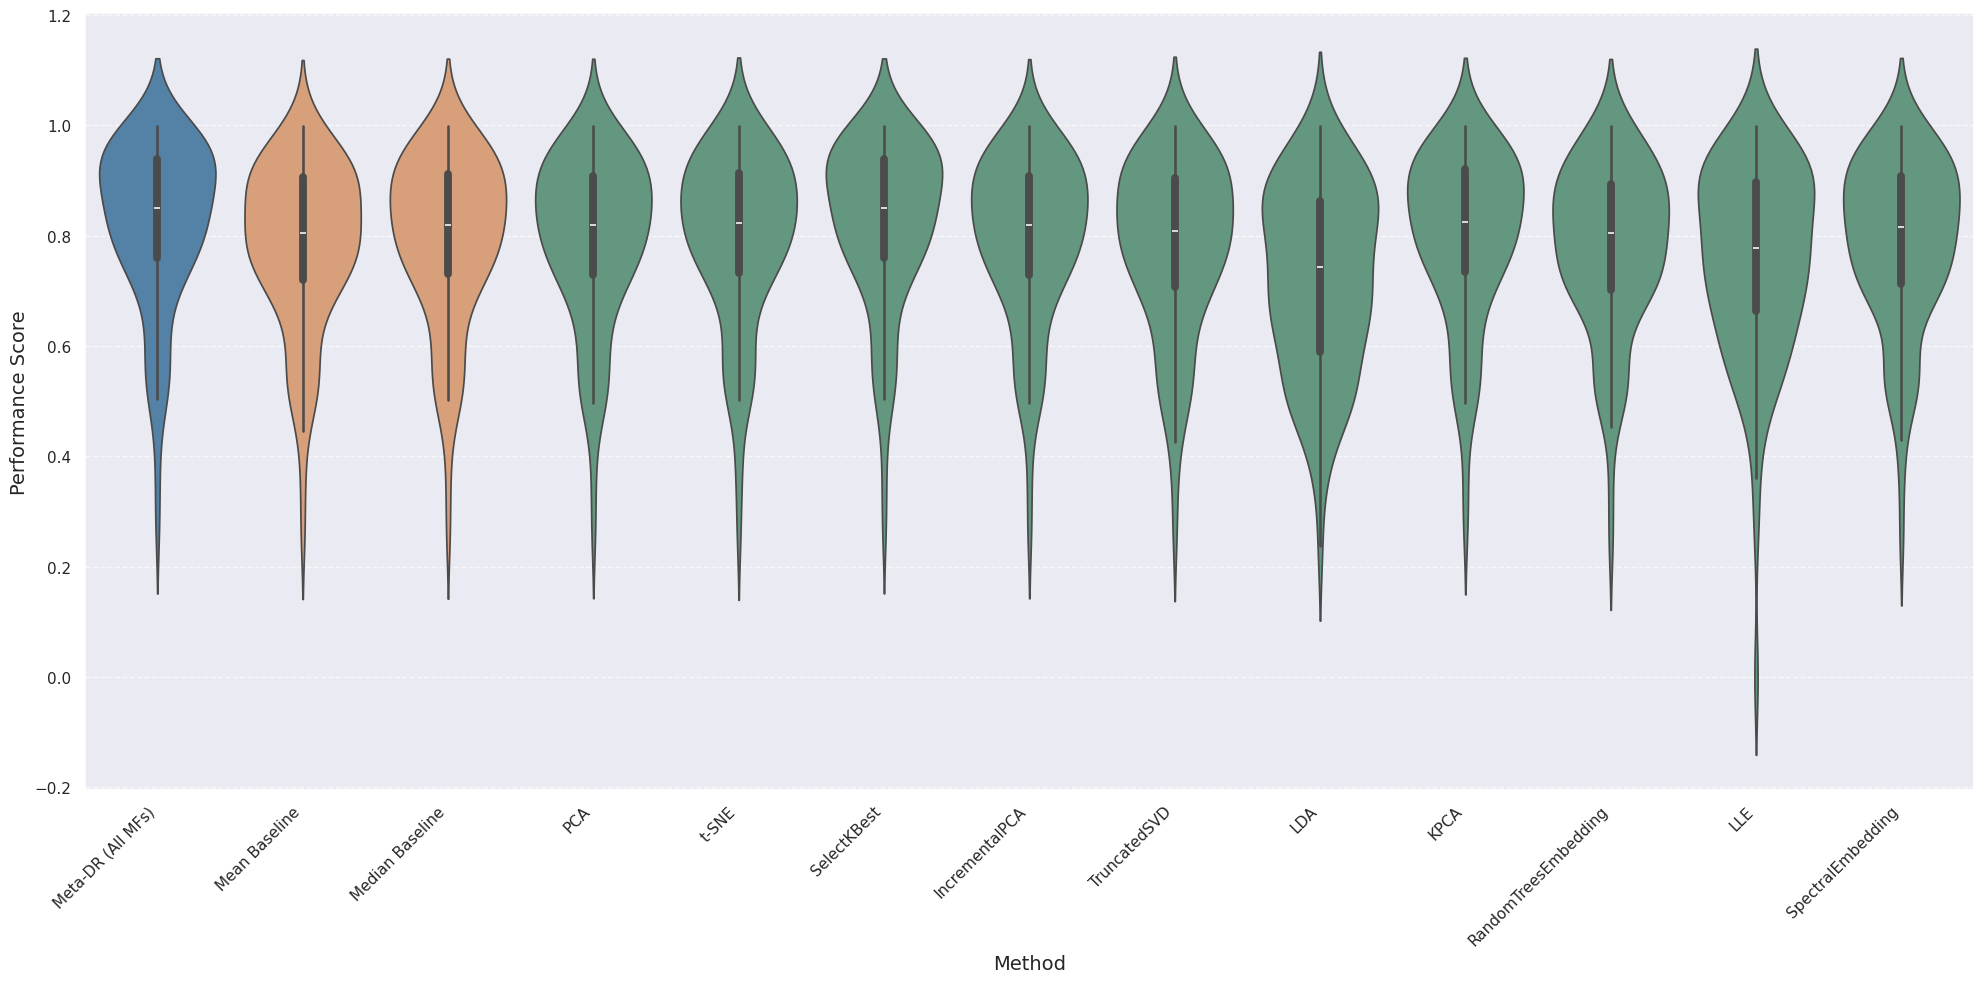

In [139]:
# Prepare data for the violin plot
original_columns = [
    'Unified Proposal',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

df_plot = final_results_table[original_columns].copy()

renamed_columns = {
    'Unified Proposal': 'Meta-DR (All MFs)',
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline',
}

df_plot.rename(columns=renamed_columns, inplace=True)

# Convert from wide to long format
df_long = df_plot.melt(var_name='Method', value_name='Performance')

# Define plot order and custom colors
plot_order = [
    'Meta-DR (All MFs)',
    'Mean Baseline', 'Median Baseline',
    'PCA', 't-SNE', 'SelectKBest', 'IncrementalPCA', 'TruncatedSVD',
    'LDA', 'KPCA', 'RandomTreesEmbedding', 'LLE', 'SpectralEmbedding'
]

custom_colors = [
    'steelblue',   # Meta-DR proposals
    '#E79B6C', '#E79B6C',                                 # Baselines
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F' # Individual DR methods
]

# Create violin plot
sns.set_style("darkgrid")
plt.figure(figsize=(20, 10))

sns.violinplot(
    data=df_long,
    x='Method',
    y='Performance',
    order=plot_order,
    palette=custom_colors,
    inner='box'
)

plt.ylabel('Performance Score', fontsize=14)
plt.xlabel('Method', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- 95% Confidence Intervals, Means, and Margin of Error ---
                       Mean  CI Lower (95%)  CI Upper (95%)  Margin of Error
Unified Proposal     0.8197          0.7886          0.8508           0.0311
Mean Baseline        0.7805          0.7500          0.8110           0.0305
Median Baseline      0.7911          0.7600          0.8222           0.0311
PCA                  0.7908          0.7598          0.8219           0.0310
IncrementalPCA       0.7912          0.7603          0.8221           0.0309
RandomTreesEmbedding 0.7768          0.7457          0.8079           0.0311
SelectKBest          0.8199          0.7889          0.8509           0.0310
SpectralEmbedding    0.7845          0.7531          0.8159           0.0314
TruncatedSVD         0.7776          0.7456          0.8096           0.0320
LDA                  0.7200          0.6856          0.7543           0.0344
LLE                  0.7535          0.7177          0.7893           0.0358
KPCA          

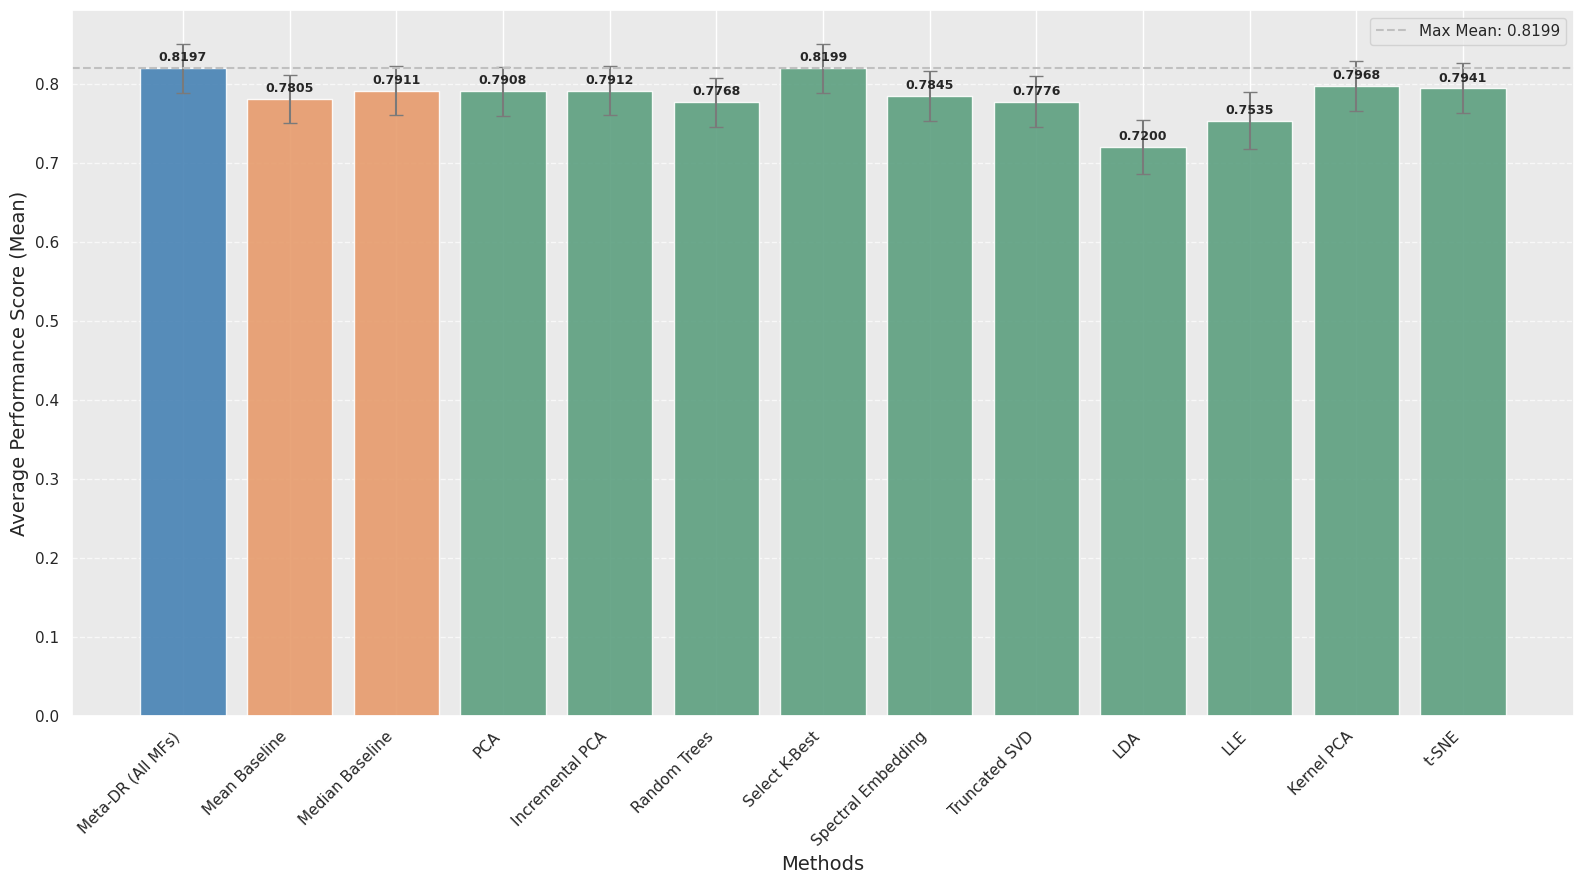

In [140]:
# Select methods to compare
columns_to_plot = [
        'Unified Proposal',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

df_to_plot = final_results_table[columns_to_plot].copy()

# Compute 95% confidence intervals
confidence_level = 0.95
alpha = 1 - confidence_level
n = df_to_plot.shape[0]

means = df_to_plot.mean()
std_devs = df_to_plot.std(ddof=1)

try:
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
except ValueError:
    print(
        f"Warning: could not compute the t-critical value because the sample size is too small (n={n})."
    )
    t_critical = 1.96

# Standard error of the mean
standard_error = std_devs / np.sqrt(n)

# Margin of error for the confidence interval
margin_of_error = t_critical * standard_error

ci_lower = means - margin_of_error
ci_upper = means + margin_of_error

ci_df = pd.DataFrame({
    'Mean': means,
    'CI Lower (95%)': ci_lower,
    'CI Upper (95%)': ci_upper,
    'Margin of Error': margin_of_error
}).reindex(columns_to_plot)

print("\n--- 95% Confidence Intervals, Means, and Margin of Error ---")
print(ci_df.to_string(float_format="{:.4f}".format))
print("------------------------------------------\n")

# Custom colors
custom_colors = [
    'steelblue',   # Meta-DR proposals
    '#E79B6C', '#E79B6C',                                 # Baselines
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F'                                  # Individual DR methods
]

# Rename labels for plotting
rename_labels = {
    'Unified Proposal': 'Meta-DR (All MFs)',
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline',
    'PCA': 'PCA',
    'IncrementalPCA': 'Incremental PCA',
    'RandomTreesEmbedding': 'Random Trees',
    'SelectKBest': 'Select K-Best',
    'SpectralEmbedding': 'Spectral Embedding',
    'TruncatedSVD': 'Truncated SVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel PCA',
    't-SNE': 't-SNE'
}

# Create bar plot with confidence intervals
sns.set_style("darkgrid")
sns.set(rc={'axes.facecolor': '#EAEAEA'})
plt.figure(figsize=(16, 9))

bars = plt.bar(
    means.index,
    means.values,
    yerr=margin_of_error.values,
    capsize=5,
    color=custom_colors,
    ecolor='#7A7A7A',
    alpha=0.9
)

# Reference line for the highest mean
max_value = means.values.max()
plt.axhline(
    y=max_value,
    color='silver',
    linestyle='--',
    linewidth=1.5,
    label=f"Max Mean: {max_value:.4f}"
)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.xticks(
    ticks=np.arange(len(means.index)),
    labels=[rename_labels.get(label, label) for label in means.index],
    rotation=45,
    ha="right"
)

plt.ylabel('Average Performance Score (Mean)', fontsize=14)
plt.xlabel('Methods', fontsize=14)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Few-Shot Performance Analysis of Meta-DR Proposals


TABLE: Average Performance by N-Shot and Proposal
        Unified
N-shot         
1        0.8197
2        0.8210
3        0.8214
4        0.8218
5        0.8220
6        0.8221
7        0.8221
8        0.8227
9        0.8245
10       0.8245



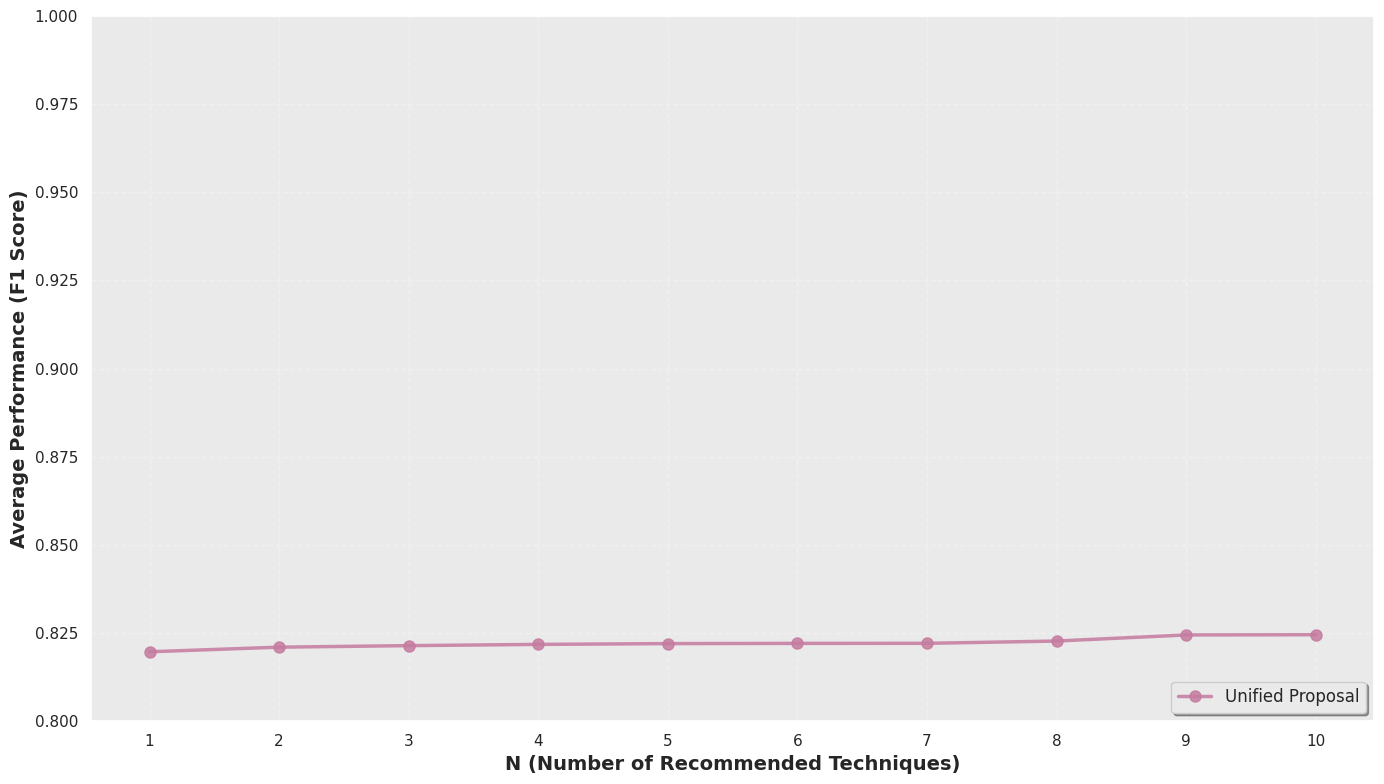

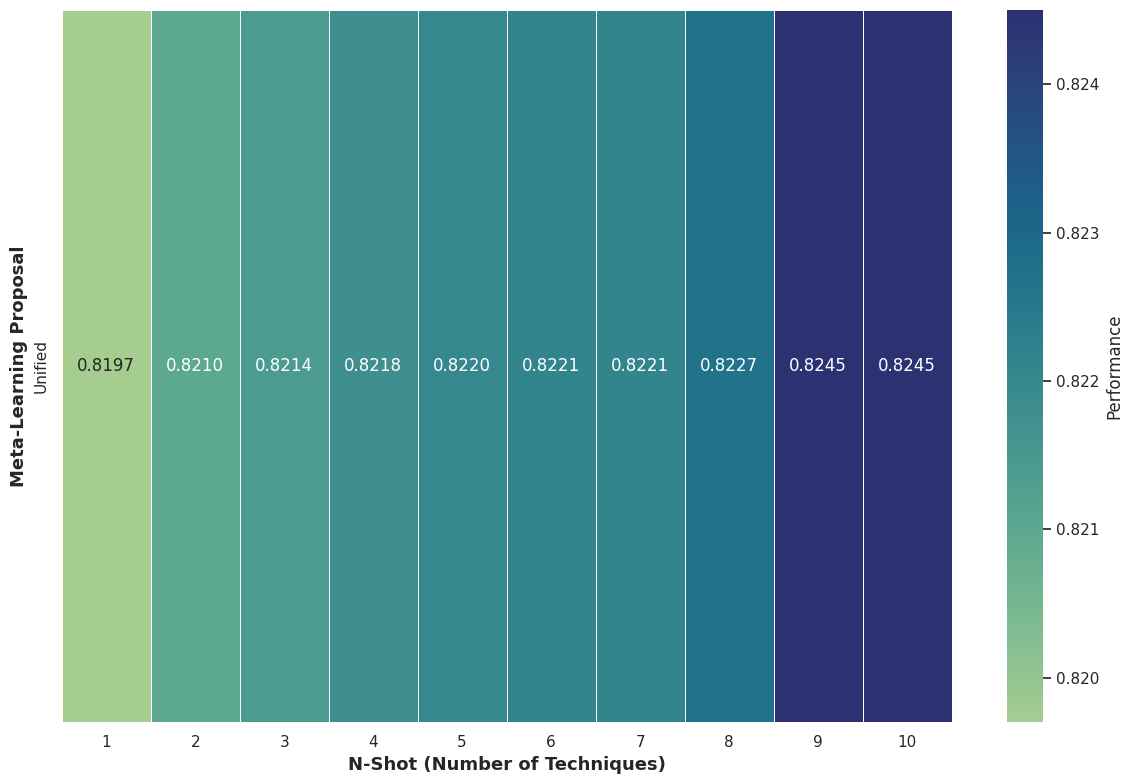

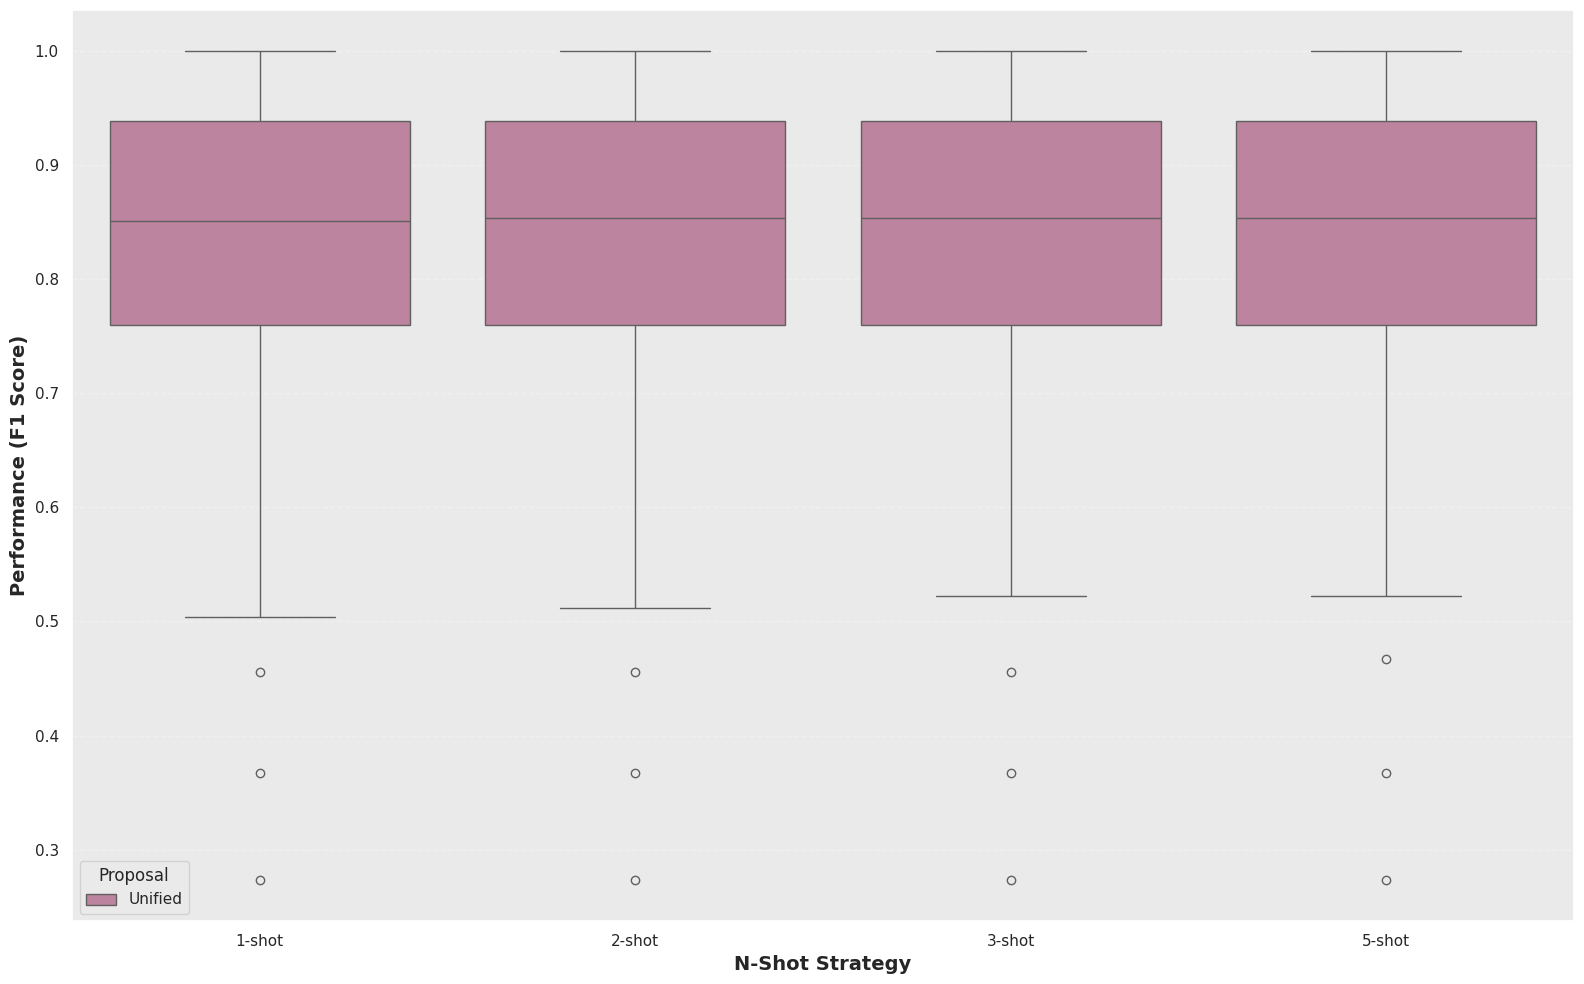


ANALYSIS: Few-Shot Performance Gain over 1-Shot

Unified Proposal:
  1-shot: 0.8197
  2-shot: 0.8210 (gain: +0.16%)
  3-shot: 0.8214 (gain: +0.21%)
  5-shot: 0.8220 (gain: +0.28%)



EXPANDED TABLE: Performance with N-Shot Analysis
   Unified Proposal  Mean Baseline  Median Baseline       PCA  IncrementalPCA  \
0          0.367000       0.360400         0.363000  0.363000        0.363000   
1          0.535112       0.523565         0.518014  0.518077        0.535202   
2          0.871655       0.859389         0.856317  0.847226        0.847226   
3          0.874972       0.848616         0.846215  0.824294        0.824294   
4          0.760000       0.721300         0.729000  0.729000        0.729000   
5          0.760000       0.721300         0.729000  0.729000        0.729000   
6          0.624000       0.547217         0.545500  0.545500        0.545500   
7          0.783500       0.749533         0.749250  0.749000        0.749000   
8          0.905098       0.888588    

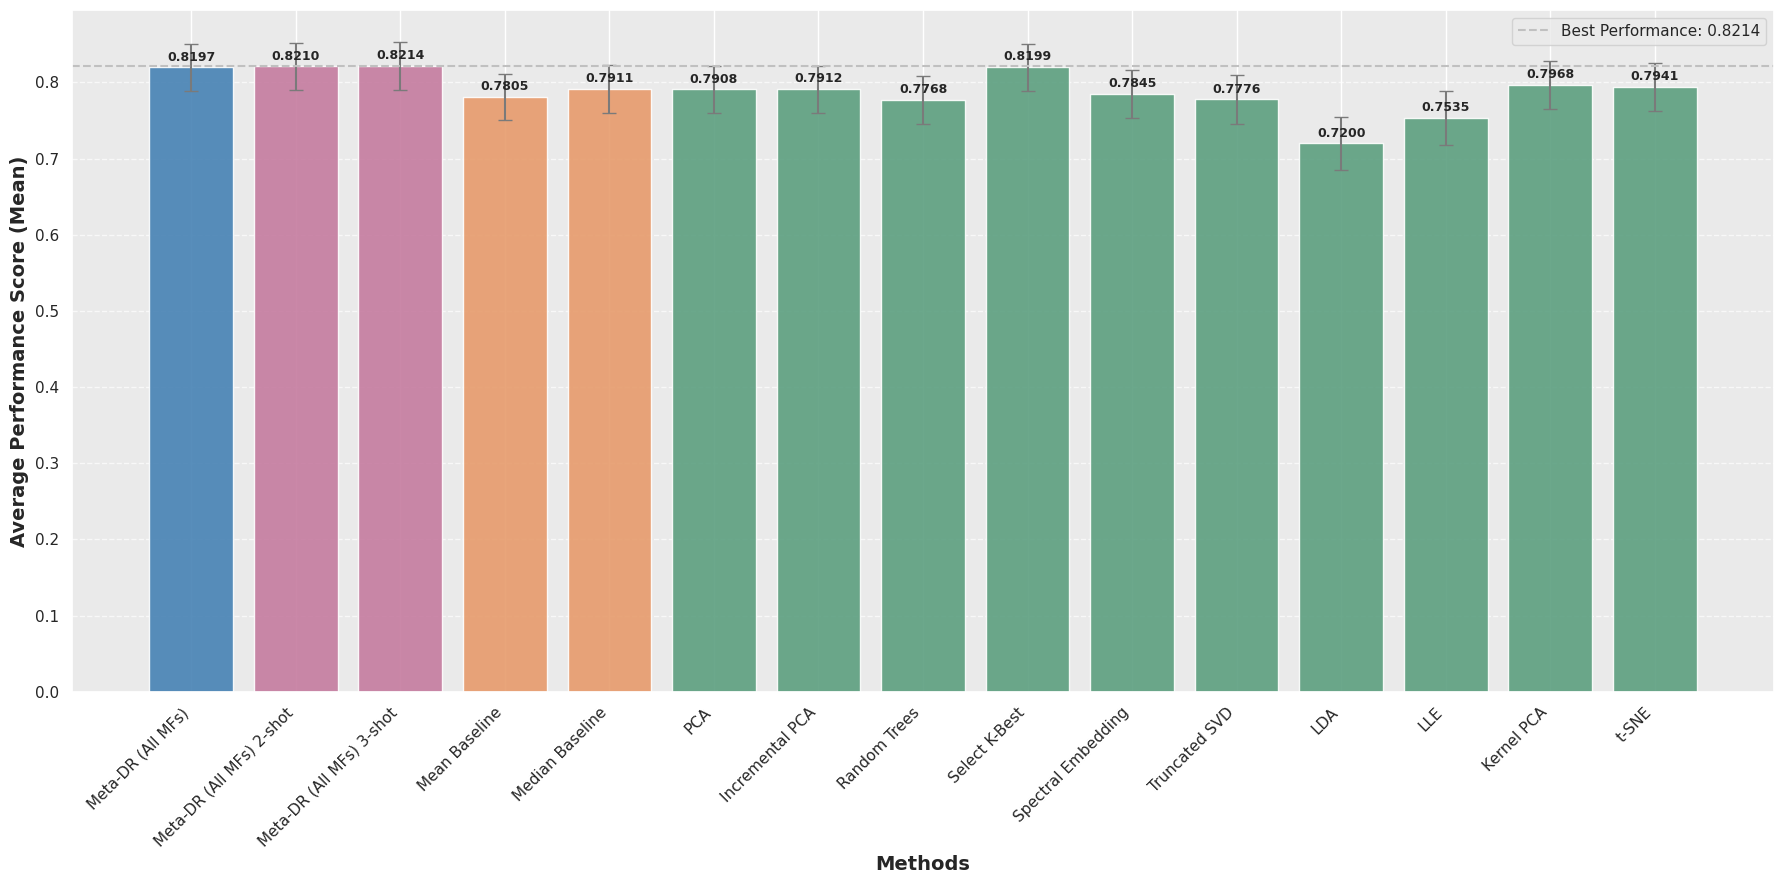

In [141]:
# Helper functions
def calculate_nshot_performance(df_real_performance, df_predicted_ranking, n_shot):
    """
    Compute the best real performance among the top-N recommended techniques.

    Parameters
    ----------
    df_real_performance : pd.DataFrame
        True performance scores of all DR techniques.
    df_predicted_ranking : pd.DataFrame
            Predicted rankings for all DR techniques.
    n_shot : int
        Number of top-ranked techniques to consider.

    Returns
    -------
    np.ndarray
        Best true performance among the top-N recommended techniques for each dataset.
    """
    nshot_performance = []

    for row_idx in range(len(df_real_performance)):
        predicted_ranks = df_predicted_ranking.iloc[row_idx]

        # Select the top-N techniques with the best predicted ranks
        top_n_techniques = predicted_ranks.nsmallest(n_shot).index.tolist()

        # Get the true performances of the selected techniques
        selected_performances = df_real_performance.iloc[row_idx][top_n_techniques]

        # Keep the best true performance among the selected techniques
        best_performance = selected_performances.max()
        nshot_performance.append(best_performance)

    return np.array(nshot_performance)


def load_predicted_rankings(filepath, columns):
    """
    Load predicted rankings from CSV.
    The file already contains ranking values, so no extra ranking step is required.
    """
    df_predicted = pd.read_csv(filepath)
    df_predicted.columns = columns
    return df_predicted


# Load predicted rankings for each proposal
proposal_files = {
    "Unified": "data/predictions/predictions_ranking.csv",
}

predicted_rankings = {}
for proposal_name, filepath in proposal_files.items():
    predicted_rankings[proposal_name] = load_predicted_rankings(
        filepath,
        df_DR_technique_result.columns
    )

# Compute N-shot performance from 1-shot to 10-shot
n_values = range(1, 11)

nshot_results = {}
for proposal_name, df_rank in predicted_rankings.items():
    nshot_results[proposal_name] = {}
    for n in n_values:
        nshot_results[proposal_name][n] = calculate_nshot_performance(
            df_DR_technique_result,
            df_rank,
            n
        )

# Mean performance for each proposal and N-shot setting
nshot_means = {}
for proposal_name in predicted_rankings.keys():
    nshot_means[proposal_name] = {
        n: nshot_results[proposal_name][n].mean()
        for n in n_values
    }

# Convert to DataFrame
df_nshot_comparison = pd.DataFrame(nshot_means)
df_nshot_comparison.index.name = "N-shot"
df_nshot_comparison = df_nshot_comparison.round(4)

print("\n" + "=" * 80)
print("TABLE: Average Performance by N-Shot and Proposal")
print("=" * 80)
print(df_nshot_comparison)
print("=" * 80 + "\n")

# Line plot: average performance by N-shot
plt.figure(figsize=(14, 8))

proposal_colors = {
    "General": "steelblue",
    "Statistical": "#E79B6C",
    "Info-Theory": "#5C9F7F",
    "Unified": "#C57B9F"
}
proposal_markers = ["o", "s", "^", "D"]

for proposal_name, marker in zip(predicted_rankings.keys(), proposal_markers):
    mean_values = [nshot_means[proposal_name][n] for n in n_values]
    plt.plot(
        n_values,
        mean_values,
        marker=marker,
        color=proposal_colors[proposal_name],
        linewidth=2.5,
        markersize=8,
        label=f"{proposal_name} Proposal",
        alpha=0.85
    )

plt.xlabel("N (Number of Recommended Techniques)", fontsize=14, fontweight="bold")
plt.ylabel("Average Performance (F1 Score)", fontsize=14, fontweight="bold")
plt.xticks(list(n_values))
plt.ylim(0.80, 1.0)
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(fontsize=12, loc="lower right", frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# Heatmap: N-shot performance comparison
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_nshot_comparison.T,
    annot=True,
    fmt=".4f",
    cmap=sns.color_palette("crest", as_cmap=True),
    cbar_kws={"label": "Performance"},
    linewidths=0.5
)
plt.xlabel("N-Shot (Number of Techniques)", fontsize=13, fontweight="bold")
plt.ylabel("Meta-Learning Proposal", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Boxplot: selected N-shot strategies
selected_n_values = [1, 2, 3, 5]
comparison_rows = []

for proposal_name in predicted_rankings.keys():
    for n in selected_n_values:
        for performance in nshot_results[proposal_name][n]:
            comparison_rows.append({
                "Proposal": proposal_name,
                "N-Shot": f"{n}-shot",
                "Performance": performance
            })

df_nshot_distribution = pd.DataFrame(comparison_rows)

plt.figure(figsize=(16, 10))
palette = [proposal_colors[name] for name in predicted_rankings.keys()]

sns.boxplot(
    data=df_nshot_distribution,
    x="N-Shot",
    y="Performance",
    hue="Proposal",
    palette=palette
)

plt.ylabel("Performance (F1 Score)", fontsize=14, fontweight="bold")
plt.xlabel("N-Shot Strategy", fontsize=14, fontweight="bold")
plt.legend(title="Proposal", fontsize=11, title_fontsize=12)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# Print few-shot gains relative to 1-shot
print("\n" + "=" * 80)
print("ANALYSIS: Few-Shot Performance Gain over 1-Shot")
print("=" * 80)

for proposal_name in predicted_rankings.keys():
    one_shot = nshot_results[proposal_name][1].mean()
    two_shot = nshot_results[proposal_name][2].mean()
    three_shot = nshot_results[proposal_name][3].mean()
    five_shot = nshot_results[proposal_name][5].mean()

    gain_2 = ((two_shot - one_shot) / one_shot) * 100
    gain_3 = ((three_shot - one_shot) / one_shot) * 100
    gain_5 = ((five_shot - one_shot) / one_shot) * 100

    print(f"\n{proposal_name} Proposal:")
    print(f"  1-shot: {one_shot:.4f}")
    print(f"  2-shot: {two_shot:.4f} (gain: +{gain_2:.2f}%)")
    print(f"  3-shot: {three_shot:.4f} (gain: +{gain_3:.2f}%)")
    print(f"  5-shot: {five_shot:.4f} (gain: +{gain_5:.2f}%)")

print("\n" + "=" * 80 + "\n")

# Expand final results table with 2-shot and 3-shot columns
final_results_table_nshot = final_results_table.copy()

for proposal_name, df_rank in predicted_rankings.items():
    final_results_table_nshot[f"{proposal_name} 2-shot"] = calculate_nshot_performance(
        df_DR_technique_result,
        df_rank,
        2
    )
    final_results_table_nshot[f"{proposal_name} 3-shot"] = calculate_nshot_performance(
        df_DR_technique_result,
        df_rank,
        3
    )

print("\n" + "=" * 80)
print("EXPANDED TABLE: Performance with N-Shot Analysis")
print("=" * 80)
print(final_results_table_nshot.head(10))
print("\nAverages:")
print(final_results_table_nshot.mean(numeric_only=True).round(4))
print("=" * 80 + "\n")

# Compare proposals against the best individual algorithm
selectkbest_mean = df_DR_technique_result["SelectKBest"].mean()

print("\n" + "=" * 80)
print("COMPARISON: N-Shot Proposals vs. Best Individual Algorithm (SelectKBest)")
print("=" * 80)
print(f"\nSelectKBest (always use): {selectkbest_mean:.4f}\n")

for proposal_name in predicted_rankings.keys():
    for n in [1, 2, 3]:
        mean_performance = nshot_results[proposal_name][n].mean()
        difference = mean_performance - selectkbest_mean
        symbol = "✓" if difference > 0 else "✗"
        print(f"{symbol} {proposal_name} {n}-shot: {mean_performance:.4f} (difference: {difference:+.4f})")

print("=" * 80 + "\n")

# Bar plot with confidence intervals including few-shot variants
columns_to_plot_nshot = [
    "Unified Proposal",
    "Unified 2-shot",
    "Unified 3-shot",
    "Mean Baseline",
    "Median Baseline",
    "PCA",
    "IncrementalPCA",
    "RandomTreesEmbedding",
    "SelectKBest",
    "SpectralEmbedding",
    "TruncatedSVD",
    "LDA",
    "LLE",
    "KPCA",
    "t-SNE"
]

df_plot_nshot = final_results_table_nshot[columns_to_plot_nshot].copy()

confidence_level = 0.95
alpha = 1 - confidence_level
sample_size = df_plot_nshot.shape[0]

means_nshot = df_plot_nshot.mean()
std_devs_nshot = df_plot_nshot.std(ddof=1)

try:
    t_critical = stats.t.ppf(1 - alpha / 2, df=sample_size - 1)
except ValueError:
    t_critical = 1.96

standard_error_nshot = std_devs_nshot / np.sqrt(sample_size)
margin_of_error_nshot = t_critical * standard_error_nshot

ci_lower_nshot = means_nshot - margin_of_error_nshot
ci_upper_nshot = means_nshot + margin_of_error_nshot

ci_df_nshot = pd.DataFrame({
    "Mean": means_nshot,
    "CI Lower (95%)": ci_lower_nshot,
    "CI Upper (95%)": ci_upper_nshot,
    "Margin of Error": margin_of_error_nshot
}).reindex(columns_to_plot_nshot)

print("\n--- 95% Confidence Intervals, Means, and Margin of Error (N-Shot Included) ---")
print(ci_df_nshot.to_string(float_format="{:.4f}".format))
print("------------------------------------------\n")

custom_colors_nshot = [
    "steelblue",
    "#C57B9F", "#C57B9F",
    "#E79B6C", "#E79B6C",
    "#5C9F7F", "#5C9F7F", "#5C9F7F", "#5C9F7F",
    "#5C9F7F", "#5C9F7F", "#5C9F7F", "#5C9F7F",
    "#5C9F7F", "#5C9F7F"
]

rename_labels_nshot = {
    "Unified Proposal": "Meta-DR (All MFs)",
    "Unified 2-shot": "Meta-DR (All MFs) 2-shot",
    "Unified 3-shot": "Meta-DR (All MFs) 3-shot",
    "Mean Baseline": "Mean Baseline",
    "Median Baseline": "Median Baseline",
    "PCA": "PCA",
    "IncrementalPCA": "Incremental PCA",
    "RandomTreesEmbedding": "Random Trees",
    "SelectKBest": "Select K-Best",
    "SpectralEmbedding": "Spectral Embedding",
    "TruncatedSVD": "Truncated SVD",
    "LDA": "LDA",
    "LLE": "LLE",
    "KPCA": "Kernel PCA",
    "t-SNE": "t-SNE"
}

sns.set_style("darkgrid")
sns.set(rc={"axes.facecolor": "#EAEAEA"})
plt.figure(figsize=(18, 9))

bars = plt.bar(
    means_nshot.index,
    means_nshot.values,
    yerr=margin_of_error_nshot.values,
    capsize=5,
    color=custom_colors_nshot,
    ecolor="#7A7A7A",
    alpha=0.9
)

best_mean_value = means_nshot.values.max()
plt.axhline(
    y=best_mean_value,
    color="silver",
    linestyle="--",
    linewidth=1.5,
    label=f"Best Performance: {best_mean_value:.4f}"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.xticks(
    ticks=np.arange(len(means_nshot.index)),
    labels=[rename_labels_nshot.get(label, label) for label in means_nshot.index],
    rotation=45,
    ha="right"
)

plt.ylabel("Average Performance Score (Mean)", fontsize=14, fontweight="bold")
plt.xlabel("Methods", fontsize=14, fontweight="bold")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Statistical Hypothesis Testing


--- 95% Confidence Intervals, Means, and Margin of Error ---
                       Mean  CI Lower (95%)  CI Upper (95%)  Margin of Error
Unified Proposal     0.8197          0.7886          0.8508           0.0311
Unified 2-shot       0.8210          0.7900          0.8520           0.0310
Unified 3-shot       0.8214          0.7905          0.8524           0.0310
Mean Baseline        0.7805          0.7500          0.8110           0.0305
Median Baseline      0.7911          0.7600          0.8222           0.0311
PCA                  0.7908          0.7598          0.8219           0.0310
IncrementalPCA       0.7912          0.7603          0.8221           0.0309
RandomTreesEmbedding 0.7768          0.7457          0.8079           0.0311
SelectKBest          0.8199          0.7889          0.8509           0.0310
SpectralEmbedding    0.7845          0.7531          0.8159           0.0314
TruncatedSVD         0.7776          0.7456          0.8096           0.0320
LDA           

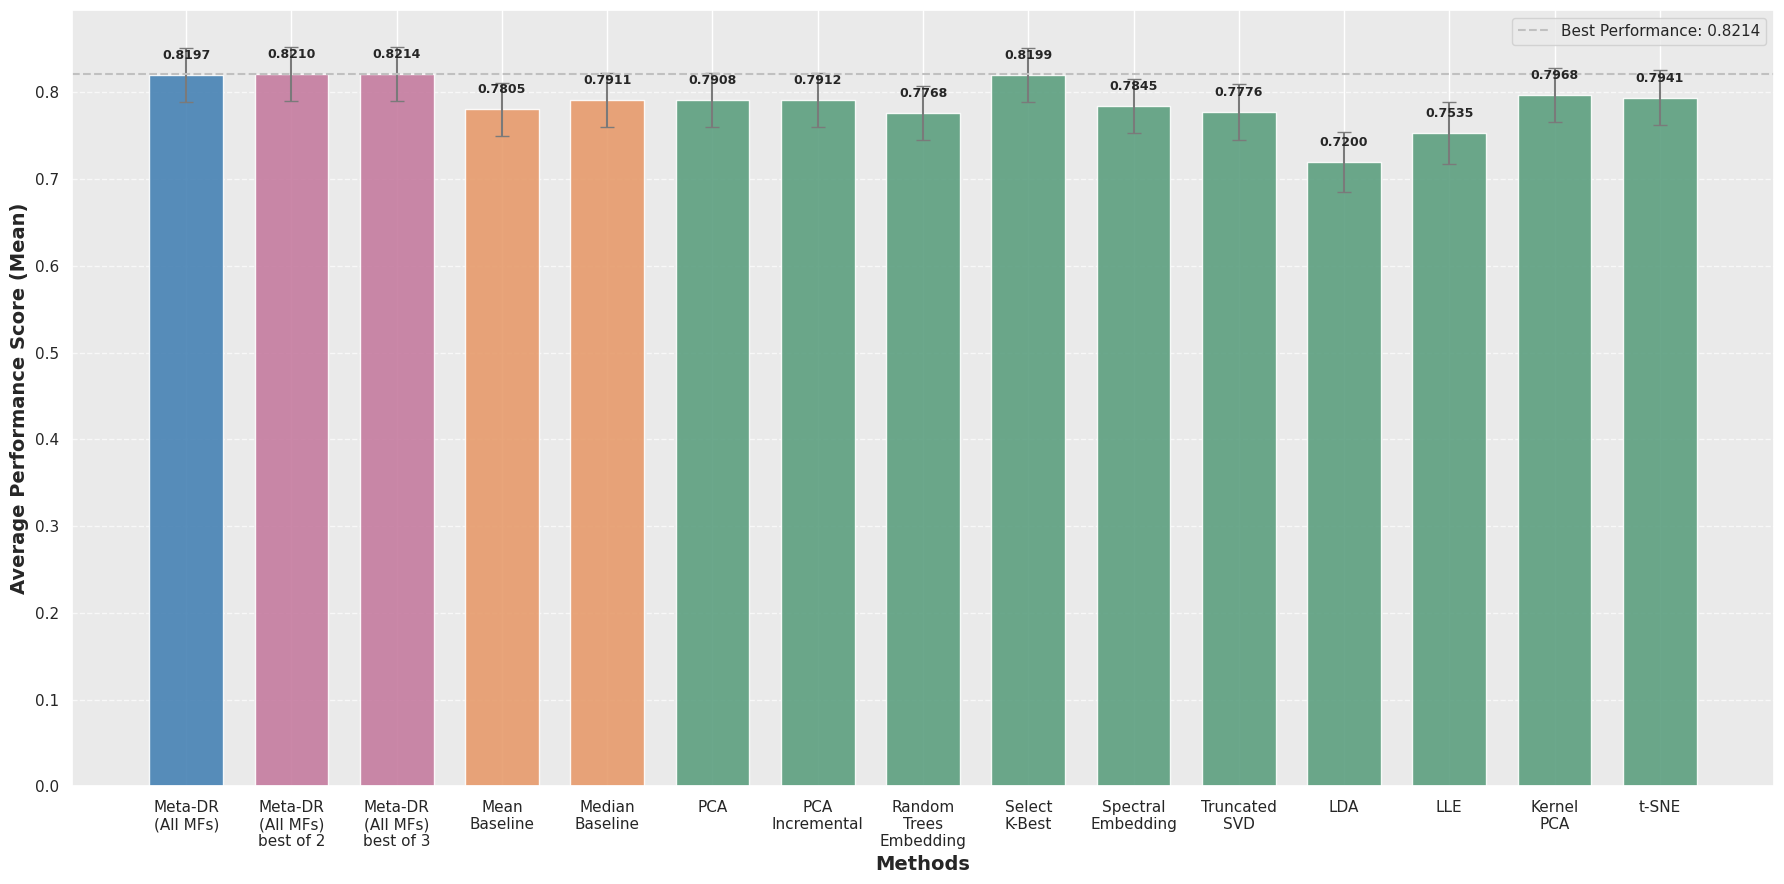

In [150]:
from scipy import stats

# Columns (methods) that will be included in the analysis and visualization
columns_to_plot_nshot = [
    'Unified Proposal',
    'Unified 2-shot', 'Unified 3-shot',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

# Use the results table that includes the few-shot methods
df_to_plot = final_results_table_nshot[columns_to_plot_nshot]

# Confidence level for the interval estimation
confidence_level = 0.95
alpha = 1 - confidence_level
n = df_to_plot.shape[0]

# Compute mean and standard deviation of each method
means = df_to_plot.mean()
std_devs = df_to_plot.std(ddof=1)

# Degrees of freedom = n - 1
# Compute the critical t value for the confidence interval
try:
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
except ValueError:
    print(f"Error: Unable to compute the critical t value. Sample size (n={n}) is too small.")
    t_critical = 1.96

# Standard Error of the Mean (SEM)
sem = std_devs / np.sqrt(n)

# Margin of error used in the plot
margin_of_error = t_critical * sem

# Lower and upper bounds of the confidence interval
ci_lower = means - margin_of_error
ci_upper = means + margin_of_error

# DataFrame summarizing the statistical estimates
ci_df = pd.DataFrame({
    'Mean': means,
    'CI Lower (95%)': ci_lower,
    'CI Upper (95%)': ci_upper,
    'Margin of Error': margin_of_error
}).reindex(columns_to_plot_nshot)

print("\n--- 95% Confidence Intervals, Means, and Margin of Error ---")
print(ci_df.to_string(float_format="{:.4f}".format))
print("------------------------------------------\n")


# HYPOTHESIS TESTING

print("="*80)
print("HYPOTHESIS TESTS: Comparing MDR (1-shot, 2-shot, 3-shot) vs Baselines and Best Individual Method")
print("="*80)

print("\nNull Hypothesis (H0): There is no significant difference between methods")
print("Alternative Hypothesis (H1): There is a significant difference between methods\n")

# MDR-based methods (Meta-DR proposals)
mdr_methods = {
    'Unified Proposal': 'MDR (All MFs)',
    'Unified 2-shot': 'MDR (All MFs) best of 2',
    'Unified 3-shot': 'MDR (All MFs) best of 3'
}

# Baseline methods
baselines = {
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline'
}

# Best individual dimensionality reduction method
best_individual = 'SelectKBest'

comparisons = []

# 1. Compare each MDR method against baselines
for mdr_col, mdr_name in mdr_methods.items():
    for baseline_col, baseline_name in baselines.items():
        comparisons.append((
            mdr_name,
            baseline_name,
            df_to_plot[mdr_col],
            df_to_plot[baseline_col]
        ))

# 2. Compare each MDR method against SelectKBest
for mdr_col, mdr_name in mdr_methods.items():
    comparisons.append((
        mdr_name,
        'Select K-Best',
        df_to_plot[mdr_col],
        df_to_plot[best_individual]
    ))

# 3. Evaluate the benefit of few-shot (2-shot and 3-shot)
comparisons.append((
    'MDR (All MFs) best of 2',
    'MDR (All MFs)',
    df_to_plot['Unified 2-shot'],
    df_to_plot['Unified Proposal']
))

comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs)',
    df_to_plot['Unified 3-shot'],
    df_to_plot['Unified Proposal']
))

# 4. Compare 3-shot vs 2-shot
comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs) best of 2',
    df_to_plot['Unified 3-shot'],
    df_to_plot['Unified 2-shot']
))

results_summary = []

# Statistical comparison loop
for method1_name, method2_name, data1, data2 in comparisons:

    print(f"\n{'='*80}")
    print(f"Comparison: {method1_name} vs {method2_name}")
    print(f"{'='*80}")

    # Remove NaN values if present
    mask = ~(np.isnan(data1) | np.isnan(data2))
    data1_clean = data1[mask].values
    data2_clean = data2[mask].values

    # Compute pairwise differences
    differences = data1_clean - data2_clean

    print(f"\nSample size: {len(data1_clean)}")
    print(f"Mean {method1_name}: {np.mean(data1_clean):.4f}")
    print(f"Mean {method2_name}: {np.mean(data2_clean):.4f}")
    print(f"Mean difference: {np.mean(differences):.4f}")


    # Normality test (D’Agostino–Pearson)

    print(f"\n--- Normality Test (D'Agostino-Pearson) ---")
    stat_norm, p_norm = stats.normaltest(differences)

    print(f"Statistic: {stat_norm:.4f}")
    print(f"p-value: {p_norm:.4f}")

    is_normal = p_norm > 0.05

    if is_normal:
        print("✓ Distribution is normal (p > 0.05) → Using paired t-test")
    else:
        print("✗ Distribution is NOT normal (p ≤ 0.05) → Using Wilcoxon test")


    # Hypothesis test selection

    print(f"\n--- Hypothesis Test ---")

    if is_normal:
        stat, p_value = stats.ttest_rel(data1_clean, data2_clean)
        test_name = "Paired t-test"
    else:
        stat, p_value = stats.wilcoxon(data1_clean, data2_clean, alternative='two-sided')
        test_name = "Wilcoxon Signed-Rank Test"

    print(f"Test used: {test_name}")
    print(f"Statistic: {stat:.4f}")
    print(f"p-value: {p_value:.4f}")


    # Statistical interpretation

    alpha_test = 0.05

    if p_value < alpha_test:

        significance = "✓ SIGNIFICANT"
        interpretation = f"Reject H0: Significant difference detected (p < {alpha_test})"

        if np.mean(differences) > 0:
            winner = method1_name
            better = f"{method1_name} performs better"
        else:
            winner = method2_name
            better = f"{method2_name} performs better"

        print(f"\n{significance}")
        print(interpretation)
        print(f"Best method: {winner}")
        print(f"Interpretation: {better}")

    else:

        significance = "✗ NOT SIGNIFICANT"
        interpretation = f"Fail to reject H0: No significant difference (p ≥ {alpha_test})"

        print(f"\n{significance}")
        print(interpretation)

        winner = "Tie"
        better = "No significant difference"

    # Store results
    results_summary.append({
        'Method 1': method1_name,
        'Method 2': method2_name,
        'Normal?': 'Yes' if is_normal else 'No',
        'Test': test_name,
        'Statistic': f"{stat:.4f}",
        'p-value': f"{p_value:.4f}",
        'Significant?': 'Yes' if p_value < alpha_test else 'No',
        'Winner': winner,
        'Mean difference': f"{np.mean(differences):.4f}",
        'Interpretation': better
    })

# Summary of hypothesis tests
print("\n" + "="*80)
print("SUMMARY OF HYPOTHESIS TESTS")
print("="*80)

results_df = pd.DataFrame(results_summary)
print("\n" + results_df.to_string(index=False))

print("\n" + "="*80)


# Visualization

# Custom colors for method categories
custom_colors_nshot = [
'steelblue',
    '#C57B9F', '#C57B9F',
    '#E79B6C', '#E79B6C',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F'
]

# Plot styling
sns.set_style("darkgrid")
sns.set(rc={'axes.facecolor': '#EAEAEA'})

plt.figure(figsize=(18, 9))

rename_labels_nshot = {
    'Unified Proposal': 'Meta-DR\n(All MFs)',
    'Unified 2-shot': 'Meta-DR\n(All MFs)\nbest of 2',
    'Unified 3-shot': 'Meta-DR\n(All MFs)\nbest of 3',
    'Mean Baseline': 'Mean\nBaseline',
    'Median Baseline': 'Median\nBaseline',
    'PCA': 'PCA',
    'IncrementalPCA': 'PCA\nIncremental',
    'RandomTreesEmbedding': 'Random\nTrees\nEmbedding',
    'SelectKBest': 'Select\nK-Best',
    'SpectralEmbedding': 'Spectral\nEmbedding',
    'TruncatedSVD': 'Truncated\nSVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel\nPCA',
    't-SNE': 't-SNE'
}

# Renomeia os índices
means.index = means.index.map(lambda x: rename_labels_nshot.get(x, x))
margin_of_error.index = margin_of_error.index.map(lambda x: rename_labels_nshot.get(x, x))

# Bar chart with confidence intervals
bars = plt.bar(
    means.index,
    means.values,
    width=0.7,
    yerr=margin_of_error.values,
    capsize=5,
    color=custom_colors_nshot,
    ecolor='#7A7A7A',
    alpha=0.9
)

# Reference line showing the best performance
max_value = means.values.max()
plt.axhline(
    y=max_value,
    color='silver',
    linestyle='--',
    linewidth=1.5,
    label=f"Best Performance: {max_value:.4f}"
)

# Add value labels on top of bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.015,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Axis labels
plt.ylabel('Average Performance Score (Mean)', fontsize=14, fontweight='bold')
plt.xlabel('Methods', fontsize=14, fontweight='bold')

plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Save figure
plt.savefig(
    "Average-PerformanceBarIC_3_short.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

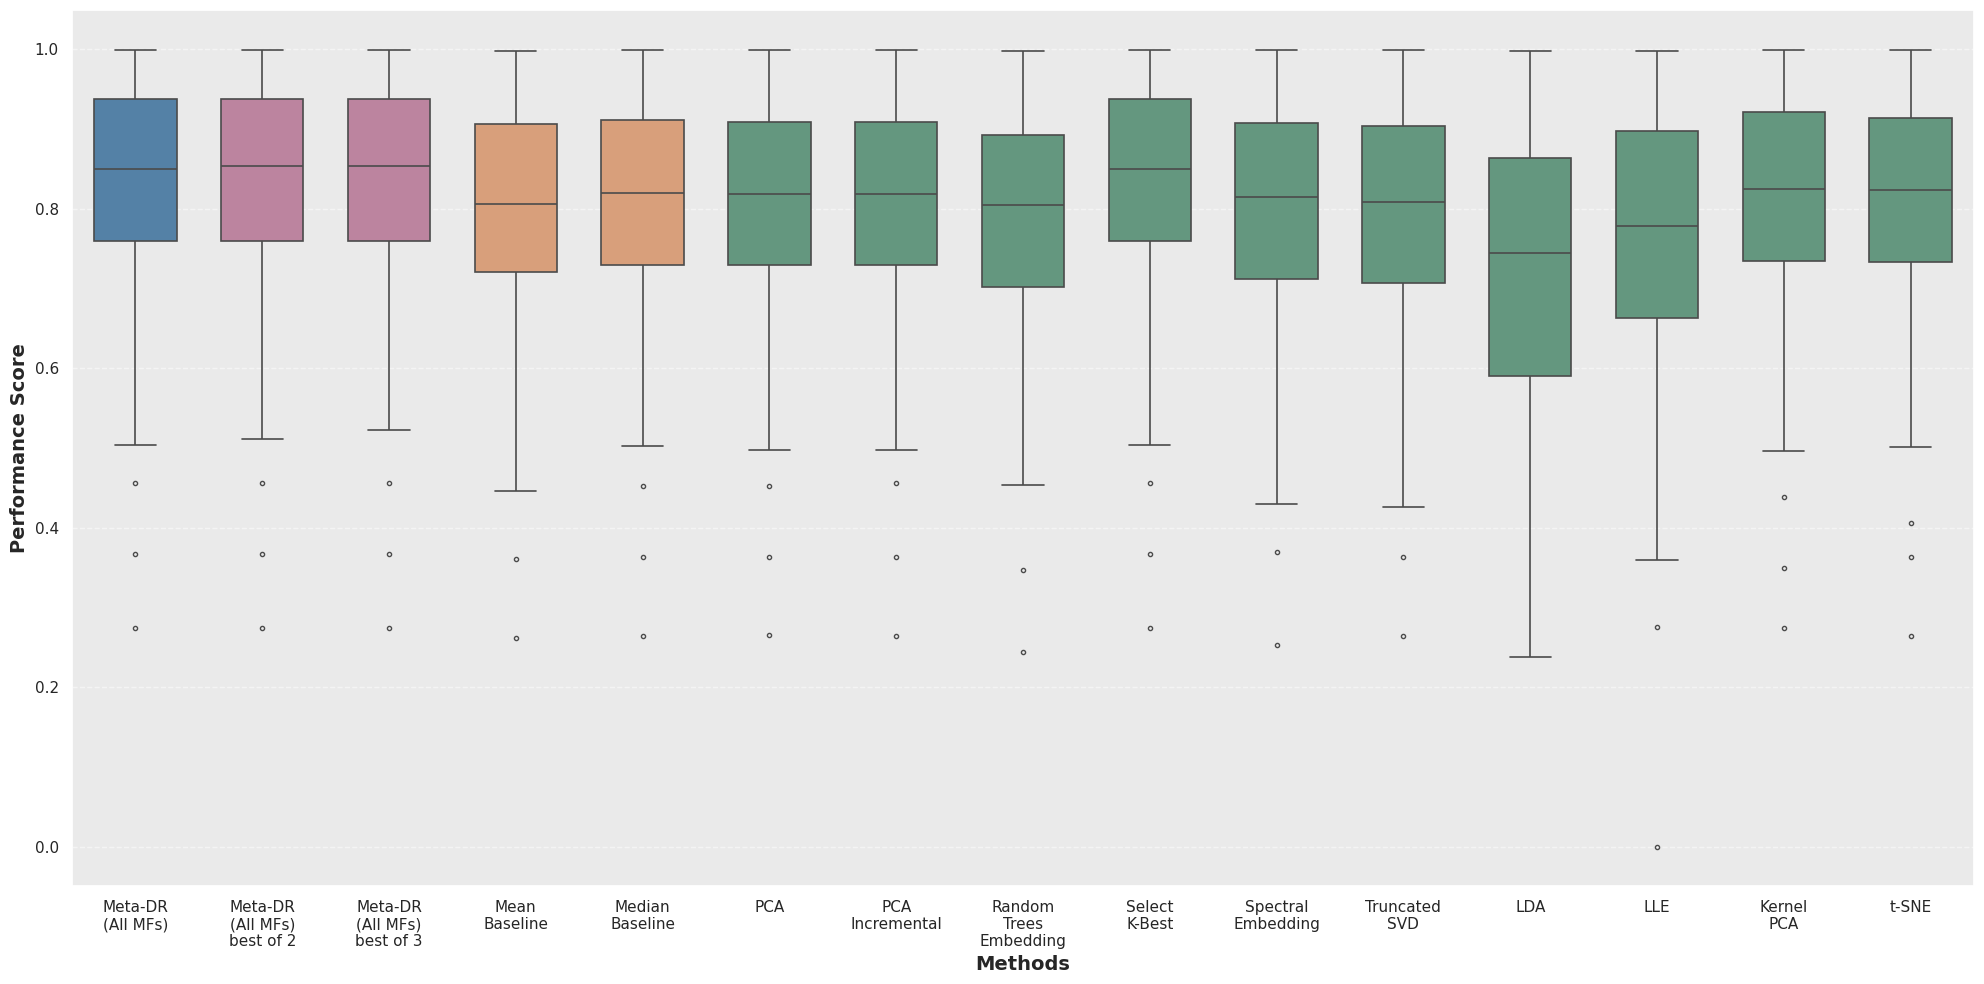

In [151]:

# Columns to be plotted
columns_to_plot = [
    'Unified Proposal',
    'Unified 2-shot', 'Unified 3-shot',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

# Select only the columns of interest
df_to_plot = final_results_table_nshot[columns_to_plot].copy()

# Rename labels for better visualization
rename_labels_nshot = {
    'Unified Proposal': 'Meta-DR\n(All MFs)',
    'Unified 2-shot': 'Meta-DR\n(All MFs)\nbest of 2',
    'Unified 3-shot': 'Meta-DR\n(All MFs)\nbest of 3',
    'Mean Baseline': 'Mean\nBaseline',
    'Median Baseline': 'Median\nBaseline',
    'PCA': 'PCA',
    'IncrementalPCA': 'PCA\nIncremental',
    'RandomTreesEmbedding': 'Random\nTrees\nEmbedding',
    'SelectKBest': 'Select\nK-Best',
    'SpectralEmbedding': 'Spectral\nEmbedding',
    'TruncatedSVD': 'Truncated\nSVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel\nPCA',
    't-SNE': 't-SNE'
}

df_plot_renamed = df_to_plot.rename(columns=rename_labels_nshot)

# Custom colors
custom_colors_nshot = [
    'steelblue',
    '#C57B9F', '#C57B9F',
    '#E79B6C', '#E79B6C',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F', '#5C9F7F', '#5C9F7F',
    '#5C9F7F', '#5C9F7F'
]

# Plot style
sns.set_style("darkgrid")
sns.set(rc={'axes.facecolor': '#EAEAEA'})

plt.figure(figsize=(20, 10))

ax = sns.boxplot(
    data=df_plot_renamed,
    palette=custom_colors_nshot,
    width=0.65,
    linewidth=1.2,
    fliersize=3
)

# Axis formatting
plt.xticks(rotation=0, fontsize=11, ha="center")
plt.yticks(fontsize=11)
plt.ylabel("Performance Score", fontsize=14, fontweight='bold')
plt.xlabel("Methods", fontsize=14, fontweight='bold')

# Grid only on y-axis
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', visible=False)

# Improve spacing
plt.tight_layout()

# Save figure
plt.savefig(
    "Average_Performance_Boxplot.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [152]:
import pandas as pd
import numpy as np
from scipy import stats
from tabulate import tabulate


# Configuration
columns_to_analyze = [
   'Unified Proposal',
    'Unified 2-shot', 'Unified 3-shot',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

mdr_methods = {
    'Unified Proposal': 'MDR (All MFs)',
    'Unified 2-shot': 'MDR (All MFs) best of 2',
    'Unified 3-shot': 'MDR (All MFs) best of 3'
}

baselines = {
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline'
}

individual_methods = {
    'PCA': 'PCA',
    'IncrementalPCA': 'PCA Incremental',
    'RandomTreesEmbedding': 'Random Trees',
    'SelectKBest': 'Select K-Best',
    'SpectralEmbedding': 'Spectral Embedding',
    'TruncatedSVD': 'Truncated SVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel PCA',
    't-SNE': 't-SNE'
}


# Helper function
def print_table(df, title, floatfmt=".4f", showindex=True):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(tabulate(df, headers="keys", tablefmt="grid", floatfmt=floatfmt, showindex=showindex))
    print()


# Data selection
df_to_analyze = final_results_table_nshot[columns_to_analyze].copy()


# Confidence intervals
confidence_level = 0.95
alpha = 1 - confidence_level
n = df_to_analyze.shape[0]

means = df_to_analyze.mean()
std_devs = df_to_analyze.std(ddof=1)
sem = std_devs / np.sqrt(n)

try:
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
except ValueError:
    print(f"Warning: could not compute t-critical value because sample size is too small (n={n}). Using 1.96.")
    t_critical = 1.96

margin_of_error = t_critical * sem
ci_lower = means - margin_of_error
ci_upper = means + margin_of_error

ci_df = pd.DataFrame({
    'Mean': means,
    'CI Lower (95%)': ci_lower,
    'CI Upper (95%)': ci_upper,
    'Margin of Error': margin_of_error
}).reindex(columns_to_analyze)

print_table(ci_df, "95% Confidence Intervals")


# Build comparisons
comparisons = []

# Compare each MDR variant against baselines
for mdr_col, mdr_name in mdr_methods.items():
    for baseline_col, baseline_name in baselines.items():
        comparisons.append((
            mdr_name,
            baseline_name,
            df_to_analyze[mdr_col],
            df_to_analyze[baseline_col]
        ))

# Compare each MDR variant against SelectKBest
for mdr_col, mdr_name in mdr_methods.items():
    comparisons.append((
        mdr_name,
        'Select K-Best',
        df_to_analyze[mdr_col],
        df_to_analyze['SelectKBest']
    ))

# Compare unified 1-shot against each individual method
for ind_col, ind_name in individual_methods.items():
    comparisons.append((
        'MDR (All MFs)',
        ind_name,
        df_to_analyze['Unified Proposal'],
        df_to_analyze[ind_col]
    ))

# Compare unified best of 2 against each individual method
for ind_col, ind_name in individual_methods.items():
    comparisons.append((
        'MDR (All MFs) best of 2',
        ind_name,
        df_to_analyze['Unified 2-shot'],
        df_to_analyze[ind_col]
    ))

# Compare unified best of 3 against each individual method
for ind_col, ind_name in individual_methods.items():
    comparisons.append((
        'MDR (All MFs) best of 3',
        ind_name,
        df_to_analyze['Unified 3-shot'],
        df_to_analyze[ind_col]
    ))

# Compare few-shot settings
comparisons.append((
    'MDR (All MFs) best of 2',
    'MDR (All MFs)',
    df_to_analyze['Unified 2-shot'],
    df_to_analyze['Unified Proposal']
))

comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs)',
    df_to_analyze['Unified 3-shot'],
    df_to_analyze['Unified Proposal']
))

comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs) best of 2',
    df_to_analyze['Unified 3-shot'],
    df_to_analyze['Unified 2-shot']
))


# Hypothesis tests
results_summary = []
alpha_test = 0.05

for method1_name, method2_name, data1, data2 in comparisons:
    mask = ~(np.isnan(data1) | np.isnan(data2))
    data1_clean = data1[mask].values
    data2_clean = data2[mask].values
    differences = data1_clean - data2_clean

    # Skip invalid comparisons
    if len(differences) < 8:
        results_summary.append({
            'Method 1': method1_name,
            'Method 2': method2_name,
            'Test': 'Insufficient sample',
            'p-value': np.nan,
            'Significant?': 'No',
            'Winner': 'Undefined',
            'Mean Difference': np.mean(differences) if len(differences) > 0 else np.nan
        })
        continue

    # Check normality of paired differences
    stat_norm, p_norm = stats.normaltest(differences)
    is_normal = p_norm > 0.05

    if is_normal:
        stat, p_value = stats.ttest_rel(data1_clean, data2_clean)
        test_name = 'Paired t-test'
    else:
        try:
            stat, p_value = stats.wilcoxon(data1_clean, data2_clean, alternative='two-sided')
            test_name = 'Wilcoxon signed-rank'
        except ValueError:
            stat, p_value = np.nan, 1.0
            test_name = 'Wilcoxon signed-rank'

    mean_diff = np.mean(differences)

    if p_value < alpha_test:
        winner = method1_name if mean_diff > 0 else method2_name
        significant = 'Yes'
    else:
        winner = 'Tie'
        significant = 'No'

    results_summary.append({
        'Method 1': method1_name,
        'Method 2': method2_name,
        'Test': test_name,
        'p-value': p_value,
        'Significant?': significant,
        'Winner': winner,
        'Mean Difference': mean_diff
    })

results_df = pd.DataFrame(results_summary)
print_table(results_df, "Hypothesis Test Summary", showindex=False)


# Essential summaries
vs_selectkbest_df = results_df[results_df['Method 2'] == 'Select K-Best'].copy()
print_table(vs_selectkbest_df, "MDR vs SelectKBest", showindex=False)

fewshot_df = results_df[
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 2') &
        (results_df['Method 2'] == 'MDR (All MFs)')
    ) |
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 3') &
        (results_df['Method 2'] == 'MDR (All MFs)')
    ) |
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 3') &
        (results_df['Method 2'] == 'MDR (All MFs) best of 2')
    )
].copy()

print_table(fewshot_df, "Few-Shot Comparison Summary", showindex=False)


95% Confidence Intervals
+----------------------+--------+------------------+------------------+-------------------+
|                      |   Mean |   CI Lower (95%) |   CI Upper (95%) |   Margin of Error |
+======================+========+==================+==================+===================+
| Unified Proposal     | 0.8197 |           0.7886 |           0.8508 |            0.0311 |
+----------------------+--------+------------------+------------------+-------------------+
| Unified 2-shot       | 0.8210 |           0.7900 |           0.8520 |            0.0310 |
+----------------------+--------+------------------+------------------+-------------------+
| Unified 3-shot       | 0.8214 |           0.7905 |           0.8524 |            0.0310 |
+----------------------+--------+------------------+------------------+-------------------+
| Mean Baseline        | 0.7805 |           0.7500 |           0.8110 |            0.0305 |
+----------------------+--------+------------------+--

In [153]:
import pandas as pd
import numpy as np
from scipy import stats
from tabulate import tabulate


# Configuration
columns_to_analyze = [
    'Unified Proposal',
    'Unified 2-shot', 'Unified 3-shot',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

mdr_methods = {
    'Unified Proposal': 'MDR (All MFs)',
    'Unified 2-shot': 'MDR (All MFs) best of 2',
    'Unified 3-shot': 'MDR (All MFs) best of 3'
}

baselines = {
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline'
}

individual_methods_cols = [
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

individual_methods_names = {
    'PCA': 'PCA',
    'IncrementalPCA': 'PCA Incremental',
    'RandomTreesEmbedding': 'Random Trees',
    'SelectKBest': 'Select K-Best',
    'SpectralEmbedding': 'Spectral Embedding',
    'TruncatedSVD': 'Truncated SVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel PCA',
    't-SNE': 't-SNE'
}

best_individual_col = 'SelectKBest'


# Helper function
def print_table(df, title, floatfmt=".4f", showindex=False):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(tabulate(df, headers="keys", tablefmt="grid", floatfmt=floatfmt, showindex=showindex))
    print()


# Data selection
df_to_analyze = final_results_table_nshot[columns_to_analyze].copy()


# Confidence intervals
confidence_level = 0.95
alpha = 1 - confidence_level
n = df_to_analyze.shape[0]

means = df_to_analyze.mean()
std_devs = df_to_analyze.std(ddof=1)
sem = std_devs / np.sqrt(n)

try:
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
except ValueError:
    print(f"Warning: could not compute the t-critical value because the sample size is too small (n={n}). Using 1.96.")
    t_critical = 1.96

margin_of_error = t_critical * sem
ci_lower = means - margin_of_error
ci_upper = means + margin_of_error

ci_df = pd.DataFrame({
    'Method': columns_to_analyze,
    'Mean': [means[col] for col in columns_to_analyze],
    'CI Lower (95%)': [ci_lower[col] for col in columns_to_analyze],
    'CI Upper (95%)': [ci_upper[col] for col in columns_to_analyze],
    'Margin of Error': [margin_of_error[col] for col in columns_to_analyze]
})

print_table(ci_df, "95% Confidence Intervals")


# Build comparisons
comparisons = []

# 1. Compare each MDR variant against baselines
for mdr_col, mdr_name in mdr_methods.items():
    for baseline_col, baseline_name in baselines.items():
        comparisons.append((
            mdr_name,
            baseline_name,
            df_to_analyze[mdr_col],
            df_to_analyze[baseline_col]
        ))

# 2. Compare each MDR variant against SelectKBest
for mdr_col, mdr_name in mdr_methods.items():
    comparisons.append((
        mdr_name,
        'Select K-Best',
        df_to_analyze[mdr_col],
        df_to_analyze[best_individual_col]
    ))

# 3. Compare unified MDR variants against each individual method
unified_mdr_comps = [
    ('Unified Proposal', 'MDR (All MFs)'),
    ('Unified 2-shot', 'MDR (All MFs) best of 2'),
    ('Unified 3-shot', 'MDR (All MFs) best of 3')
]

for unified_col, unified_name in unified_mdr_comps:
    for ind_col in individual_methods_cols:
        comparisons.append((
            unified_name,
            individual_methods_names[ind_col],
            df_to_analyze[unified_col],
            df_to_analyze[ind_col]
        ))

# 4. Compare few-shot settings
comparisons.append((
    'MDR (All MFs) best of 2',
    'MDR (All MFs)',
    df_to_analyze['Unified 2-shot'],
    df_to_analyze['Unified Proposal']
))

comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs)',
    df_to_analyze['Unified 3-shot'],
    df_to_analyze['Unified Proposal']
))

comparisons.append((
    'MDR (All MFs) best of 3',
    'MDR (All MFs) best of 2',
    df_to_analyze['Unified 3-shot'],
    df_to_analyze['Unified 2-shot']
))


# Wilcoxon hypothesis tests
results_summary = []
alpha_test = 0.05

for method1_name, method2_name, data1, data2 in comparisons:
    mask = ~(np.isnan(data1) | np.isnan(data2))
    data1_clean = data1[mask].values
    data2_clean = data2[mask].values
    differences = data1_clean - data2_clean

    sample_size = len(data1_clean)
    mean_1 = np.mean(data1_clean) if sample_size > 0 else np.nan
    mean_2 = np.mean(data2_clean) if sample_size > 0 else np.nan
    mean_diff = np.mean(differences) if sample_size > 0 else np.nan

    # Normality is reported only as complementary information
    if sample_size >= 8:
        try:
            _, p_norm = stats.normaltest(differences)
            normality = 'Yes' if p_norm > 0.05 else 'No'
        except Exception:
            normality = 'Undefined'
    else:
        normality = 'Undefined'

    # Wilcoxon signed-rank test
    try:
        stat, p_value = stats.wilcoxon(
            data1_clean,
            data2_clean,
            alternative='two-sided',
            zero_method='wilcox'
        )
        test_name = 'Wilcoxon signed-rank'
    except ValueError:
        stat, p_value = np.nan, np.nan
        test_name = 'Wilcoxon signed-rank'

    if pd.notna(p_value) and p_value < alpha_test:
        winner = method1_name if mean_diff > 0 else method2_name
        significant = 'Yes'
    elif pd.notna(p_value):
        winner = 'Tie'
        significant = 'No'
    else:
        winner = 'Undefined'
        significant = 'Undefined'

    results_summary.append({
        'Method 1': method1_name,
        'Method 2': method2_name,
        'N': sample_size,
        'Mean 1': mean_1,
        'Mean 2': mean_2,
        'Mean Difference': mean_diff,
        'Normal?': normality,
        'Test': test_name,
        'W Statistic': stat,
        'p-value': p_value,
        'Significant?': significant,
        'Winner': winner
    })

results_df = pd.DataFrame(results_summary)

print_table(results_df, "Wilcoxon Hypothesis Test Summary")


# Essential summary 1: MDR vs SelectKBest
vs_selectkbest_df = results_df[results_df['Method 2'] == 'Select K-Best'].copy()
print_table(vs_selectkbest_df, "MDR vs SelectKBest")


# Essential summary 2: Few-shot comparisons
fewshot_df = results_df[
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 2') &
        (results_df['Method 2'] == 'MDR (All MFs)')
    ) |
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 3') &
        (results_df['Method 2'] == 'MDR (All MFs)')
    ) |
    (
        (results_df['Method 1'] == 'MDR (All MFs) best of 3') &
        (results_df['Method 2'] == 'MDR (All MFs) best of 2')
    )
].copy()

print_table(fewshot_df, "Few-Shot Comparison Summary")


95% Confidence Intervals
+----------------------+--------+------------------+------------------+-------------------+
| Method               |   Mean |   CI Lower (95%) |   CI Upper (95%) |   Margin of Error |
+======================+========+==================+==================+===================+
| Unified Proposal     | 0.8197 |           0.7886 |           0.8508 |            0.0311 |
+----------------------+--------+------------------+------------------+-------------------+
| Unified 2-shot       | 0.8210 |           0.7900 |           0.8520 |            0.0310 |
+----------------------+--------+------------------+------------------+-------------------+
| Unified 3-shot       | 0.8214 |           0.7905 |           0.8524 |            0.0310 |
+----------------------+--------+------------------+------------------+-------------------+
| Mean Baseline        | 0.7805 |           0.7500 |           0.8110 |            0.0305 |
+----------------------+--------+------------------+--

In [154]:
import pandas as pd
from tabulate import tabulate


# =========================================================
# Build a compact results table for the paper
# =========================================================
if 'results_summary' in globals() and len(results_summary) > 0:
    results_table = pd.DataFrame(results_summary)

    # Map display names back to original dataframe column names
    name_to_column = {
        'MDR (All MFs)': 'Unified Proposal',
        'MDR (All MFs) best of 2': 'Unified 2-shot',
        'MDR (All MFs) best of 3': 'Unified 3-shot',
        'Mean Baseline': 'Mean Baseline',
        'Median Baseline': 'Median Baseline',
        'PCA': 'PCA',
        'PCA Incremental': 'IncrementalPCA',
        'Random Trees': 'RandomTreesEmbedding',
        'Select K-Best': 'SelectKBest',
        'Spectral Embedding': 'SpectralEmbedding',
        'Truncated SVD': 'TruncatedSVD',
        'LDA': 'LDA',
        'LLE': 'LLE',
        'Kernel PCA': 'KPCA',
        't-SNE': 't-SNE'
    }

    # Adjust these names depending on the language used in results_summary
    method1_col = 'Method 1' if 'Method 1' in results_table.columns else 'Método 1'
    method2_col = 'Method 2' if 'Method 2' in results_table.columns else 'Método 2'
    mean_diff_col = 'Mean Difference' if 'Mean Difference' in results_table.columns else 'Diferença média'
    pvalue_col = 'p-value' if 'p-value' in results_table.columns else 'p-valor'

    mean1_list = []
    mean2_list = []

    for _, row in results_table.iterrows():
        method1 = row[method1_col]
        method2 = row[method2_col]

        col1 = name_to_column.get(method1, method1)
        col2 = name_to_column.get(method2, method2)

        if col1 in df_to_plot.columns and col2 in df_to_plot.columns:
            mean1_list.append(df_to_plot[col1].mean())
            mean2_list.append(df_to_plot[col2].mean())
        else:
            mean1_list.append(None)
            mean2_list.append(None)

    results_table['Mean Method 1'] = mean1_list
    results_table['Mean Method 2'] = mean2_list

    # Keep only the essential columns for the paper
    compact_table = results_table[[
        method1_col,
        method2_col,
        'Mean Method 1',
        'Mean Method 2',
        mean_diff_col,
        pvalue_col
    ]].copy()

    # Rename columns to a clean final format
    compact_table.columns = [
        'Method 1',
        'Method 2',
        'Mean Method 1',
        'Mean Method 2',
        'Mean Difference',
        'p-value'
    ]

    compact_table = compact_table.sort_values(['Method 1', 'Method 2']).reset_index(drop=True)

    print("\n" + "=" * 120)
    print("COMPACT TABLE WITH HYPOTHESIS TEST RESULTS")
    print("=" * 120)
    print(
        tabulate(
            compact_table,
            headers='keys',
            tablefmt='grid',
            floatfmt=".4f",
            showindex=False
        )
    )
    print("=" * 120 + "\n")

else:
    print("Error: the variable 'results_summary' was not found or is empty.")


COMPACT TABLE WITH HYPOTHESIS TEST RESULTS
+-------------------------+-------------------------+-----------------+-----------------+-------------------+-----------+
| Method 1                | Method 2                |   Mean Method 1 |   Mean Method 2 |   Mean Difference |   p-value |
+=========================+=========================+=================+=================+===================+===========+
| MDR (All MFs)           | Kernel PCA              |          0.8197 |          0.7968 |            0.0229 |    0.0000 |
+-------------------------+-------------------------+-----------------+-----------------+-------------------+-----------+
| MDR (All MFs)           | LDA                     |          0.8197 |          0.7200 |            0.0997 |    0.0000 |
+-------------------------+-------------------------+-----------------+-----------------+-------------------+-----------+
| MDR (All MFs)           | LLE                     |          0.8197 |          0.7535 |            0

In [155]:
# Build a single table with all hypothesis test results
if 'results_summary' in globals() and len(results_summary) > 0:
    results_table = pd.DataFrame(results_summary).copy()

    # Map display names back to the original dataframe column names
    name_to_column = {
        'MDR (All MFs)': 'Unified Proposal',
        'MDR (All MFs) best of 2': 'Unified 2-shot',
        'MDR (All MFs) best of 3': 'Unified 3-shot',
        'Mean Baseline': 'Mean Baseline',
        'Median Baseline': 'Median Baseline',
        'PCA': 'PCA',
        'PCA Incremental': 'IncrementalPCA',
        'Random Trees': 'RandomTreesEmbedding',
        'Select K-Best': 'SelectKBest',
        'Spectral Embedding': 'SpectralEmbedding',
        'Truncated SVD': 'TruncatedSVD',
        'LDA': 'LDA',
        'LLE': 'LLE',
        'Kernel PCA': 'KPCA',
        't-SNE': 't-SNE'
    }

    # Detect column names automatically
    method1_col = 'Method 1' if 'Method 1' in results_table.columns else 'Método 1'
    method2_col = 'Method 2' if 'Method 2' in results_table.columns else 'Método 2'
    mean_diff_col = 'Mean Difference' if 'Mean Difference' in results_table.columns else 'Diferença média'
    normal_col = 'Normal?' if 'Normal?' in results_table.columns else None
    test_col = 'Test' if 'Test' in results_table.columns else 'Teste' if 'Teste' in results_table.columns else None
    stat_col = 'Statistic' if 'Statistic' in results_table.columns else 'Estatística' if 'Estatística' in results_table.columns else 'W Statistic' if 'W Statistic' in results_table.columns else 'Estatística (W)' if 'Estatística (W)' in results_table.columns else None
    pvalue_col = 'p-value' if 'p-value' in results_table.columns else 'p-valor'
    significant_col = 'Significant?' if 'Significant?' in results_table.columns else 'Significativo?' if 'Significativo?' in results_table.columns else None
    winner_col = 'Winner' if 'Winner' in results_table.columns else 'Melhor' if 'Melhor' in results_table.columns else None
    interpretation_col = 'Interpretation' if 'Interpretation' in results_table.columns else 'Interpretação' if 'Interpretação' in results_table.columns else None

    mean_method_1 = []
    mean_method_2 = []

    # Compute method means for each comparison
    for _, row in results_table.iterrows():
        method1 = row[method1_col]
        method2 = row[method2_col]

        col1 = name_to_column.get(method1, method1)
        col2 = name_to_column.get(method2, method2)

        if col1 in df_to_plot.columns:
            mean_method_1.append(df_to_plot[col1].mean())
        else:
            mean_method_1.append(None)

        if col2 in df_to_plot.columns:
            mean_method_2.append(df_to_plot[col2].mean())
        else:
            mean_method_2.append(None)

    # Add mean columns
    results_table['Mean Method 1'] = mean_method_1
    results_table['Mean Method 2'] = mean_method_2

    # Select columns in a clean order
    ordered_columns = [
        method1_col,
        method2_col,
        'Mean Method 1',
        'Mean Method 2',
        mean_diff_col,
        normal_col,
        test_col,
        stat_col,
        pvalue_col,
        significant_col,
        winner_col,
        interpretation_col
    ]

    ordered_columns = [col for col in ordered_columns if col is not None and col in results_table.columns]
    results_table = results_table[ordered_columns].copy()

    # Rename columns to a standard English format
    rename_map = {
        method1_col: 'Method 1',
        method2_col: 'Method 2',
        mean_diff_col: 'Mean Difference',
        normal_col: 'Normal?',
        test_col: 'Test',
        stat_col: 'Statistic',
        pvalue_col: 'p-value',
        significant_col: 'Significant?',
        winner_col: 'Winner',
        interpretation_col: 'Interpretation'
    }
    results_table = results_table.rename(columns={k: v for k, v in rename_map.items() if k is not None})

    # Sort results
    results_table = results_table.sort_values(['Method 1', 'Method 2']).reset_index(drop=True)

    # Print final table using tabulate
    print("\n" + "=" * 140)
    print("FULL TABLE WITH ALL HYPOTHESIS TEST RESULTS")
    print("=" * 140)
    print(
        tabulate(
            results_table,
            headers='keys',
            tablefmt='grid',
            floatfmt=".4f",
            showindex=False
        )
    )
    print("=" * 140 + "\n")

    # Optional: save as CSV
    # results_table.to_csv('hypothesis_test_results.csv', index=False)

else:
    print("Error: the variable 'results_summary' was not found.")
    print("Please run the previous cell containing the hypothesis tests first.")


FULL TABLE WITH ALL HYPOTHESIS TEST RESULTS
+-------------------------+-------------------------+-----------------+-----------------+-------------------+-----------+----------------------+-------------+-----------+----------------+-------------------------+
| Method 1                | Method 2                |   Mean Method 1 |   Mean Method 2 |   Mean Difference | Normal?   | Test                 |   Statistic |   p-value | Significant?   | Winner                  |
+=========================+=========================+=================+=================+===================+===========+======================+=============+===========+================+=========================+
| MDR (All MFs)           | Kernel PCA              |          0.8197 |          0.7968 |            0.0229 | No        | Wilcoxon signed-rank |    313.0000 |    0.0000 | Yes            | MDR (All MFs)           |
+-------------------------+-------------------------+-----------------+-----------------+----------

In [156]:
# Pairwise comparisons
comparisons = [
    ('MDR (All MFs)', 'Mean Baseline', df_all_metafeatures['Unified Proposal'], df_all_metafeatures['Mean Baseline']),
    ('MDR (All MFs)', 'Median Baseline', df_all_metafeatures['Unified Proposal'], df_all_metafeatures['Median Baseline']),
]

# Bonferroni correction
alpha_family = 0.05
n_comparisons = len(comparisons)
alpha_corrected = alpha_family / n_comparisons

print(f"\nBonferroni correction: m = {n_comparisons}, corrected alpha = {alpha_corrected:.6f}\n")

# Hypothesis tests
results_summary = []

for method1_name, method2_name, data1, data2 in comparisons:
    # Remove missing values pairwise
    mask = ~(np.isnan(data1) | np.isnan(data2))
    data1_clean = data1[mask].values
    data2_clean = data2[mask].values
    differences = data1_clean - data2_clean

    sample_size = len(differences)
    mean_1 = np.mean(data1_clean)
    mean_2 = np.mean(data2_clean)
    mean_diff = np.mean(differences)

    # Normality test on paired differences
    if sample_size >= 8:
        try:
            _, p_norm = stats.normaltest(differences)
            is_normal = p_norm > 0.05
            normality_label = 'Yes' if is_normal else 'No'
        except Exception:
            p_norm = np.nan
            is_normal = False
            normality_label = 'Undefined'
    else:
        p_norm = np.nan
        is_normal = False
        normality_label = 'Undefined'

    # Paired statistical test
    if is_normal:
        stat, p_value = stats.ttest_rel(data1_clean, data2_clean)
        test_name = 'Paired t-test'
    else:
        try:
            stat, p_value = stats.wilcoxon(data1_clean, data2_clean, alternative='two-sided')
            test_name = 'Wilcoxon signed-rank'
        except ValueError:
            stat, p_value = np.nan, np.nan
            test_name = 'Wilcoxon signed-rank'

    # Bonferroni-adjusted p-value
    p_bonf = min(p_value * n_comparisons, 1.0) if pd.notna(p_value) else np.nan

    # Significance decision using corrected alpha
    is_significant = pd.notna(p_value) and (p_value < alpha_corrected)

    if is_significant:
        winner = method1_name if mean_diff > 0 else method2_name
    else:
        winner = 'Tie'

    results_summary.append({
        'Method 1': method1_name,
        'Method 2': method2_name,
        'N': sample_size,
        'Mean 1': mean_1,
        'Mean 2': mean_2,
        'Mean Difference': mean_diff,
        'Normal?': normality_label,
        'Normality p-value': p_norm,
        'Test': test_name,
        'Statistic': stat,
        'p-value': p_value,
        'Bonferroni p-value': p_bonf,
        'Corrected alpha': alpha_corrected,
        'Significant?': 'Yes' if is_significant else 'No',
        'Winner': winner
    })

# Final results table
results_df = pd.DataFrame(results_summary)

print(
    tabulate(
        results_df,
        headers='keys',
        tablefmt='grid',
        floatfmt=".6f",
        showindex=False
    )
)


Bonferroni correction: m = 2, corrected alpha = 0.025000

+---------------+-----------------+-----+----------+----------+-------------------+-----------+---------------------+----------------------+-------------+-----------+----------------------+-------------------+----------------+----------+
| Method 1      | Method 2        |   N |   Mean 1 |   Mean 2 |   Mean Difference | Normal?   |   Normality p-value | Test                 |   Statistic |   p-value |   Bonferroni p-value |   Corrected alpha | Significant?   | Winner   |
+===============+=================+=====+==========+==========+===================+===========+=====================+======================+=============+===========+======================+===================+================+==========+
| MDR (All MFs) | Mean Baseline   |  94 | 0.524004 | 0.512732 |          0.011272 | No        |            0.023127 | Wilcoxon signed-rank | 1815.500000 |  0.958065 |             1.000000 |          0.025000 | No             | 

 # Critical Difference (CD) Diagram

Friedman statistic: 683.509288
Friedman p-value: 2.774061e-134
Number of methods: 18
Number of datasets: 68
q_alpha: 3.488858
Critical Difference (CD): 3.1942

Average ranks:
                     Method  Average Rank
Meta-DR (All MFs) best of 3      3.786765
Meta-DR (All MFs) best of 2      4.360294
              Select K-Best      5.683824
         Meta-DR (Gen. MFs)      5.904412
       Meta-DR (Stats. MFs)      5.948529
          Meta-DR (All MFs)      6.073529
Meta-DR (Info. Theory. MFs)      6.198529
            PCA Incremental      8.882353
                 Kernel PCA      9.316176
                        PCA      9.514706
                        LLE     10.757353
                        LDA     11.088235
            Median Baseline     11.647059
                      t-SNE     12.051471
     Random Trees Embedding     13.117647
              Truncated SVD     14.492647
              Mean Baseline     14.507353
         Spectral Embedding     17.669118

Non-significant groups (so

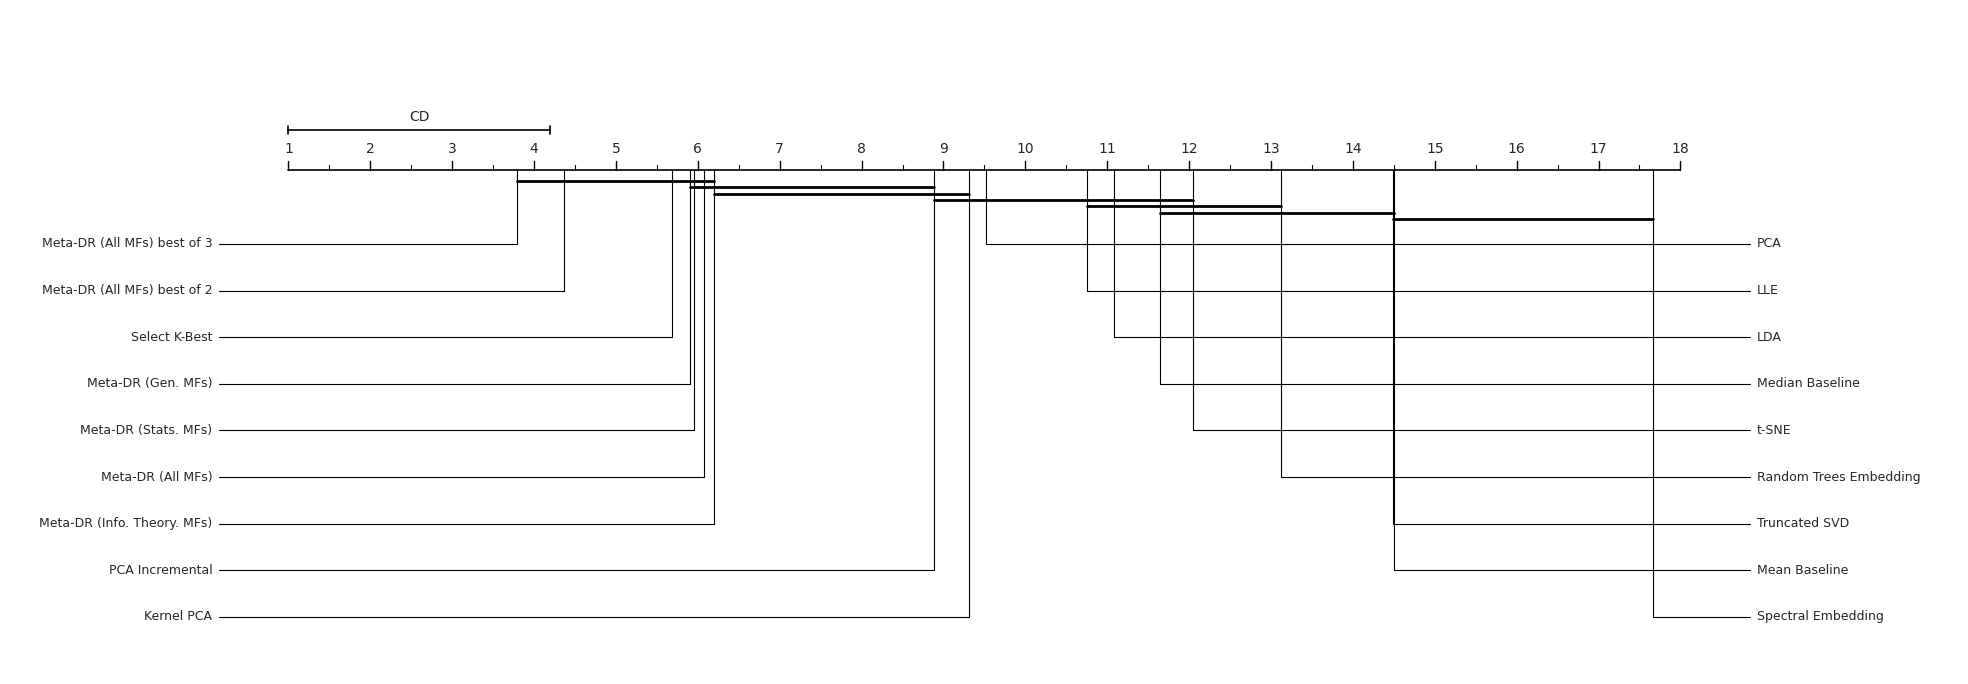

In [ ]:

# 1) Methods to compare
columns_cd = [
    'General Proposal', 'Statistical Proposal', 'Info-Theory Proposal', 'Unified Proposal',
    'Unified 2-shot', 'Unified 3-shot',
    'Mean Baseline', 'Median Baseline',
    'PCA', 'IncrementalPCA', 'RandomTreesEmbedding', 'SelectKBest',
    'SpectralEmbedding', 'TruncatedSVD', 'LDA', 'LLE', 'KPCA', 't-SNE'
]

# 2) Display labels
rename_labels_nshot = {
    'General Proposal': 'Meta-DR (Gen. MFs)',
    'Statistical Proposal': 'Meta-DR (Stats. MFs)',
    'Info-Theory Proposal': 'Meta-DR (Info. Theory. MFs)',
    'Unified Proposal': 'Meta-DR (All MFs)',
    'Unified 2-shot': 'Meta-DR (All MFs) best of 2',
    'Unified 3-shot': 'Meta-DR (All MFs) best of 3',
    'Mean Baseline': 'Mean Baseline',
    'Median Baseline': 'Median Baseline',
    'PCA': 'PCA',
    'IncrementalPCA': 'PCA Incremental',
    'RandomTreesEmbedding': 'Random Trees Embedding',
    'SelectKBest': 'Select K-Best',
    'SpectralEmbedding': 'Spectral Embedding',
    'TruncatedSVD': 'Truncated SVD',
    'LDA': 'LDA',
    'LLE': 'LLE',
    'KPCA': 'Kernel PCA',
    't-SNE': 't-SNE'
}

# 3) Load data
df_cd = final_results_table_nshot[columns_cd].copy()
df_cd = df_cd.dropna().reset_index(drop=True)

# 4) Compute ranks for each dataset
# Higher value = better performance -> rank 1
ranks = df_cd.apply(
    lambda row: rankdata(-row.values, method='average'),
    axis=1,
    result_type='expand'
)
ranks.columns = columns_cd
avg_ranks = ranks.mean(axis=0)

# 5) Friedman test
friedman_stat, friedman_p = friedmanchisquare(
    *[df_cd[col].values for col in columns_cd]
)

print(f"Friedman statistic: {friedman_stat:.6f}")
print(f"Friedman p-value: {friedman_p:.6e}")

# 6) Critical Difference (Nemenyi)
k = len(columns_cd)
N = len(df_cd)

try:
    from statsmodels.stats.libqsturng import qsturng
    q_alpha = qsturng(0.95, k, np.inf) / np.sqrt(2)
except Exception:
    q_alpha = 3.458  # fallback value
mf_not_first
CD = q_alpha * sqrt(k * (k + 1) / (6 * N))

print(f"Number of methods: {k}")
print(f"Number of datasets: {N}")
print(f"q_alpha: {q_alpha:.6f}")
print(f"Critical Difference (CD): {CD:.4f}")

# 7) Sort methods by average rank
order = np.argsort(avg_ranks.values)
avg_ranks_sorted = avg_ranks.values[order]
columns_sorted = [columns_cd[i] for i in order]
names_sorted = [rename_labels_nshot[col] for col in columns_sorted]

avg_ranks_table = pd.DataFrame({
    'Method': names_sorted,
    'Average Rank': avg_ranks_sorted
})

print("\nAverage ranks:")
print(avg_ranks_table.to_string(index=False))

# 8) Find non-significant groups
# Two methods belong to the same group if their rank
# difference is smaller than or equal to CD
groups = []
n_methods = len(avg_ranks_sorted)

for i in range(n_methods):
    j = i
    while j + 1 < n_methods and (avg_ranks_sorted[j + 1] - avg_ranks_sorted[i]) <= CD:
        j += 1
    if j > i:
        groups.append((i, j))

# Remove redundant groups
filtered_groups = []
for g in groups:
    is_contained = False
    for h in groups:
        if g != h and g[0] >= h[0] and g[1] <= h[1]:
            if (g[1] - g[0]) < (h[1] - h[0]):
                is_contained = True
                break
    if not is_contained:
        filtered_groups.append(g)

groups = []
seen = set()
for g in filtered_groups:
    if g not in seen:
        groups.append(g)
        seen.add(g)

print("\nNon-significant groups (sorted positions):")
for group in groups:
    print(group)

# 9) CD diagram function
def plot_cd_diagram(
    avg_ranks,
    names,
    cd,
    groups,
    title="Critical Difference Diagram",
    filename="cd_diagram.pdf"
):
    n_methods = len(avg_ranks)

    # Split methods into left and right sides
    half = int(np.ceil(n_methods / 2))
    left_idx = list(range(half))
    right_idx = list(range(half, n_methods))

    # Vertical positions
    left_y_positions = np.linspace(-0.15, -len(left_idx) * 0.38, len(left_idx))
    right_y_positions = np.linspace(-0.15, -len(right_idx) * 0.38, len(right_idx))

    # Figure limits
    left_margin = 3.4
    right_margin = 3.4
    top = 1.0
    bottom = min(
        left_y_positions.min() if len(left_y_positions) else 0,
        right_y_positions.min() if len(right_y_positions) else 0
    ) - 0.50

    min_rank = 1
    max_rank = n_methods

    fig, ax = plt.subplots(figsize=(20, 7))
    ax.set_axis_off()
    ax.set_xlim(min_rank - left_margin, max_rank + right_margin)
    ax.set_ylim(bottom, top + 0.9)

    # Main rank axis
    axis_y = 0.50
    ax.plot([min_rank, max_rank], [axis_y, axis_y], color="black", lw=1.2)

    for rank in range(min_rank, max_rank + 1):
        ax.plot([rank, rank], [axis_y, axis_y + 0.08], color="black", lw=1.0)
        ax.text(rank, axis_y + 0.12, str(rank), ha="center", va="bottom", fontsize=10)

    for rank in np.arange(min_rank + 0.5, max_rank, 1.0):
        ax.plot([rank, rank], [axis_y, axis_y + 0.04], color="black", lw=0.8)

    # CD bar
    cd_y = axis_y + 0.35
    cd_x0 = min_rank
    cd_x1 = min_rank + cd

    ax.plot([cd_x0, cd_x1], [cd_y, cd_y], color="black", lw=1.2)
    ax.plot([cd_x0, cd_x0], [cd_y - 0.035, cd_y + 0.035], color="black", lw=1.2)
    ax.plot([cd_x1, cd_x1], [cd_y - 0.035, cd_y + 0.035], color="black", lw=1.2)
    ax.text((cd_x0 + cd_x1) / 2, cd_y + 0.05, "CD", ha="center", va="bottom", fontsize=10)

    # Left-side methods
    left_text_x = min_rank - 0.85
    for plot_idx, method_idx in enumerate(left_idx):
        x = avg_ranks[method_idx]
        y = left_y_positions[plot_idx]

        ax.plot([x, x], [axis_y, y], color="black", lw=0.8)
        ax.plot([left_text_x, x], [y, y], color="black", lw=0.8)
        ax.text(left_text_x - 0.08, y, names[method_idx], ha="right", va="center", fontsize=9)

    # Right-side methods
    right_text_x = max_rank + 0.85
    for plot_idx, method_idx in enumerate(right_idx):
        x = avg_ranks[method_idx]
        y = right_y_positions[plot_idx]

        ax.plot([x, x], [axis_y, y], color="black", lw=0.8)
        ax.plot([x, right_text_x], [y, y], color="black", lw=0.8)
        ax.text(right_text_x + 0.08, y, names[method_idx], ha="left", va="center", fontsize=9)

    # Non-significant groups
    group_y_start = axis_y - 0.10
    step = 0.055

    for group_idx, (i, j) in enumerate(groups):
        y = group_y_start - group_idx * step
        x0 = avg_ranks[i]
        x1 = avg_ranks[j]
        ax.plot([x0, x1], [y, y], color="black", lw=2.0)

    # Title
    if title:
        ax.text(
            (min_rank + max_rank) / 2,
            top + 0.45,
            title,
            ha="center",
            va="center",
            fontsize=80
        )

    plt.tight_layout()
    plt.savefig(filename, format="pdf", bbox_inches="tight", dpi=300)
    plt.show()

# 10) Plot the CD diagram
plot_cd_diagram(
    avg_ranks=avg_ranks_sorted,
    names=names_sorted,
    cd=CD,
    groups=groups,
    title="",
    filename="cd_diagram_nshot.pdf"
)